# Libraries using for Tabular Preprocessing

In [17]:
import shutil
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## I.Downloading the dataset:

In this step, we download the selected tabular dataset directly from **Kaggle** using the `kagglehub` library. This approach ensures that the dataset is always retrieved in its **latest available version**, improving reproducibility and consistency across different environments.

After downloading, all dataset files are copied into a predefined project directory structure (`data/tabular/`). This organization helps maintain a clean and standardized layout for data preprocessing experiments.

In [3]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

destination = "../data/tabular"
os.makedirs(destination, exist_ok=True)

moved = 0

for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            src = os.path.join(root, file)
            dst = os.path.join(destination, file)

            shutil.copy2(src, dst)
            moved += 1
            print(f"Copied: {file}")

print(f"Moved {moved} files to {destination}")


100%|██████████| 66.0M/66.0M [02:39<00:00, 434kB/s]

Extracting files...


Path to dataset files: C:\Users\AnhTris\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
Copied: creditcard.csv
Moved 1 files to ../data/tabular



After downloading and organizing the dataset, the following file is available in the `data/tabular/` directory:

```
data/tabular/
└── creditcard.csv
```

This file contains the **Credit Card Fraud Detection dataset**, which is used for exploratory data analysis, preprocessing, and building classification models to detect fraudulent credit card transactions.

* Represents **real-world credit card transactions** made by European cardholders over **two consecutive days** in September 2013.
* Highly **imbalanced dataset**, with **492 fraudulent transactions** out of **284,807 total transactions** (≈ **0.172% fraud rate**).
* Designed specifically for **fraud detection and anomaly detection tasks**, where standard accuracy metrics are insufficient.

The dataset includes the following types of features:

* **Anonymized transaction features** (`V1`–`V28`):

  * Numerical features obtained via **Principal Component Analysis (PCA)** to protect sensitive customer information.
  * Capture underlying transaction patterns without revealing original attributes.
* **Non-PCA features**:

  * `Time`: Seconds elapsed between each transaction and the first transaction in the dataset.
  * `Amount`: Transaction amount, useful for **cost-sensitive learning**.
* **Target variable**:

  * `Class`: Binary label indicating transaction type

    * `1` → Fraudulent transaction
    * `0` → Legitimate transaction

**Dataset source:** Kaggle – [*Credit Card Fraud Detection*](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


## II. Loading the datasets

In [4]:
data = pd.read_csv(os.path.join(destination, "creditcard.csv"))

### Analyzing some basic information of the dataset

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### III. Handling Missing Values: 

- Finding all the columns with missing columns

In [14]:
# Print out the table, including columns' name, data type and missing counts

missing_columns = data.columns[data.isnull().any()]
missing_info = []
for col in missing_columns:
    missing_count = data[col].isnull().sum()
    missing_pct = (missing_count / len(data)) * 100
    dtype = data[col].dtype
    
    missing_info.append({
        'Column': col,
        'Data Type': dtype,
        'Missing Count': missing_count,
        'Missing %': f"{missing_pct:.2f}%"
    })

# Create DataFrame for better visualization
missing_df = pd.DataFrame(missing_info)
print(f"\nTotal columns with missing values: {len(missing_columns)}")
print(f"Total columns in dataset: {len(data.columns)}\n")
print(missing_df.to_string(index=False))

print("\n" + "="*60)


Total columns with missing values: 0
Total columns in dataset: 31

Empty DataFrame
Columns: []
Index: []



&rarr; Our dataset don't have missing value so we don't have to handling this part.

### IV. Data Normalization:

- Detecting outliers in the numerical variables

In [8]:
# Get numerical columns from the final imputed dataset
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nNumerical columns to normalize: {len(numerical_cols)}")
print(f"Columns: {numerical_cols}")

# Check for outliers before normalization
print("\n" + "-"*60)
print("OUTLIER DETECTION")
print("-"*60)

outlier_summary = {}
for col in numerical_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(data)) * 100
    
    outlier_summary[col] = outlier_count
    print(f"{col}: {outlier_count} outliers ({outlier_pct:.2f}%)")


Numerical columns to normalize: 31
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

------------------------------------------------------------
OUTLIER DETECTION
------------------------------------------------------------
Time: 0 outliers (0.00%)
V1: 7062 outliers (2.48%)
V2: 13526 outliers (4.75%)
V3: 3363 outliers (1.18%)
V4: 11148 outliers (3.91%)
V5: 12295 outliers (4.32%)
V6: 22965 outliers (8.06%)
V7: 8948 outliers (3.14%)
V8: 24134 outliers (8.47%)
V9: 8283 outliers (2.91%)
V10: 9496 outliers (3.33%)
V11: 780 outliers (0.27%)
V12: 15348 outliers (5.39%)
V13: 3368 outliers (1.18%)
V14: 14149 outliers (4.97%)
V15: 2894 outliers (1.02%)
V16: 8184 outliers (2.87%)
V17: 7420 outliers (2.61%)
V18: 7533 outliers (2.64%)
V12: 15348 outliers (5.39%)
V13: 3368 outliers (1.18%)
V14: 14149 outliers (4.97%)
V15: 289

- Apply Min-Max scaling, standardization (Z-score normalization), and robust scaling for data with outliers.

In [ ]:
# Create copies for different normalization techniques
data_minmax = data.copy()
data_standard = data.copy()
data_robust = data.copy()

# Initialize scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


data_minmax[numerical_cols] = minmax_scaler.fit_transform(data[numerical_cols])
data_standard[numerical_cols] = standard_scaler.fit_transform(data[numerical_cols])
data_robust[numerical_cols] = robust_scaler.fit_transform(data[numerical_cols])

In [11]:
# Statistical comparison
print("\n" + "="*60)
print("Statistical comparison")
print("="*60)

comparison_df = pd.DataFrame({
    'Column': numerical_cols * 4,
    'Method': ['Original'] * len(numerical_cols) + 
              ['Min-Max'] * len(numerical_cols) + 
              ['Standard'] * len(numerical_cols) + 
              ['Robust'] * len(numerical_cols),
    'Mean': [data[col].mean() for col in numerical_cols] +
            [data_minmax[col].mean() for col in numerical_cols] +
            [data_standard[col].mean() for col in numerical_cols] +
            [data_robust[col].mean() for col in numerical_cols],
    'Std': [data[col].std() for col in numerical_cols] +
           [data_minmax[col].std() for col in numerical_cols] +
           [data_standard[col].std() for col in numerical_cols] +
           [data_robust[col].std() for col in numerical_cols],
    'Min': [data[col].min() for col in numerical_cols] +
           [data_minmax[col].min() for col in numerical_cols] +
           [data_standard[col].min() for col in numerical_cols] +
           [data_robust[col].min() for col in numerical_cols],
    'Max': [data[col].max() for col in numerical_cols] +
           [data_minmax[col].max() for col in numerical_cols] +
           [data_standard[col].max() for col in numerical_cols] +
           [data_robust[col].max() for col in numerical_cols]
})

print(comparison_df.to_string(index=False))


Statistical comparison
Column   Method          Mean          Std         Min           Max
  Time Original  9.481386e+04 47488.145955    0.000000 172792.000000
    V1 Original  1.168375e-15     1.958696  -56.407510      2.454930
    V2 Original  3.416908e-16     1.651309  -72.715728     22.057729
    V3 Original -1.379537e-15     1.516255  -48.325589      9.382558
    V4 Original  2.074095e-15     1.415869   -5.683171     16.875344
    V5 Original  9.604066e-16     1.380247 -113.743307     34.801666
    V6 Original  1.487313e-15     1.332271  -26.160506     73.301626
    V7 Original -5.556467e-16     1.237094  -43.557242    120.589494
    V8 Original  1.213481e-16     1.194353  -73.216718     20.007208
    V9 Original -2.406331e-15     1.098632  -13.434066     15.594995
   V10 Original  2.239053e-15     1.088850  -24.588262     23.745136
   V11 Original  1.673327e-15     1.020713   -4.797473     12.018913
   V12 Original -1.247012e-15     0.999201  -18.683715      7.848392
   V13 Ori

- Comparing distributions before and after normalization.

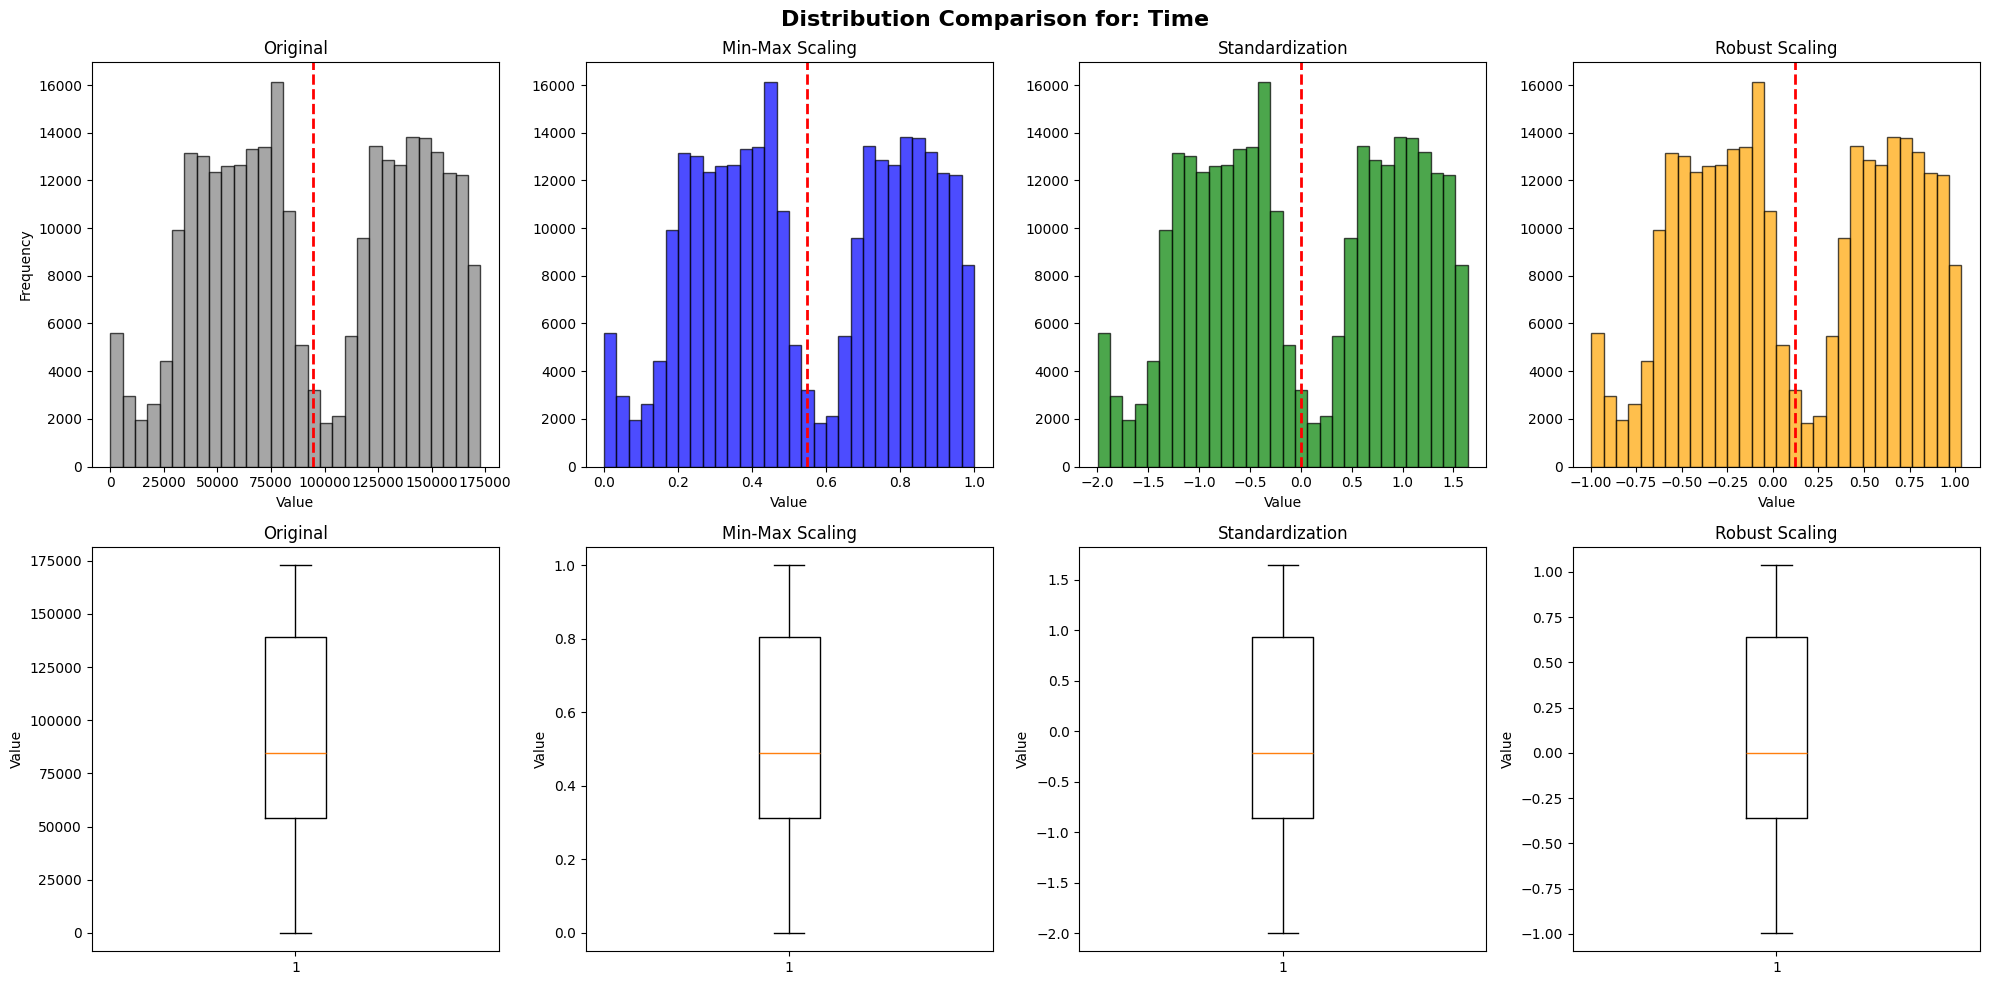

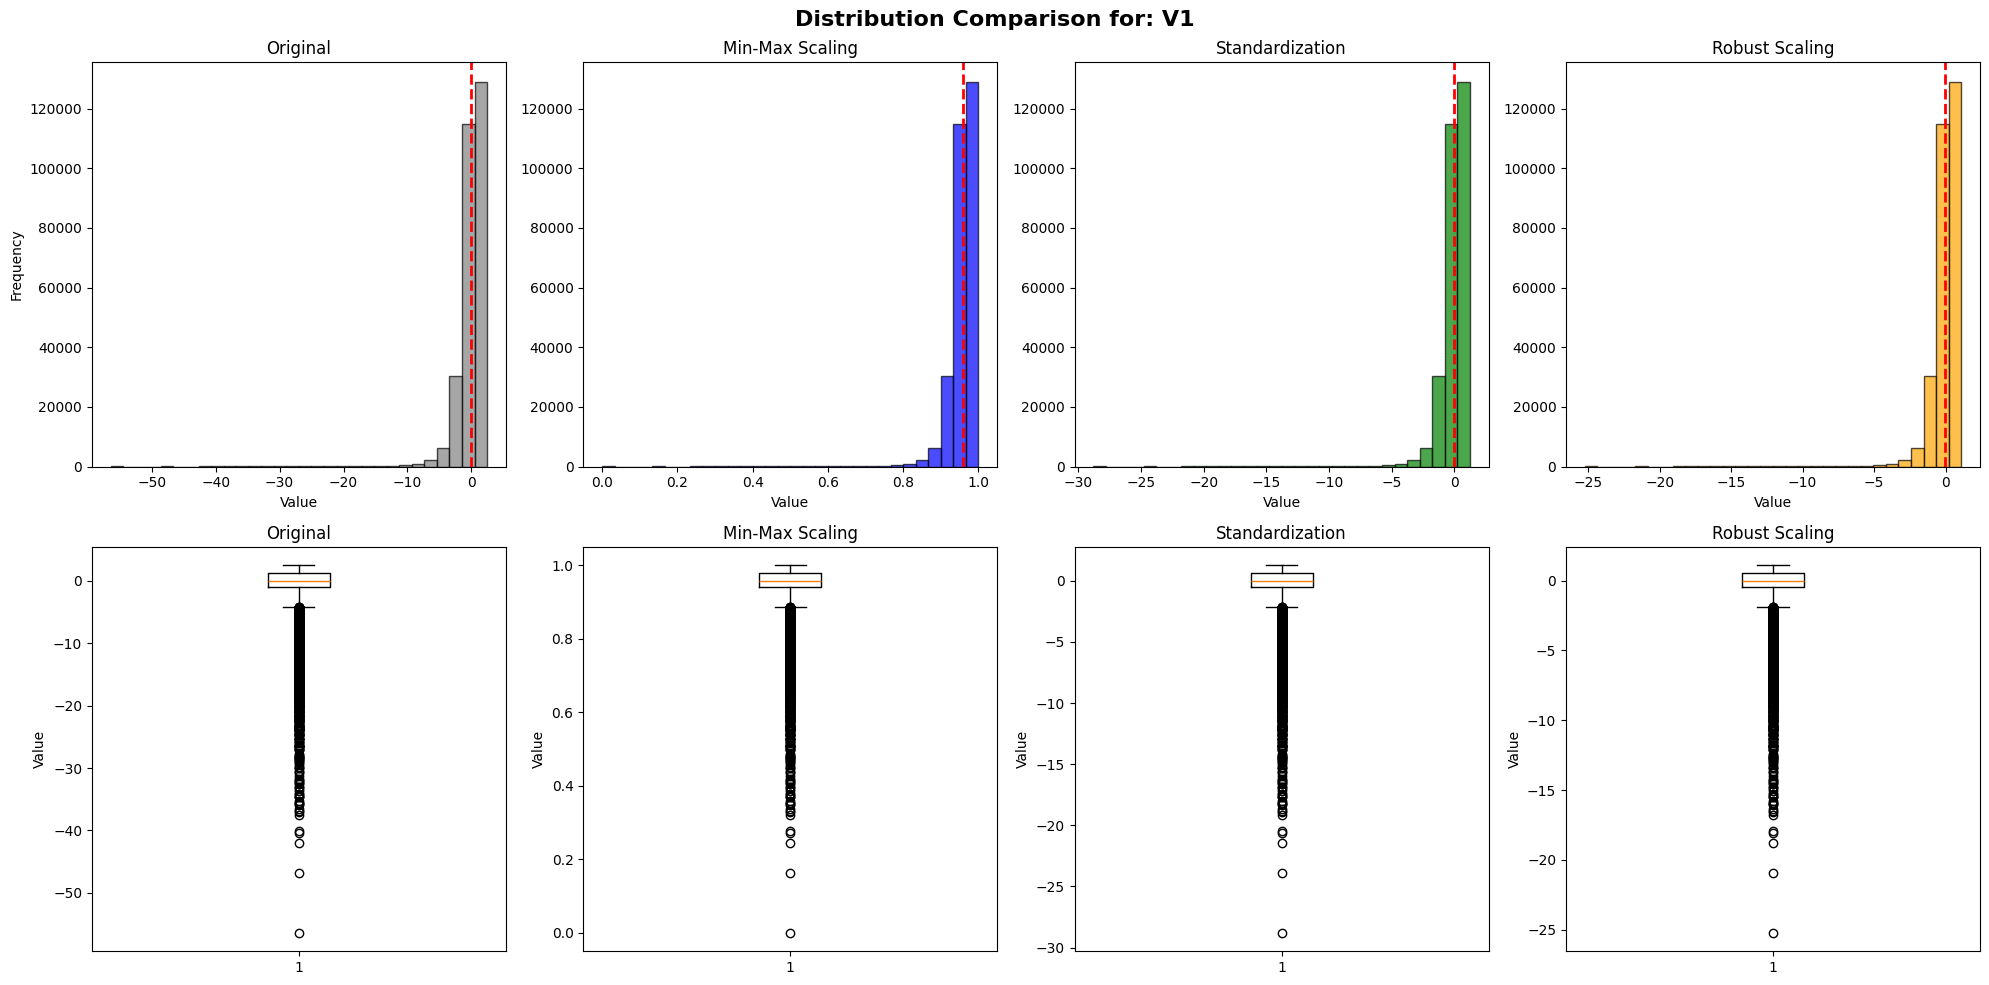

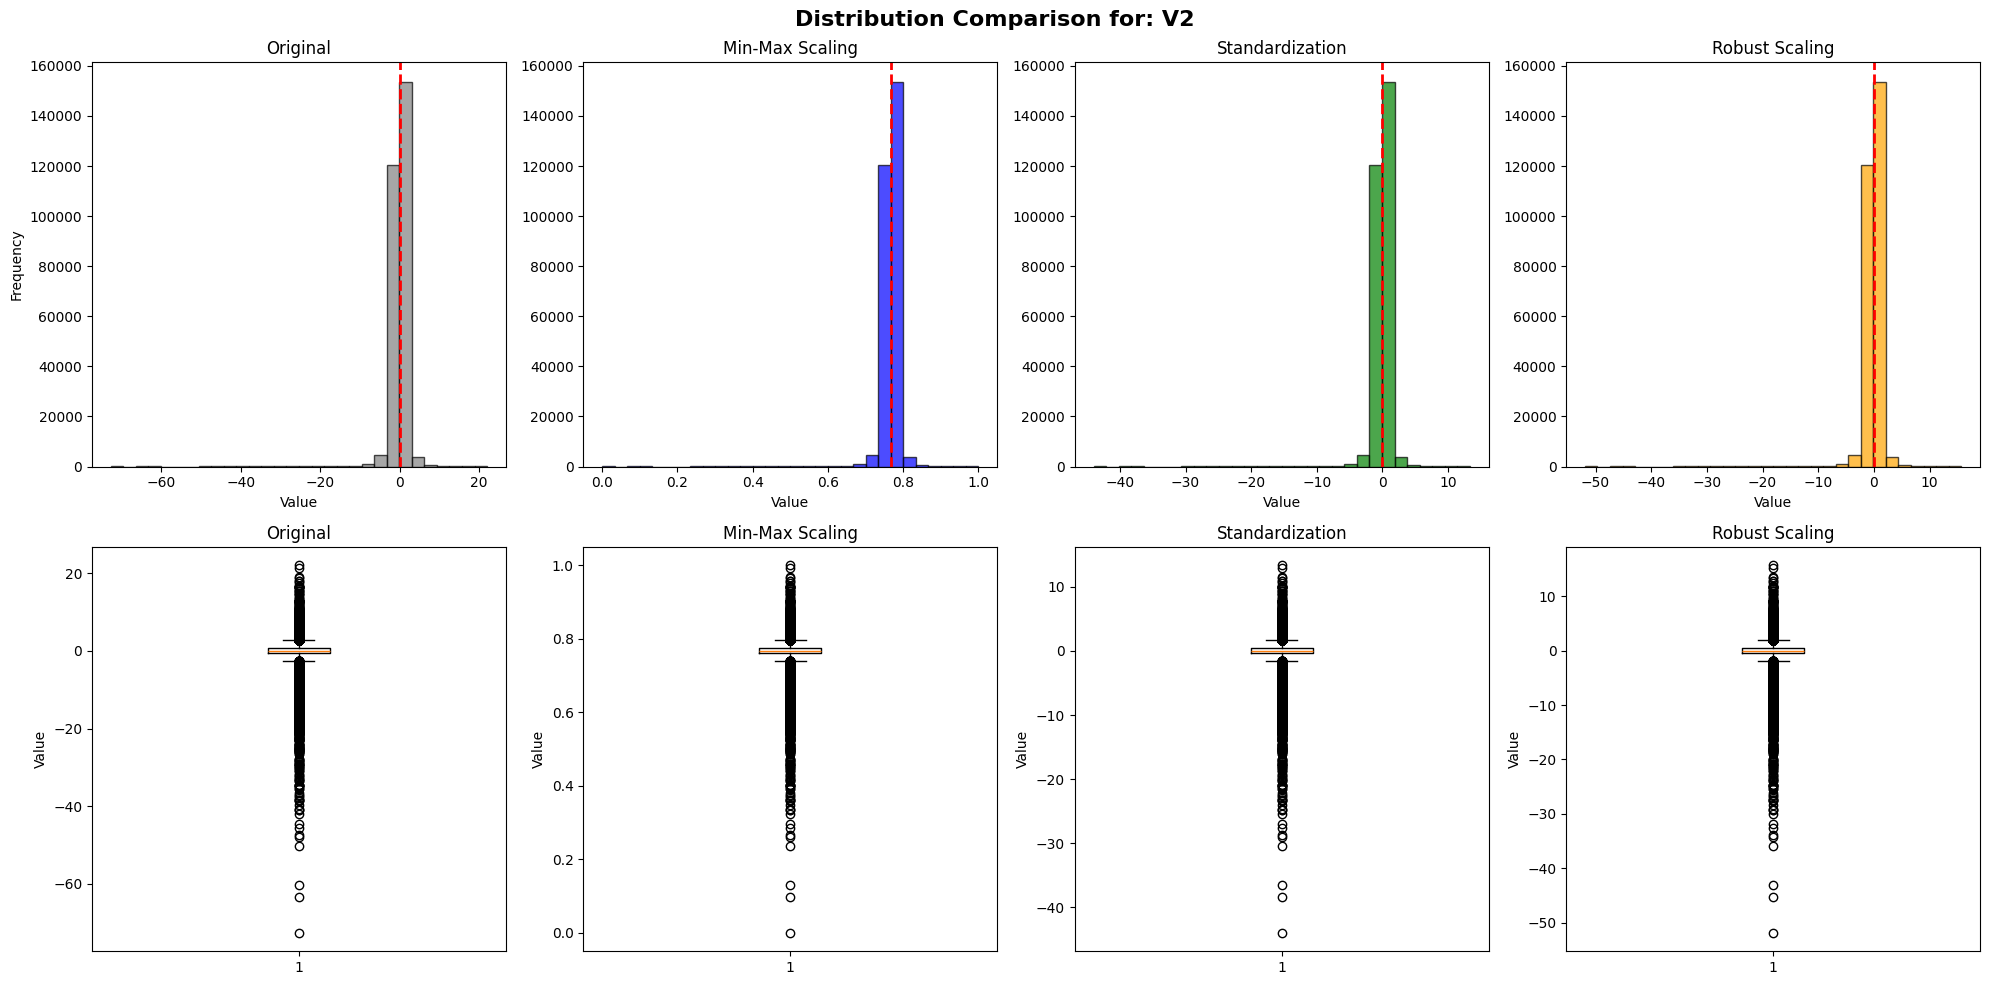

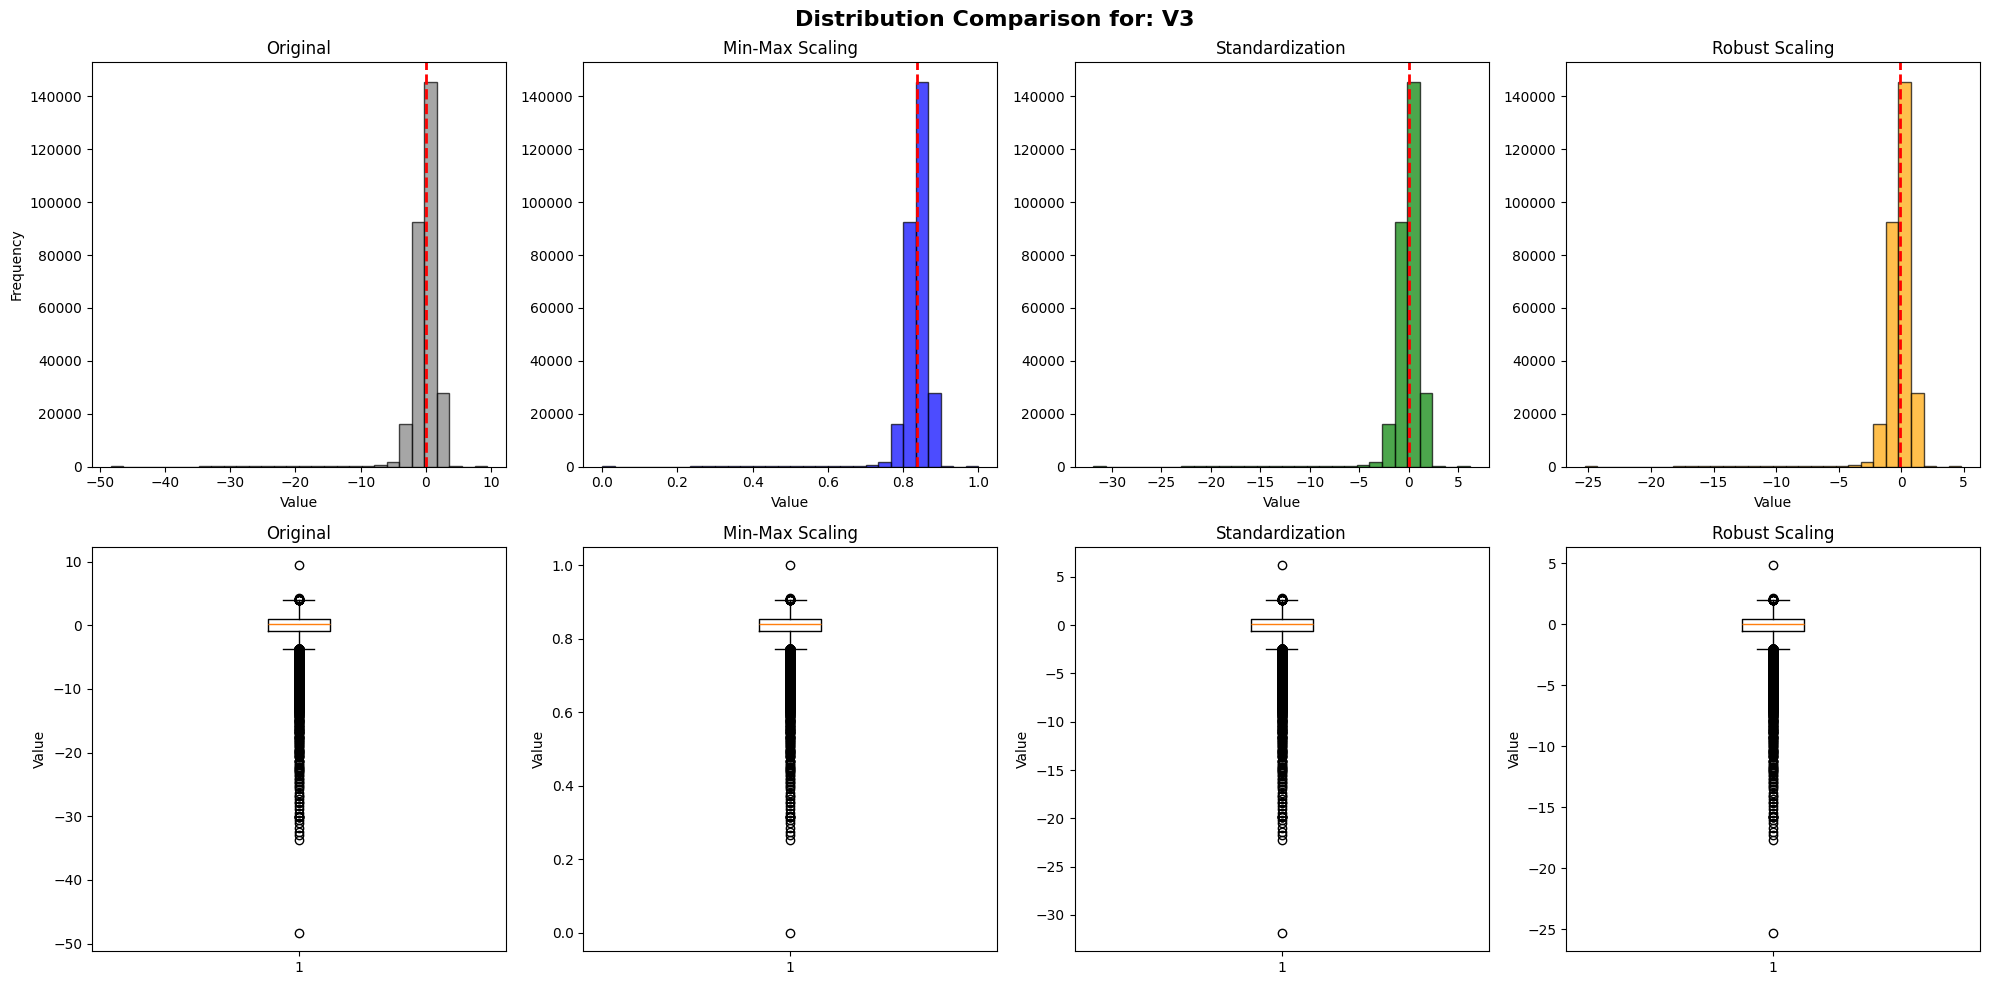

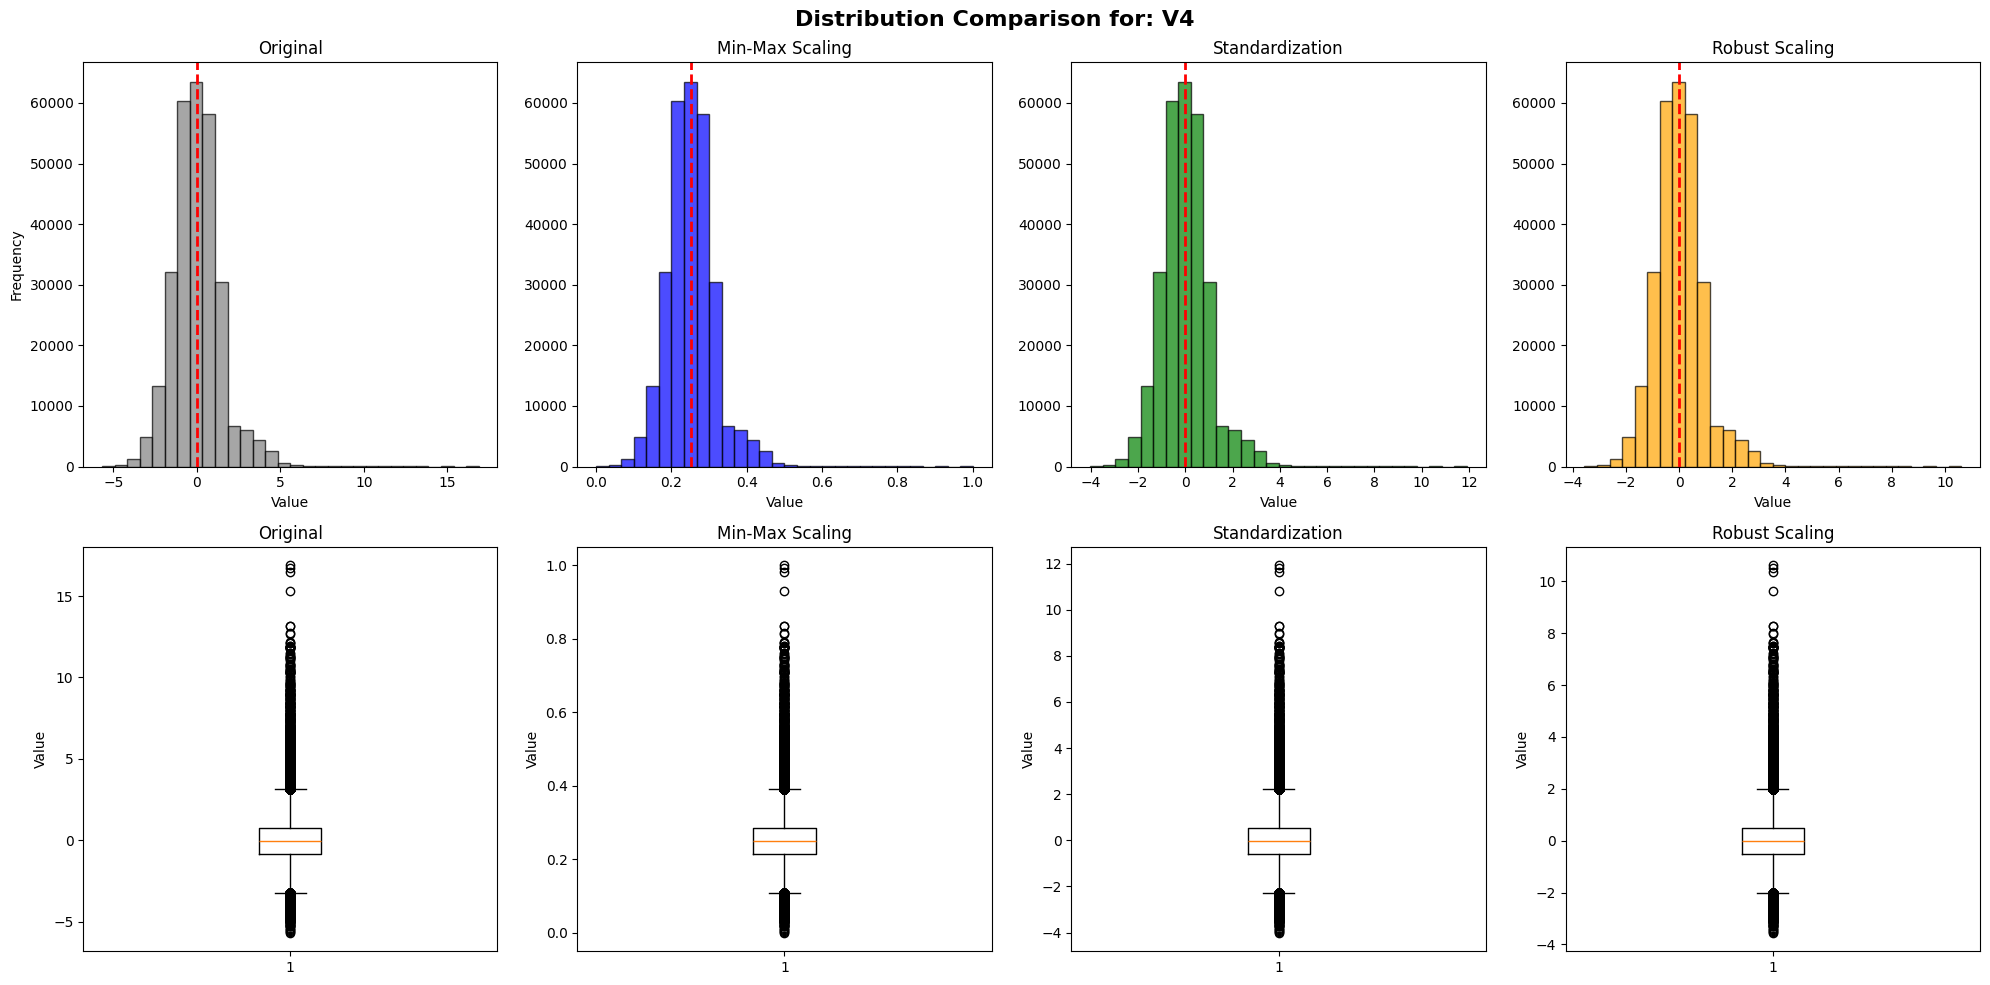

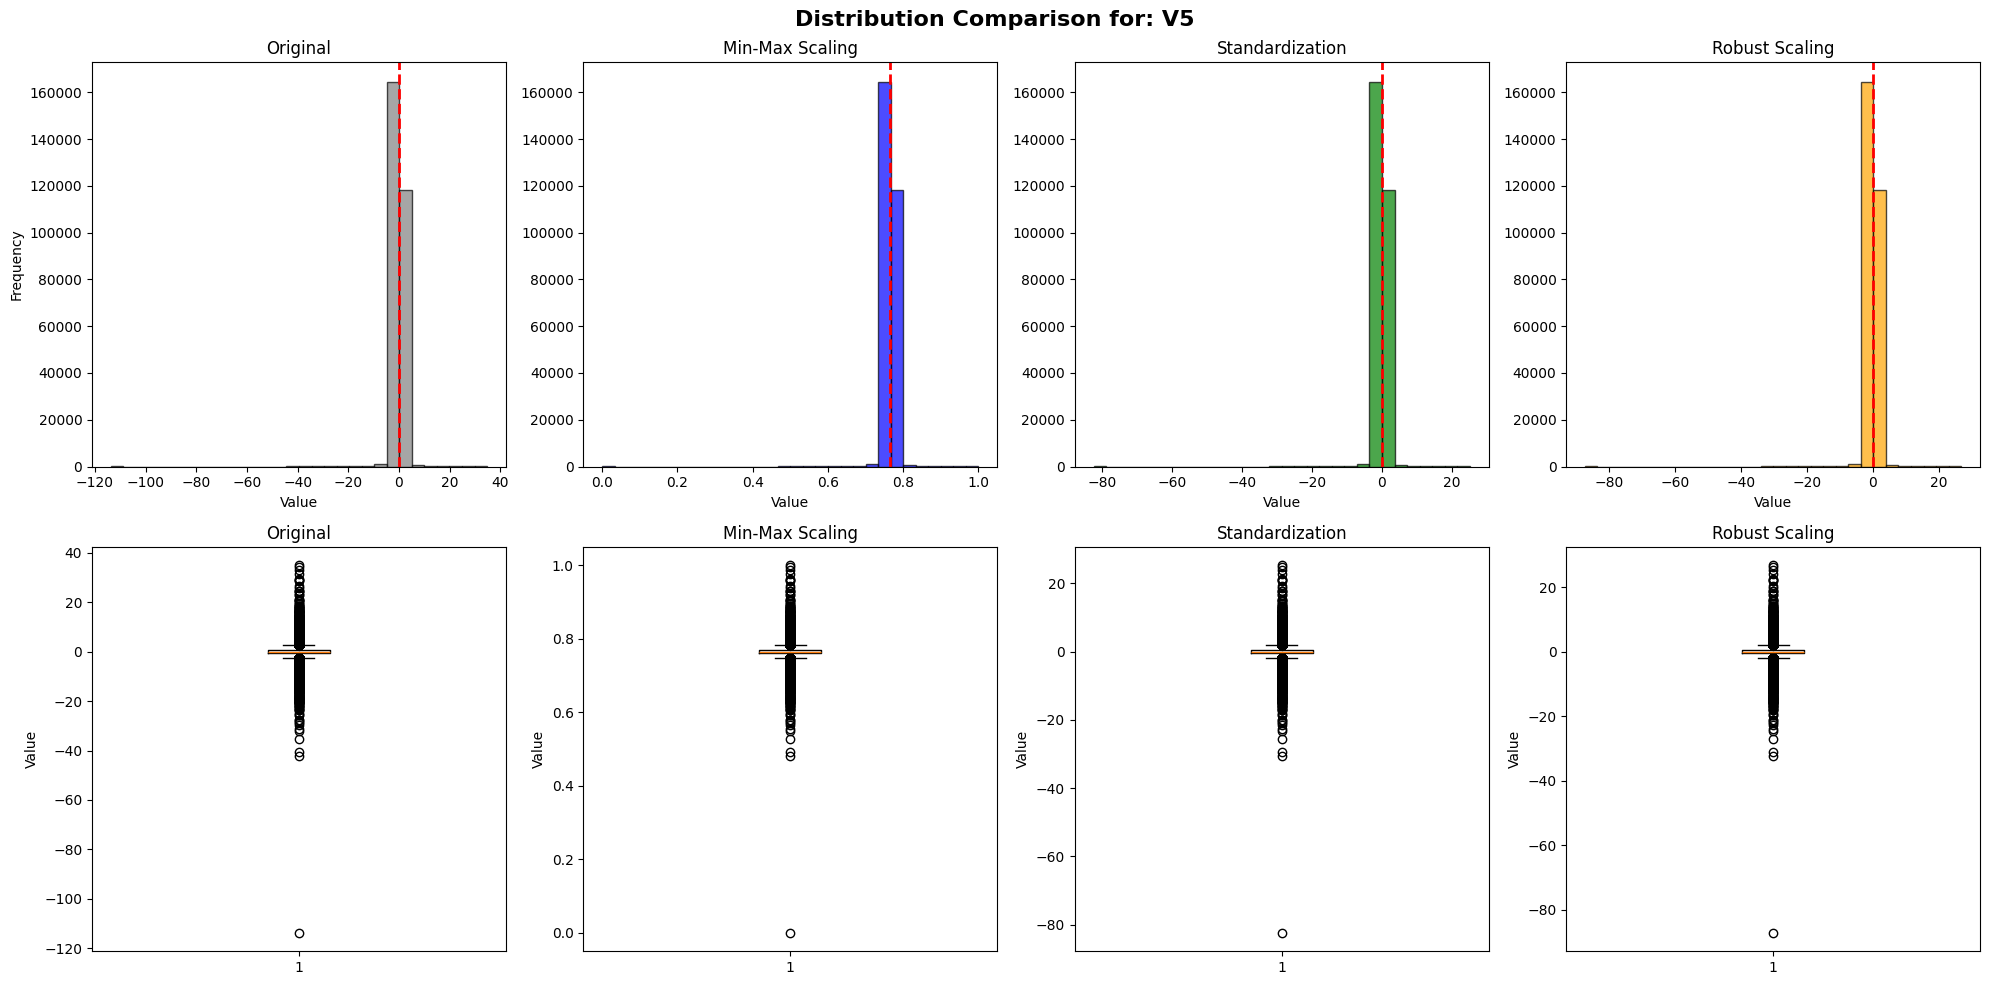

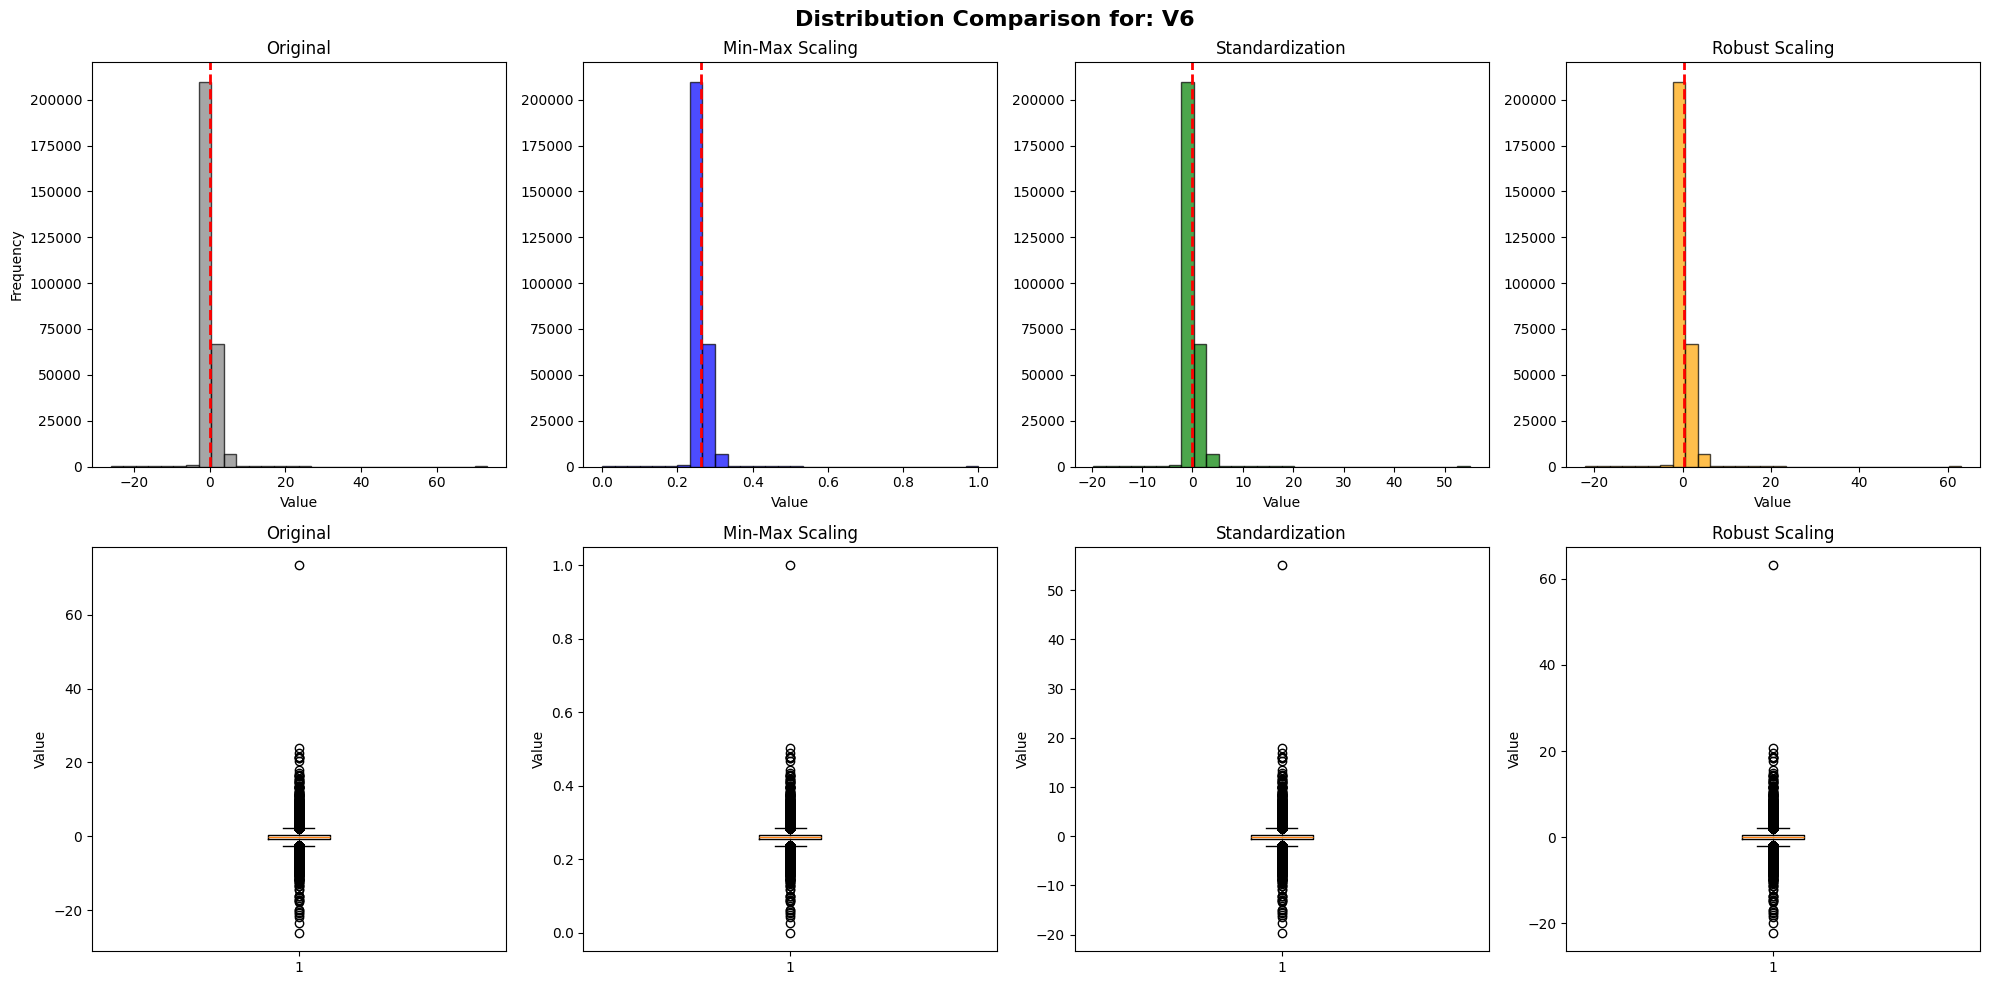

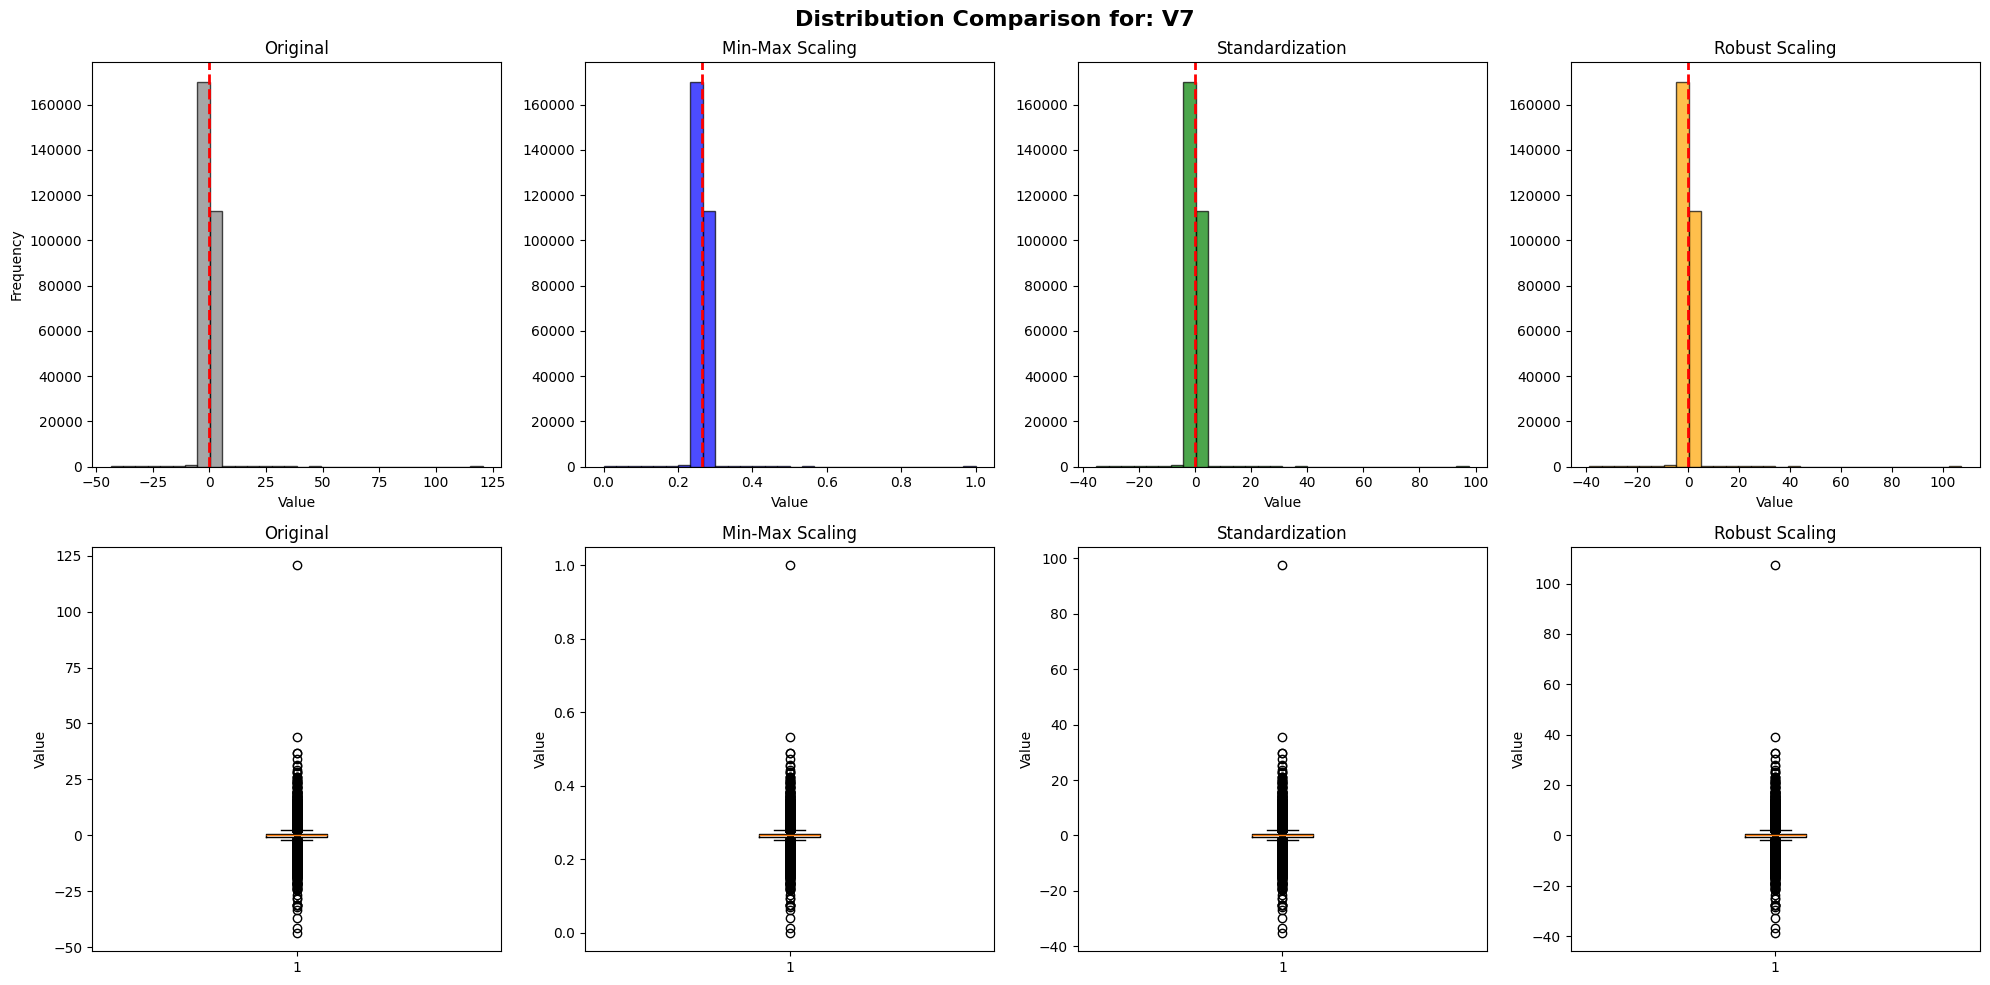

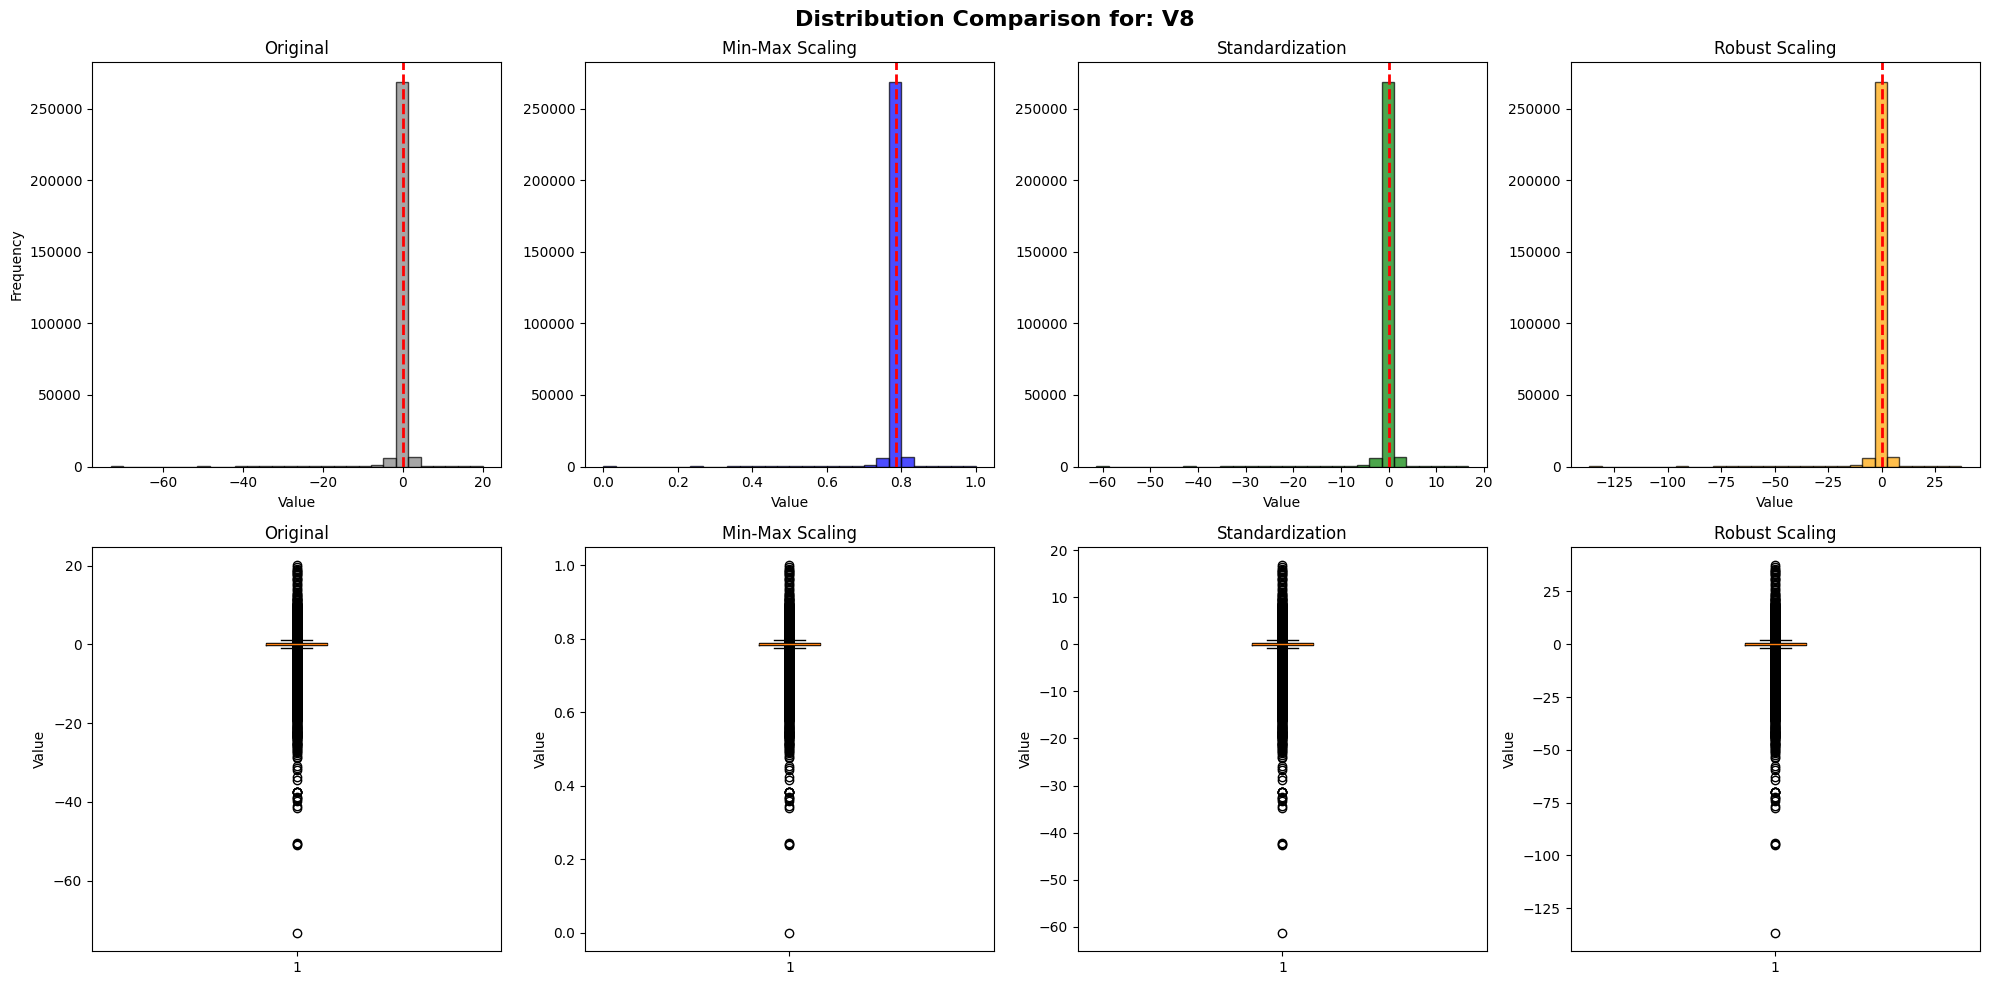

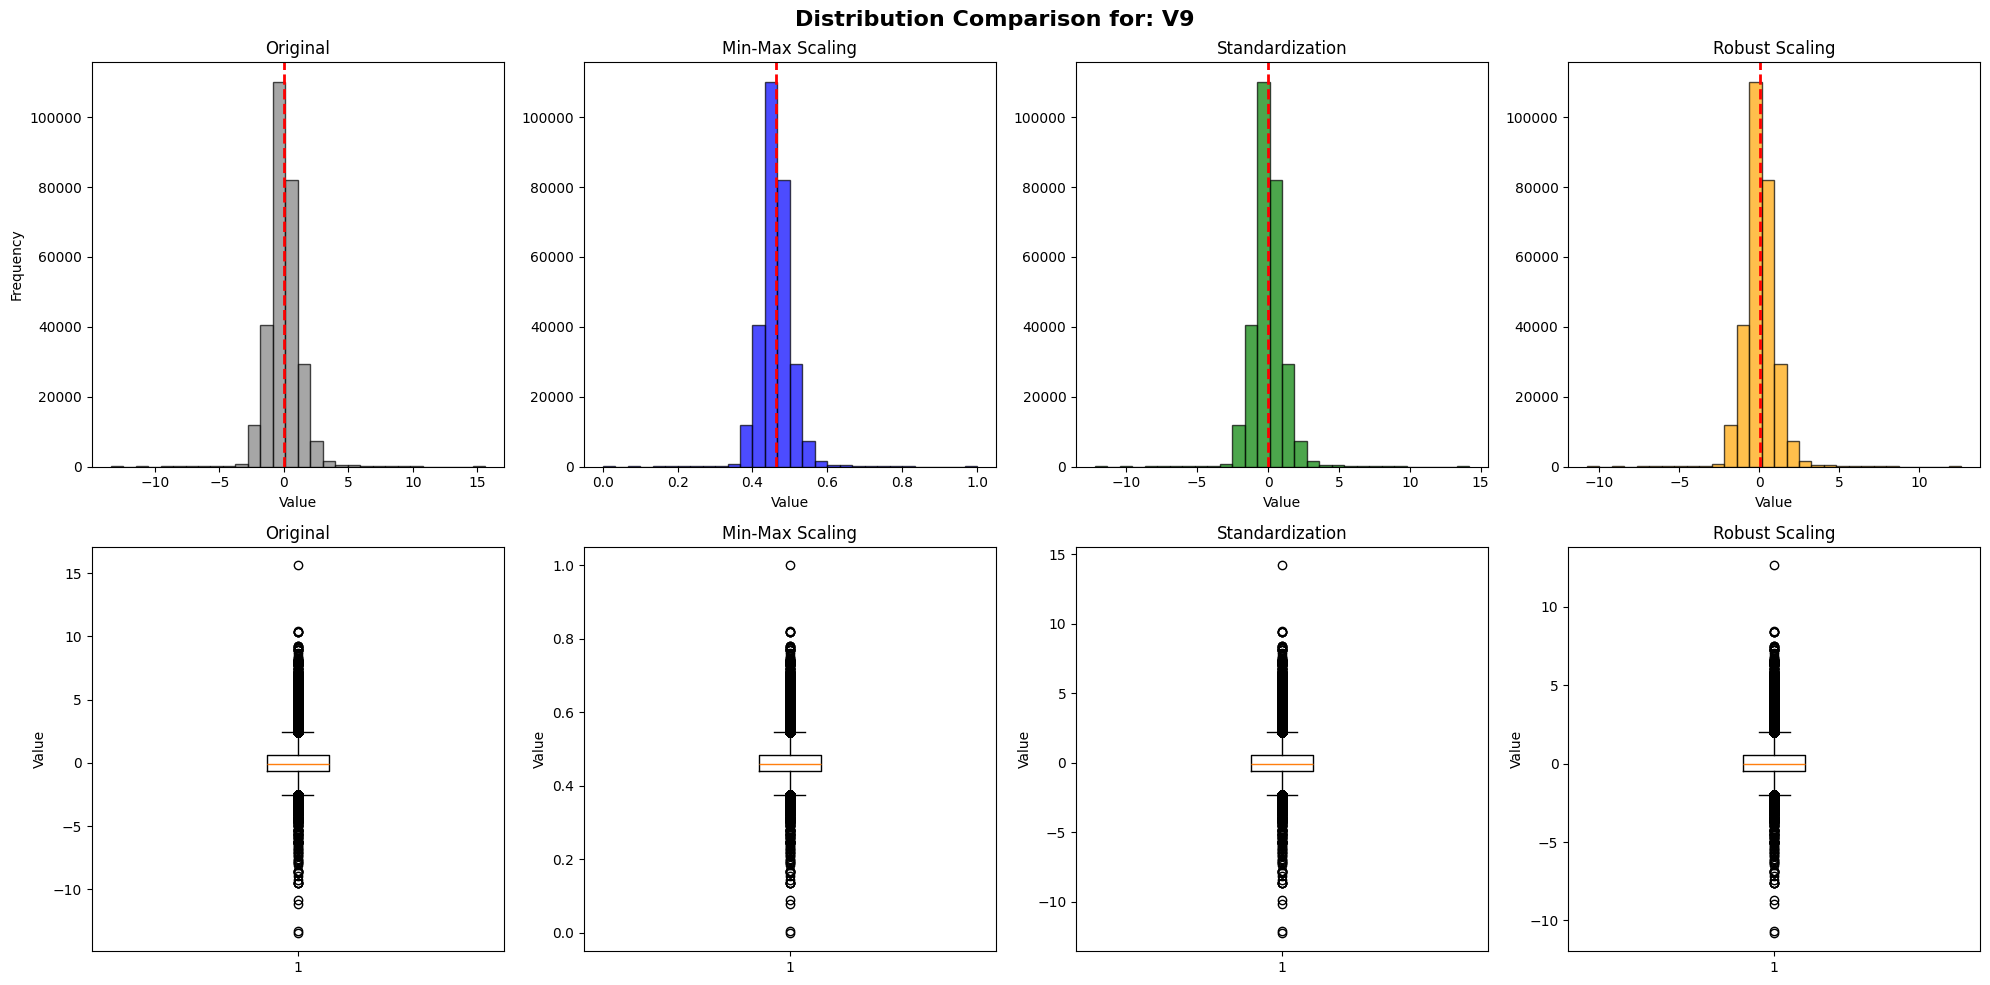

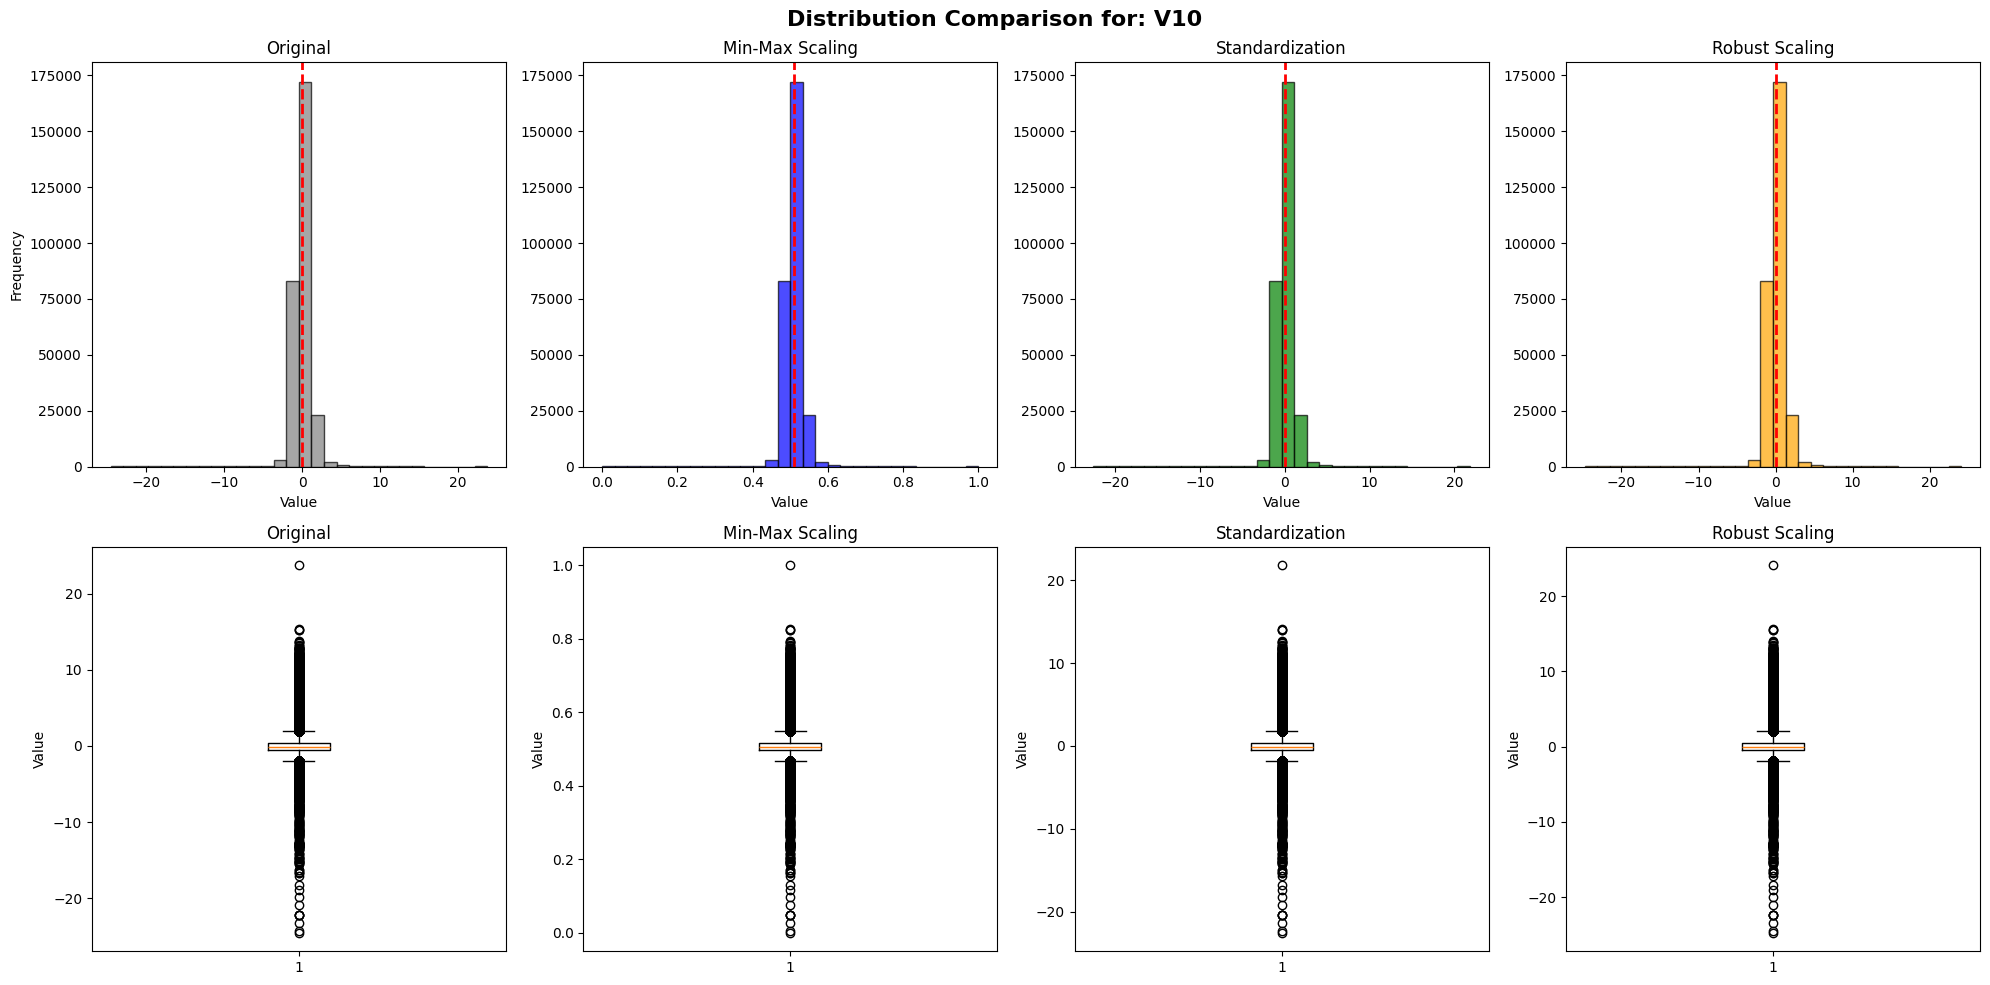

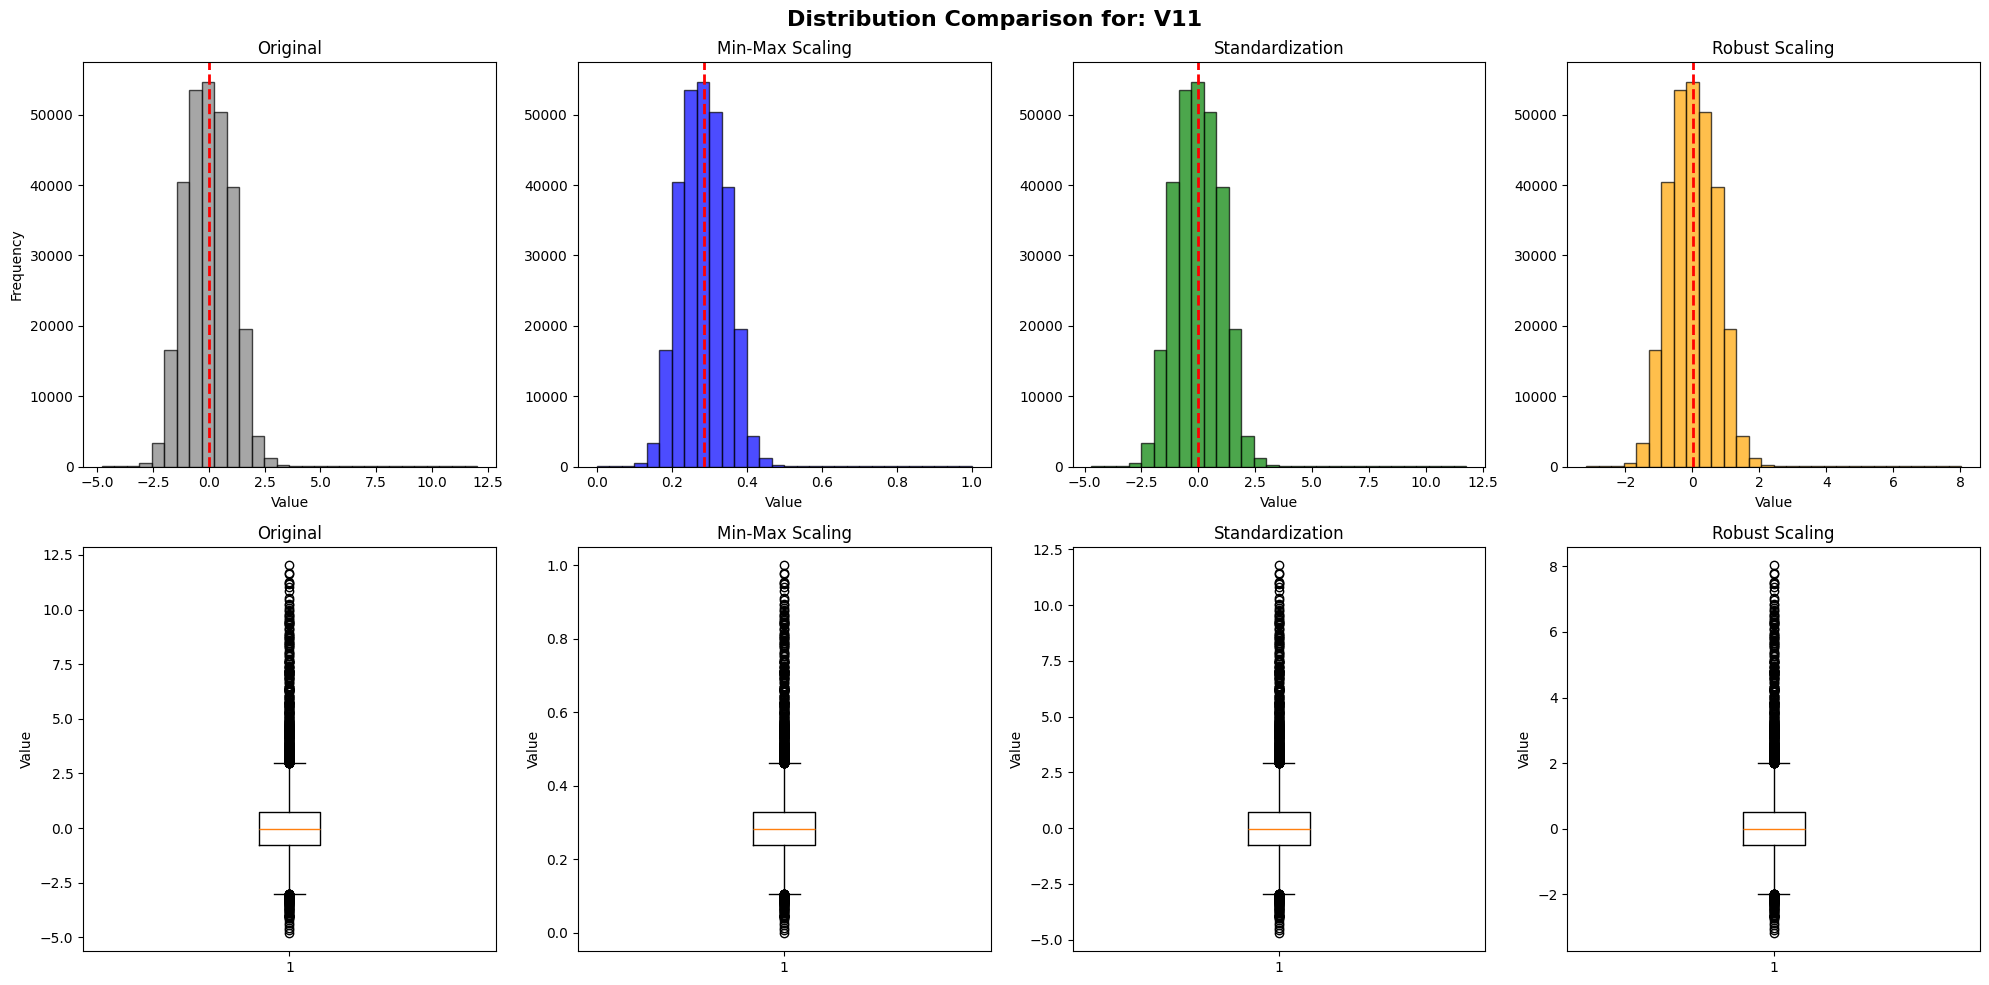

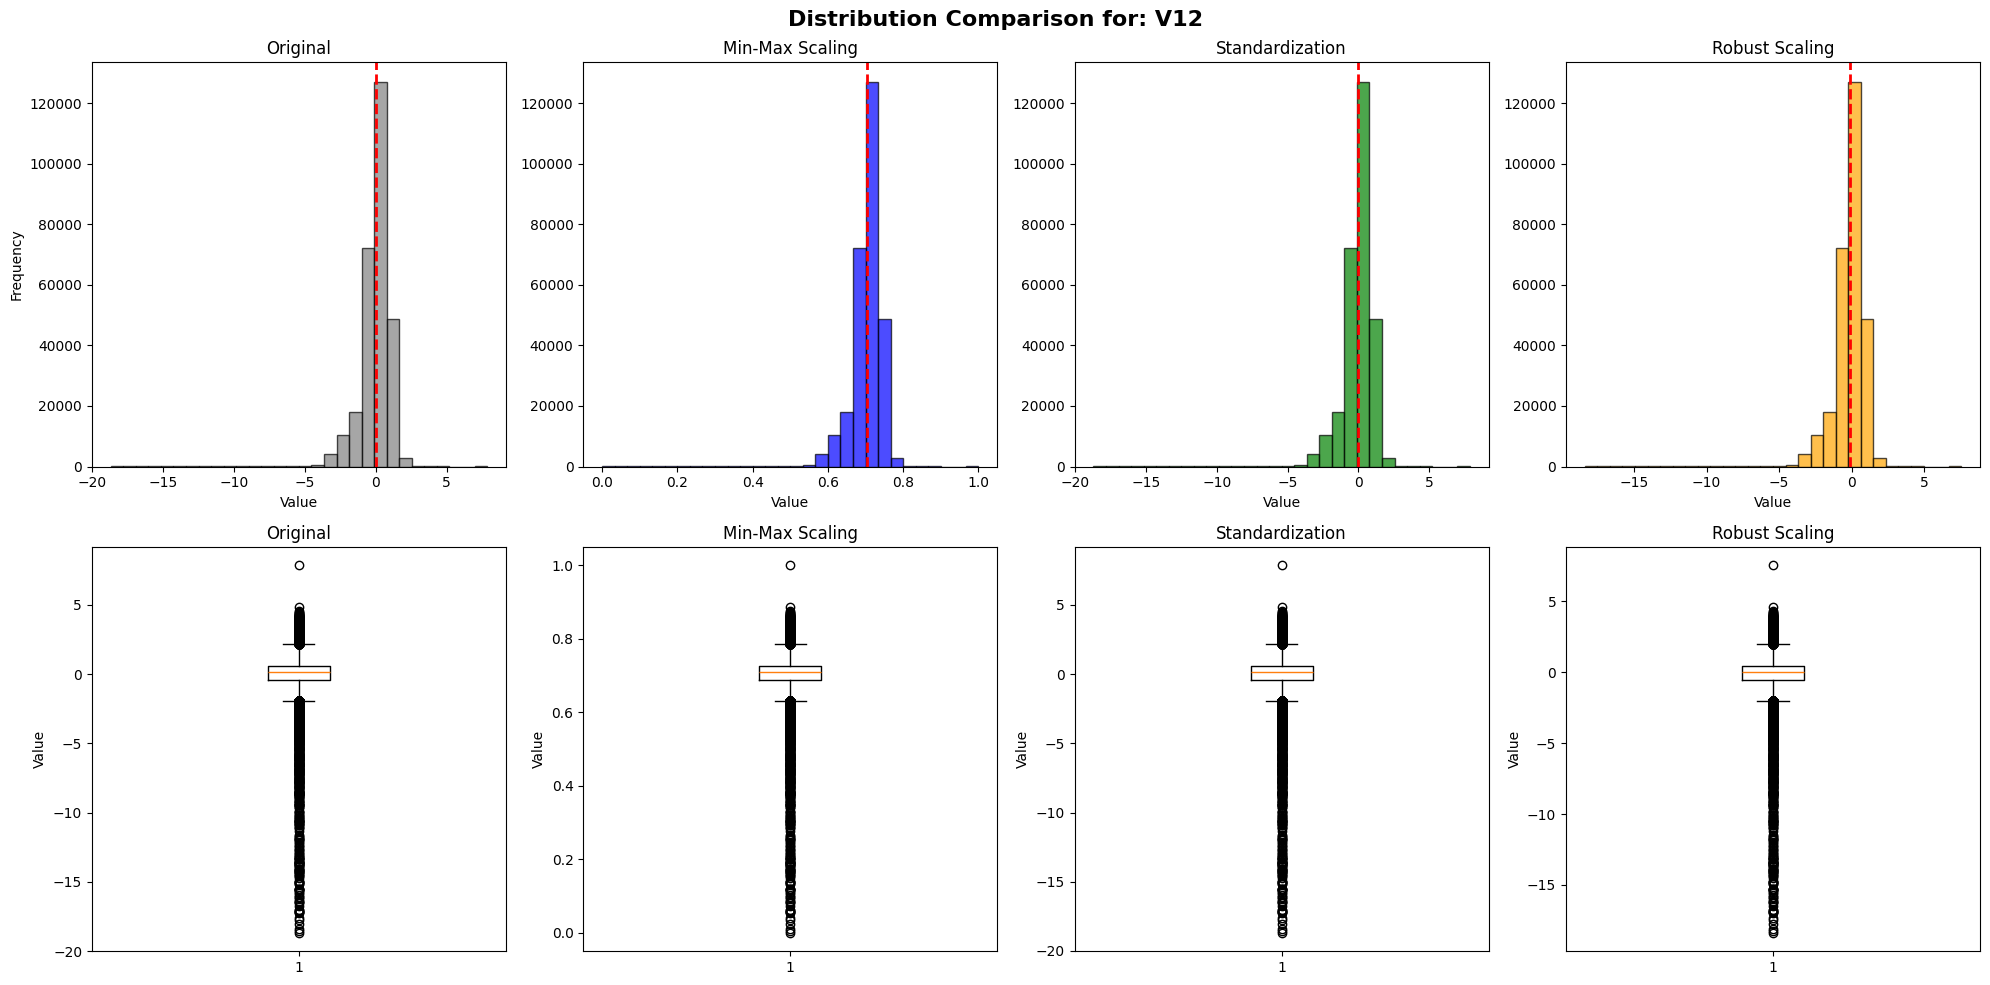

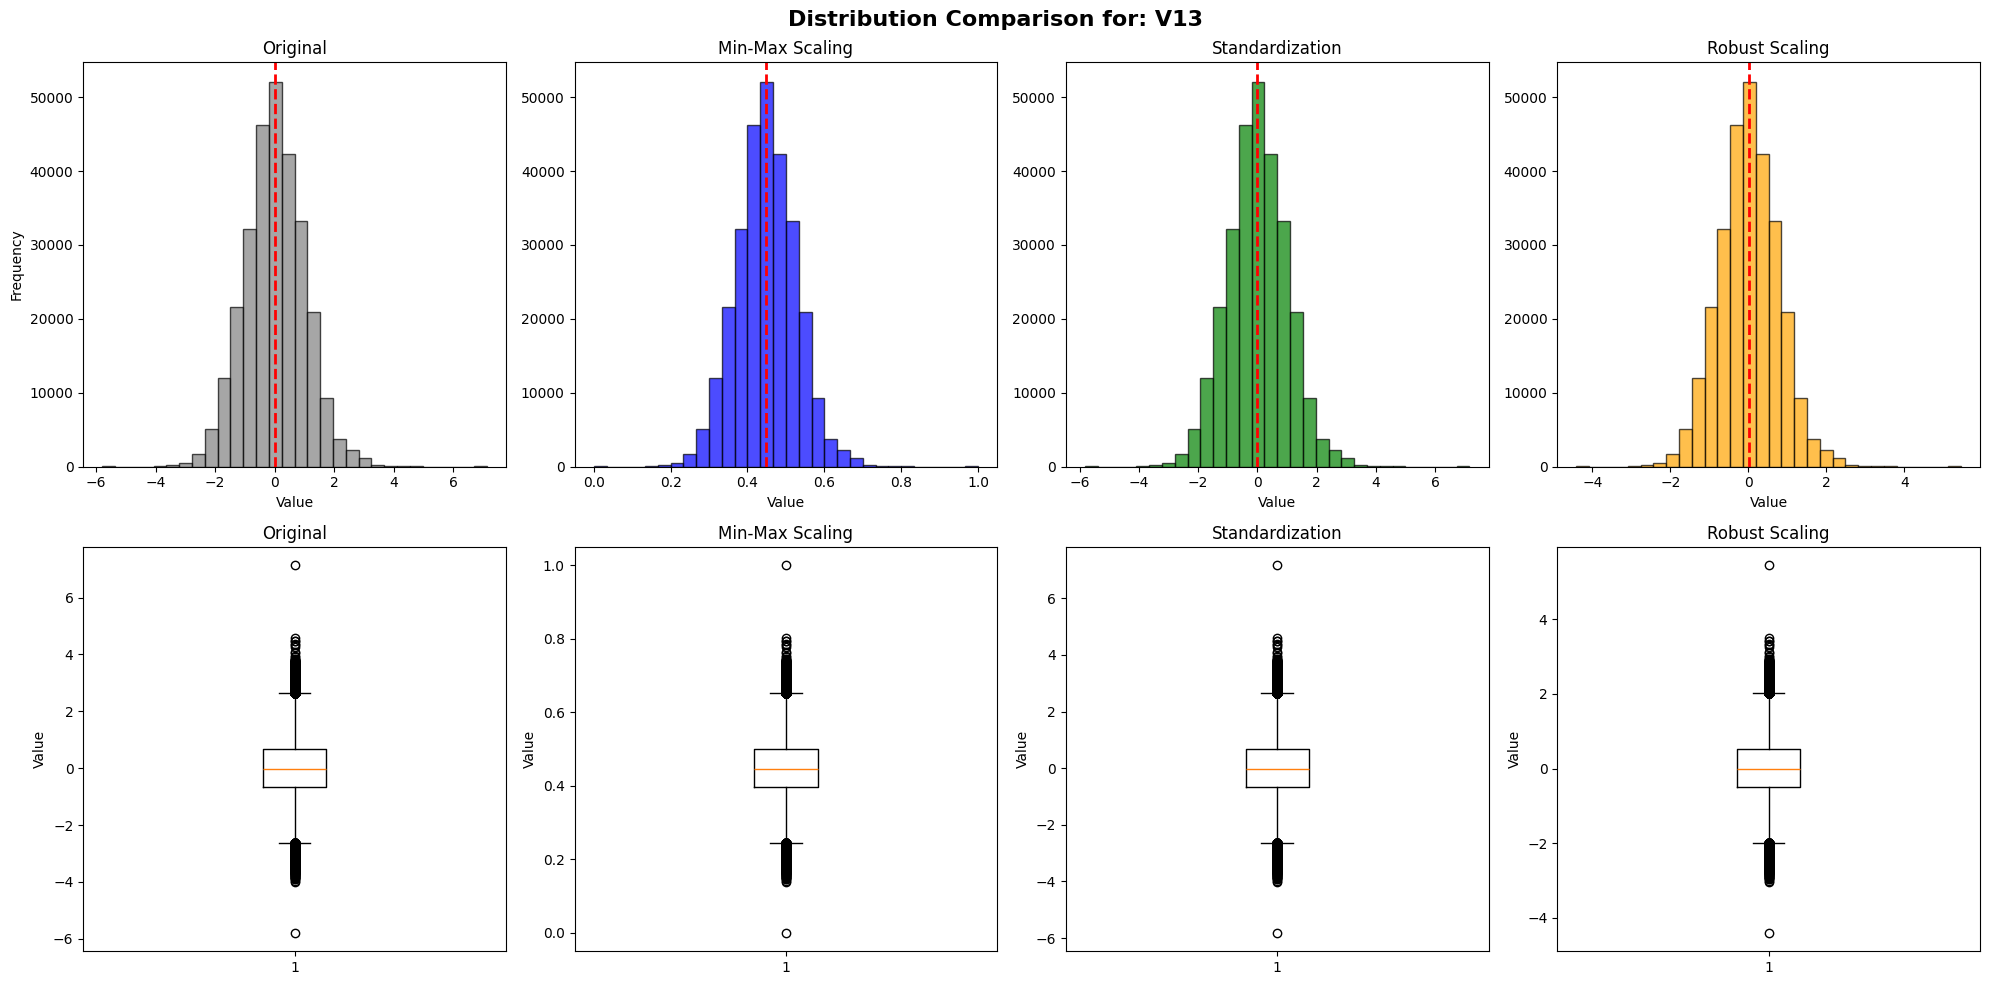

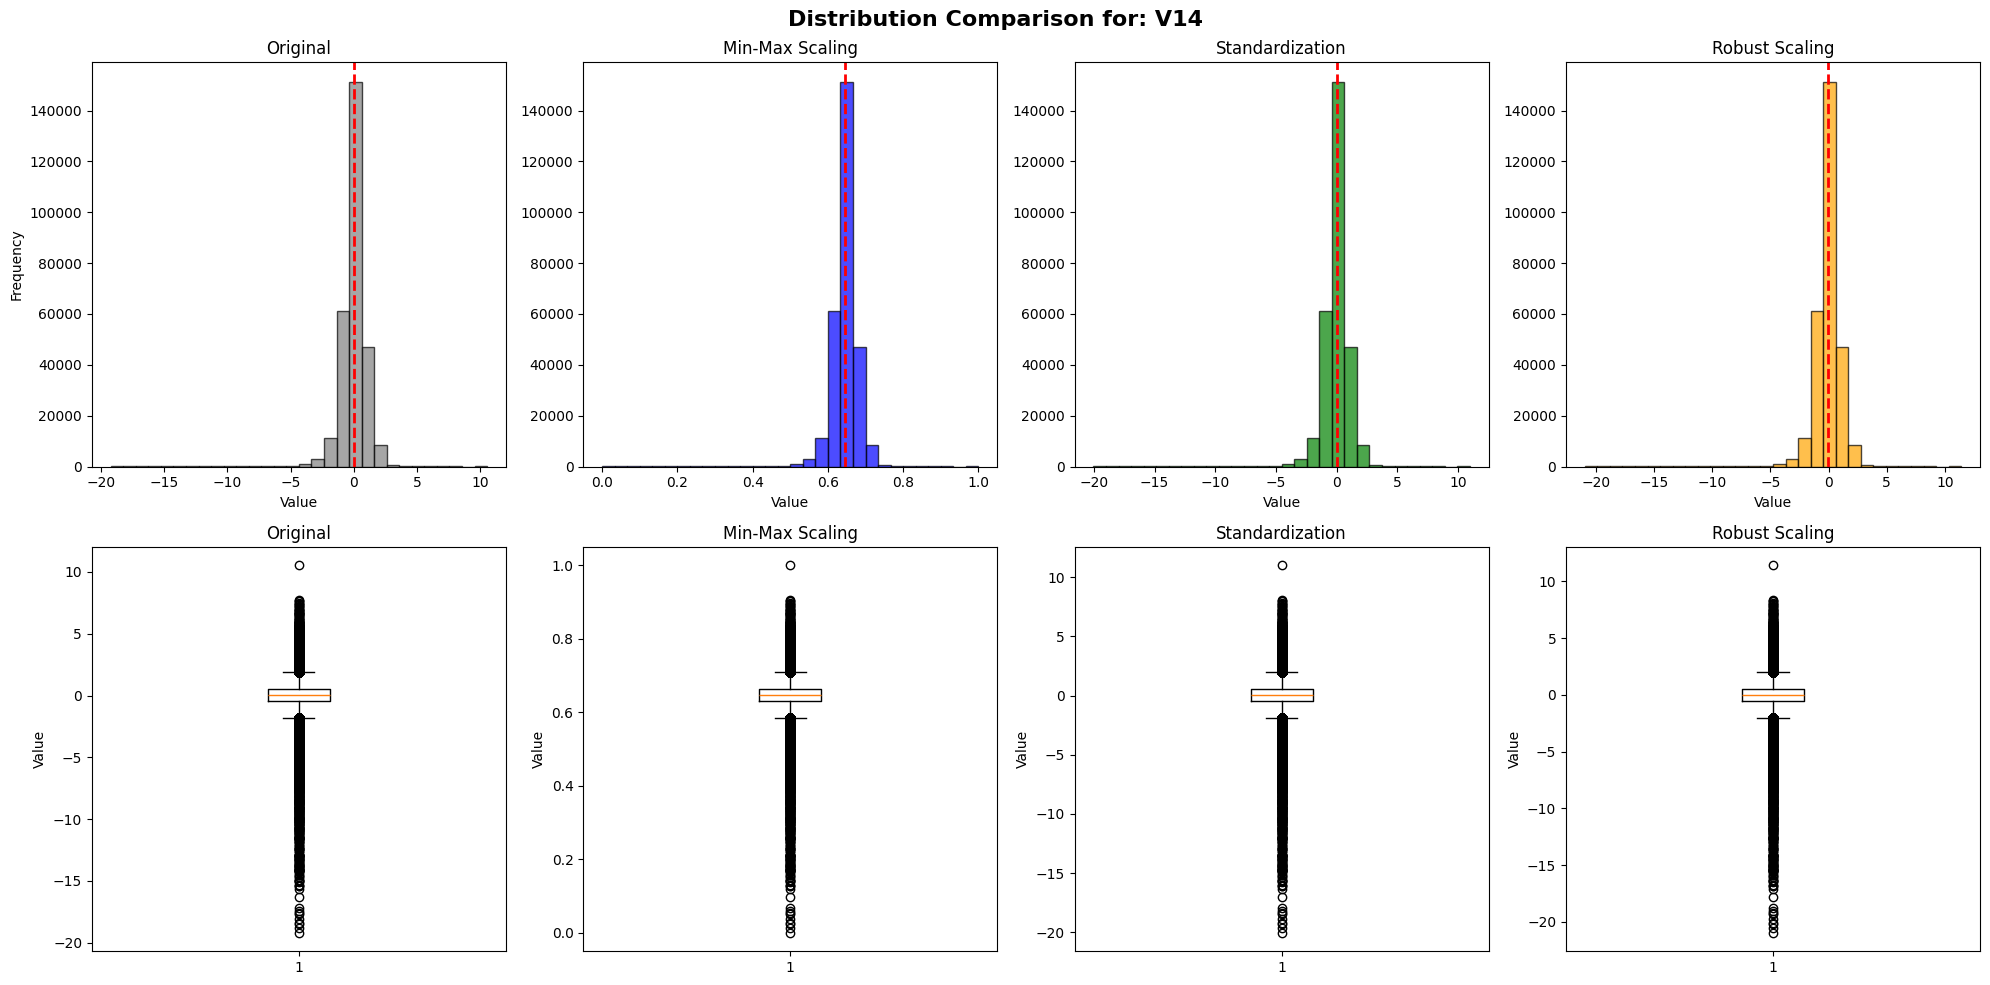

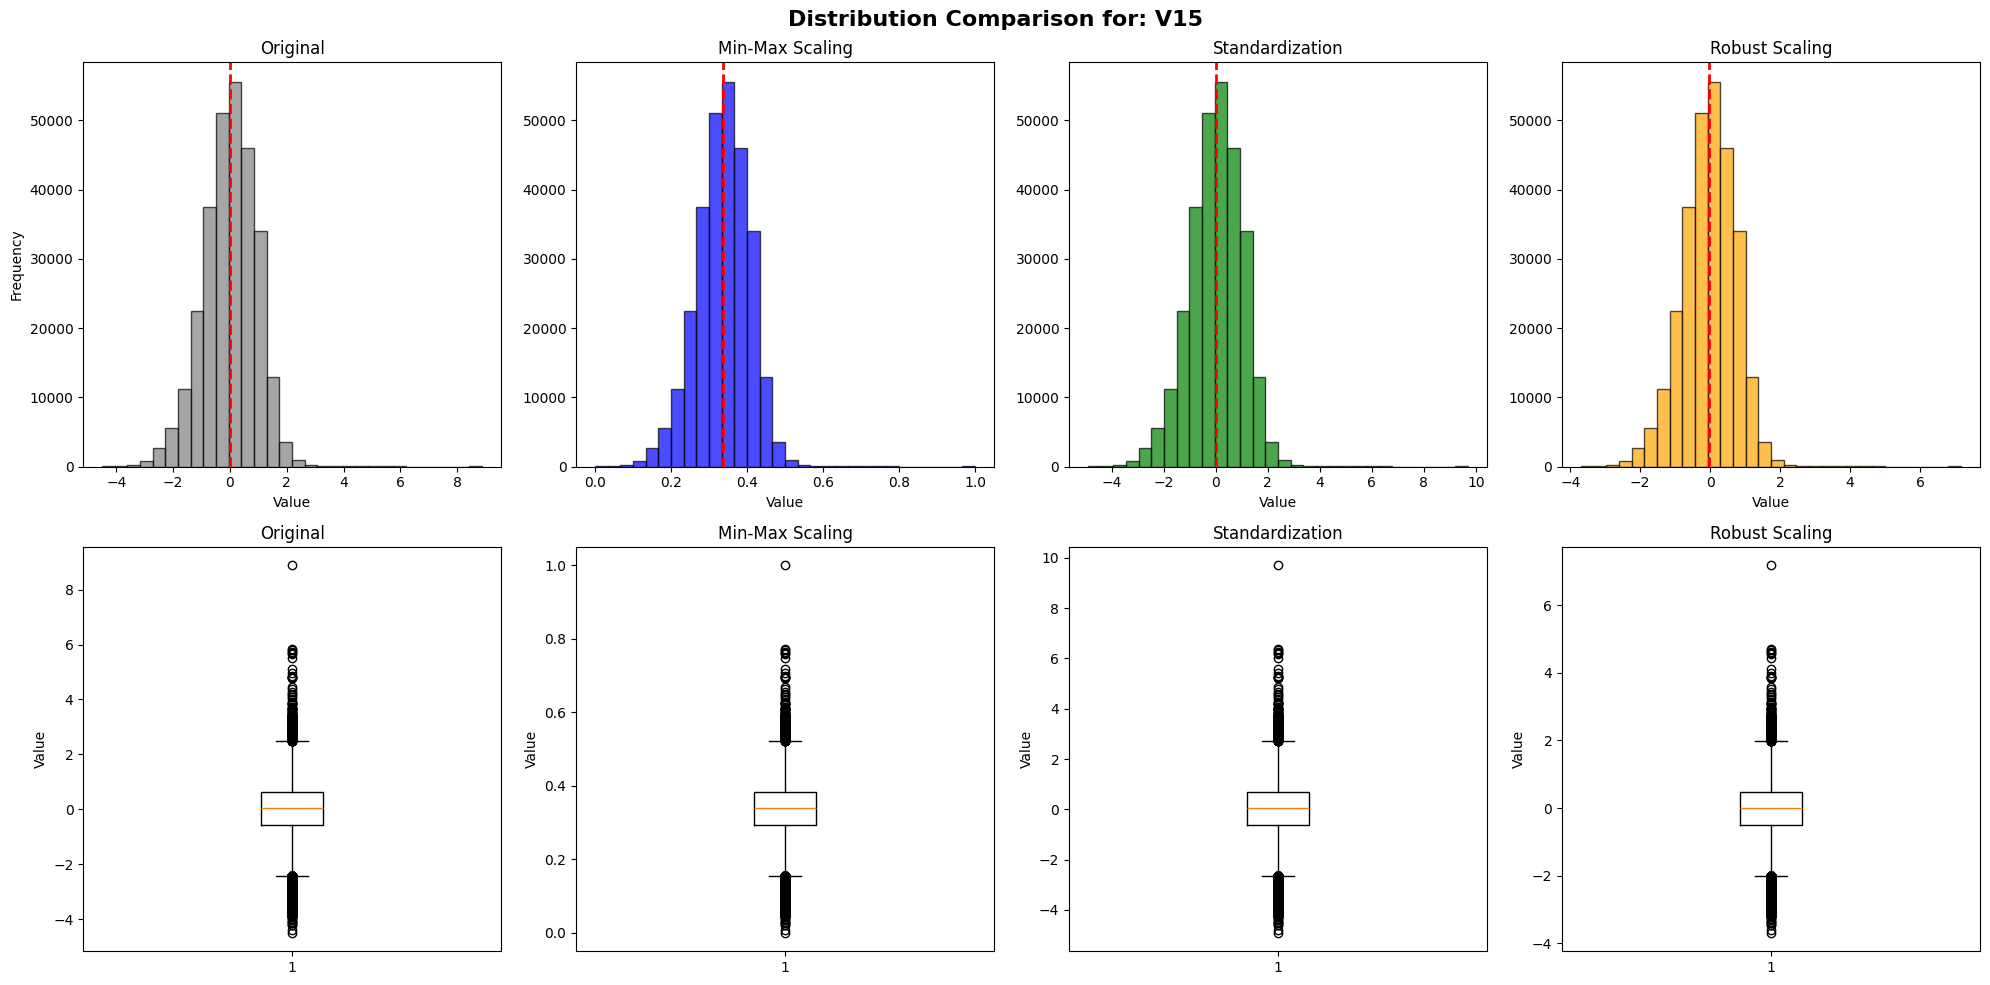

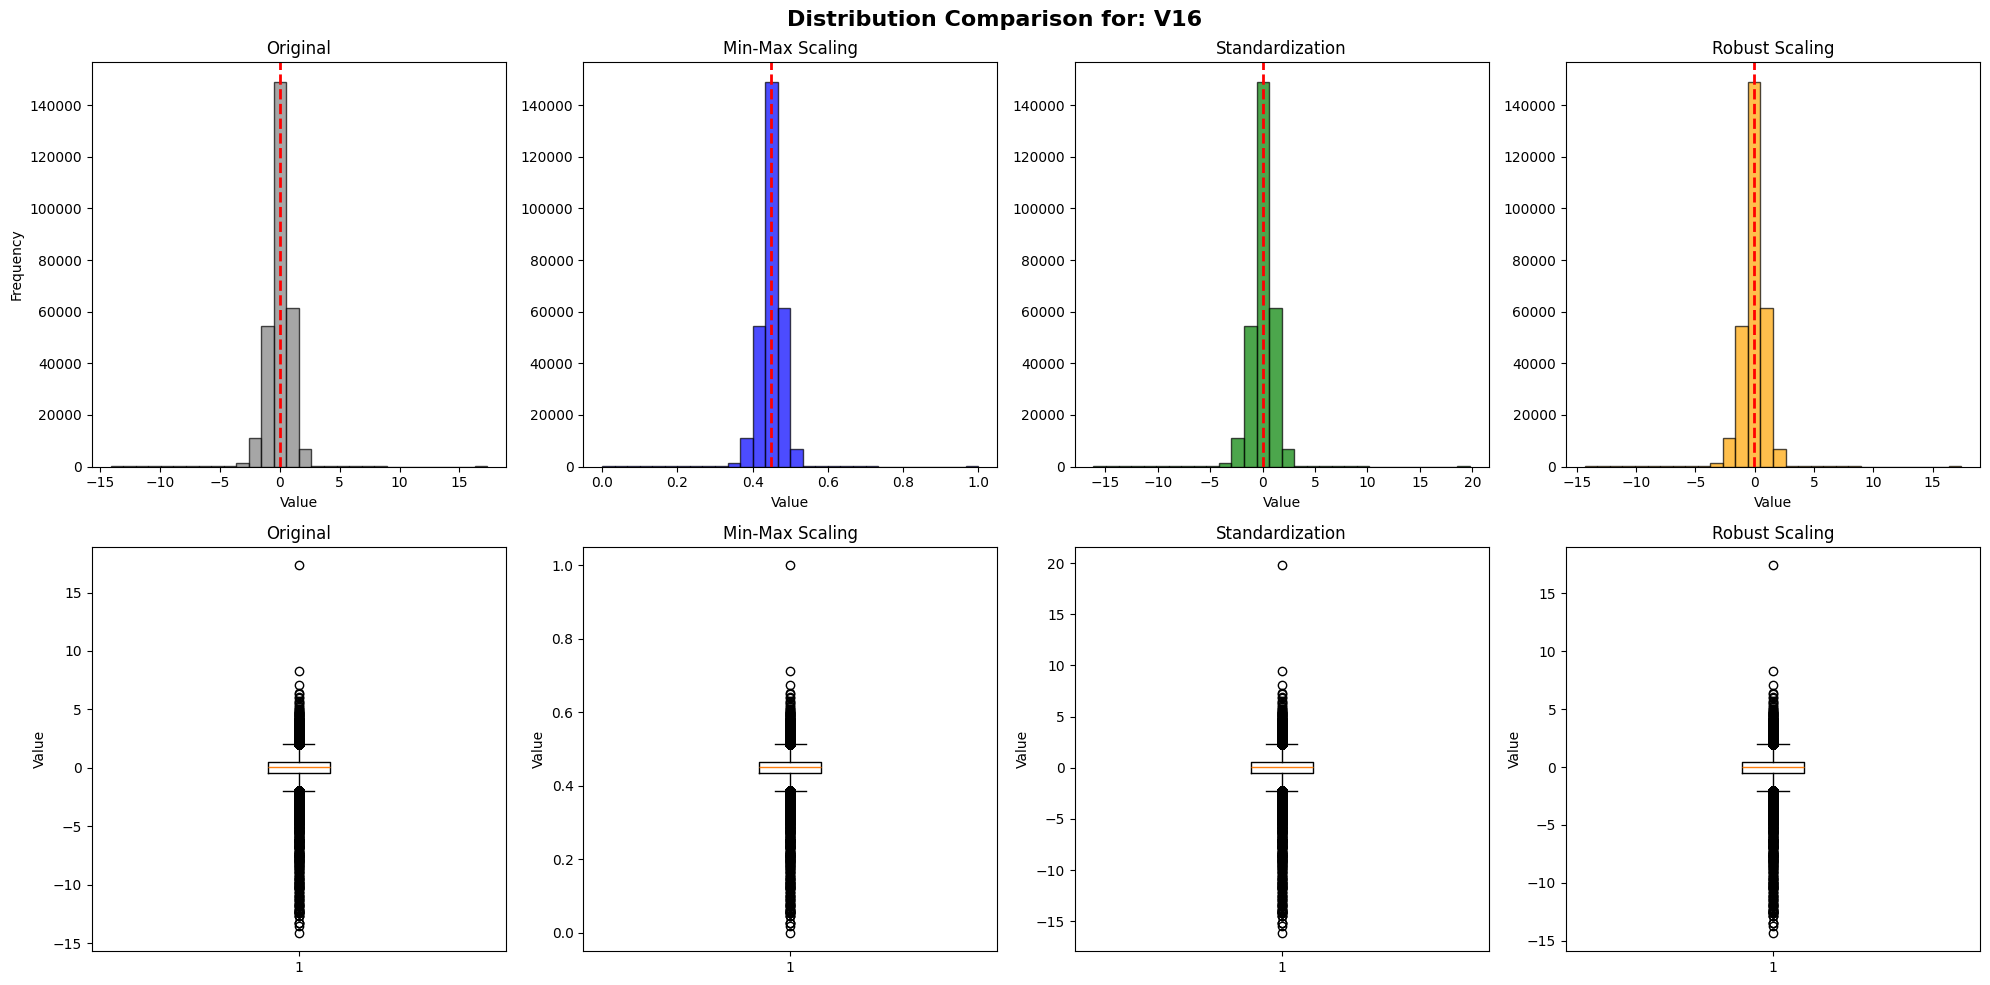

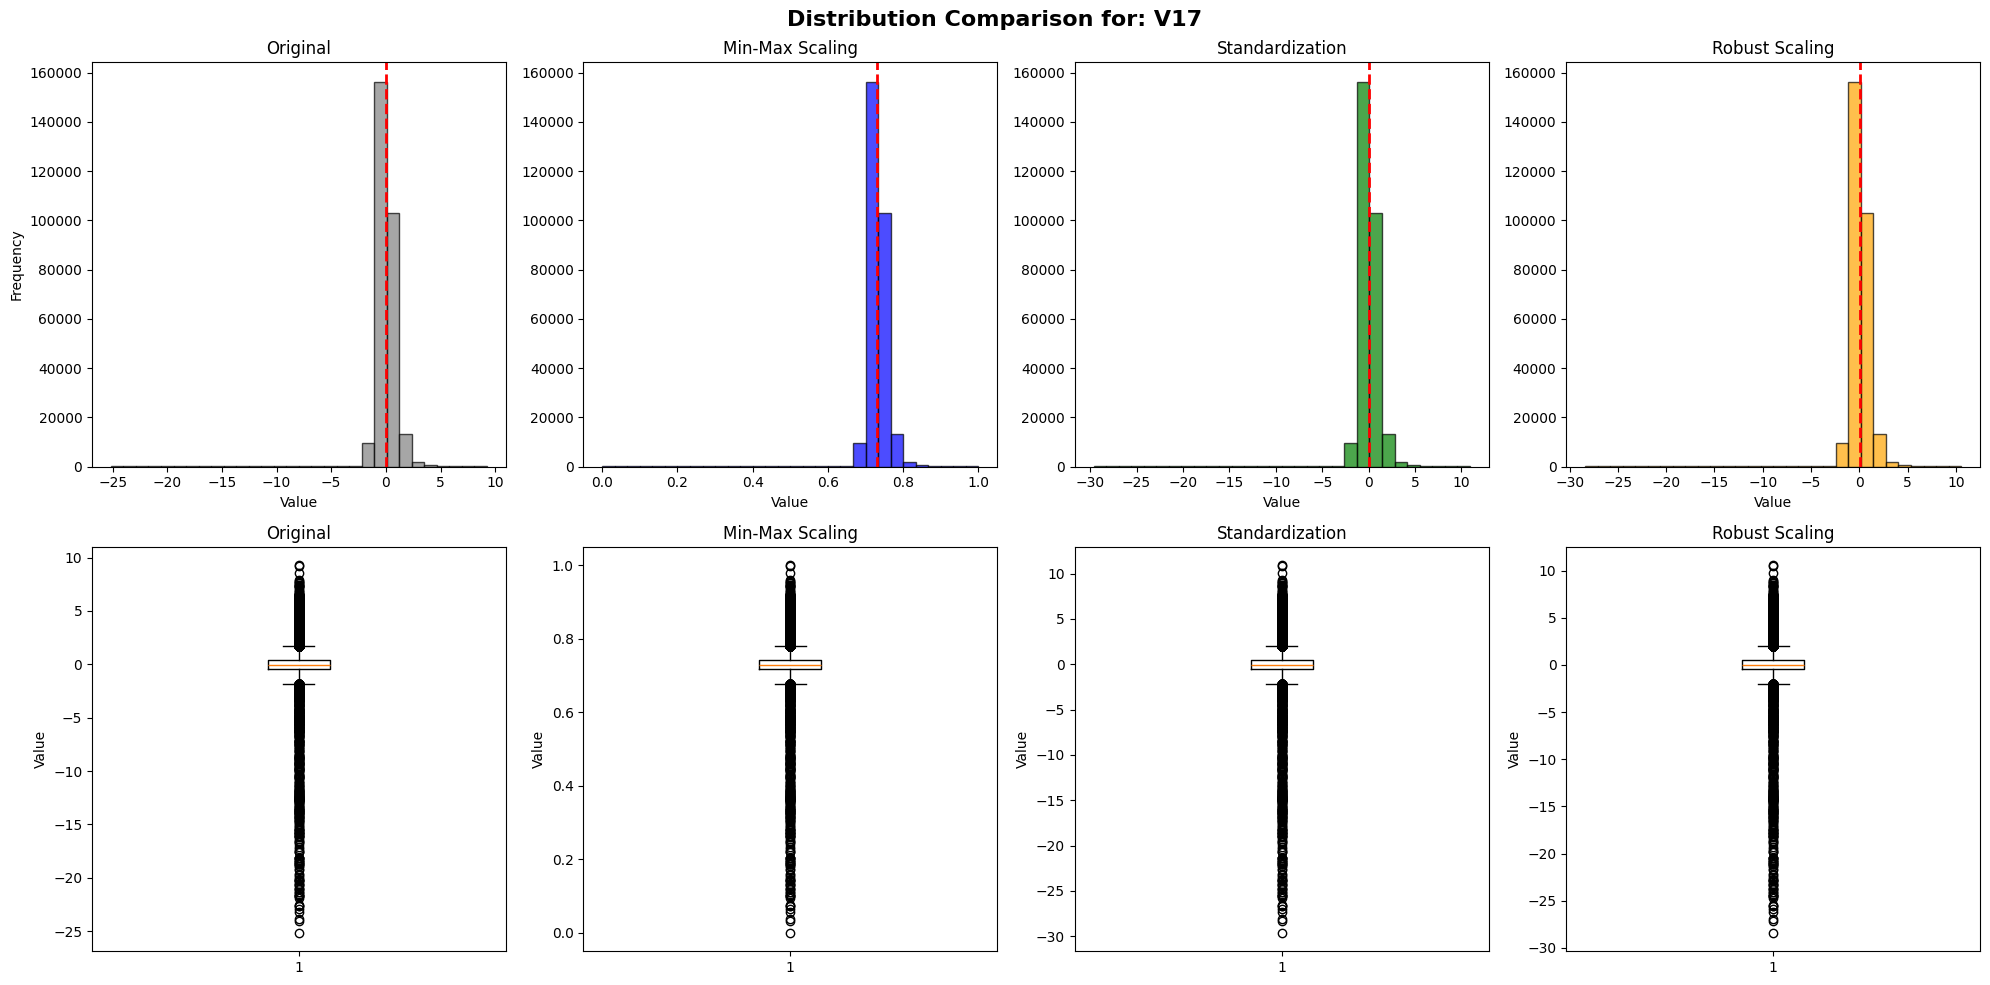

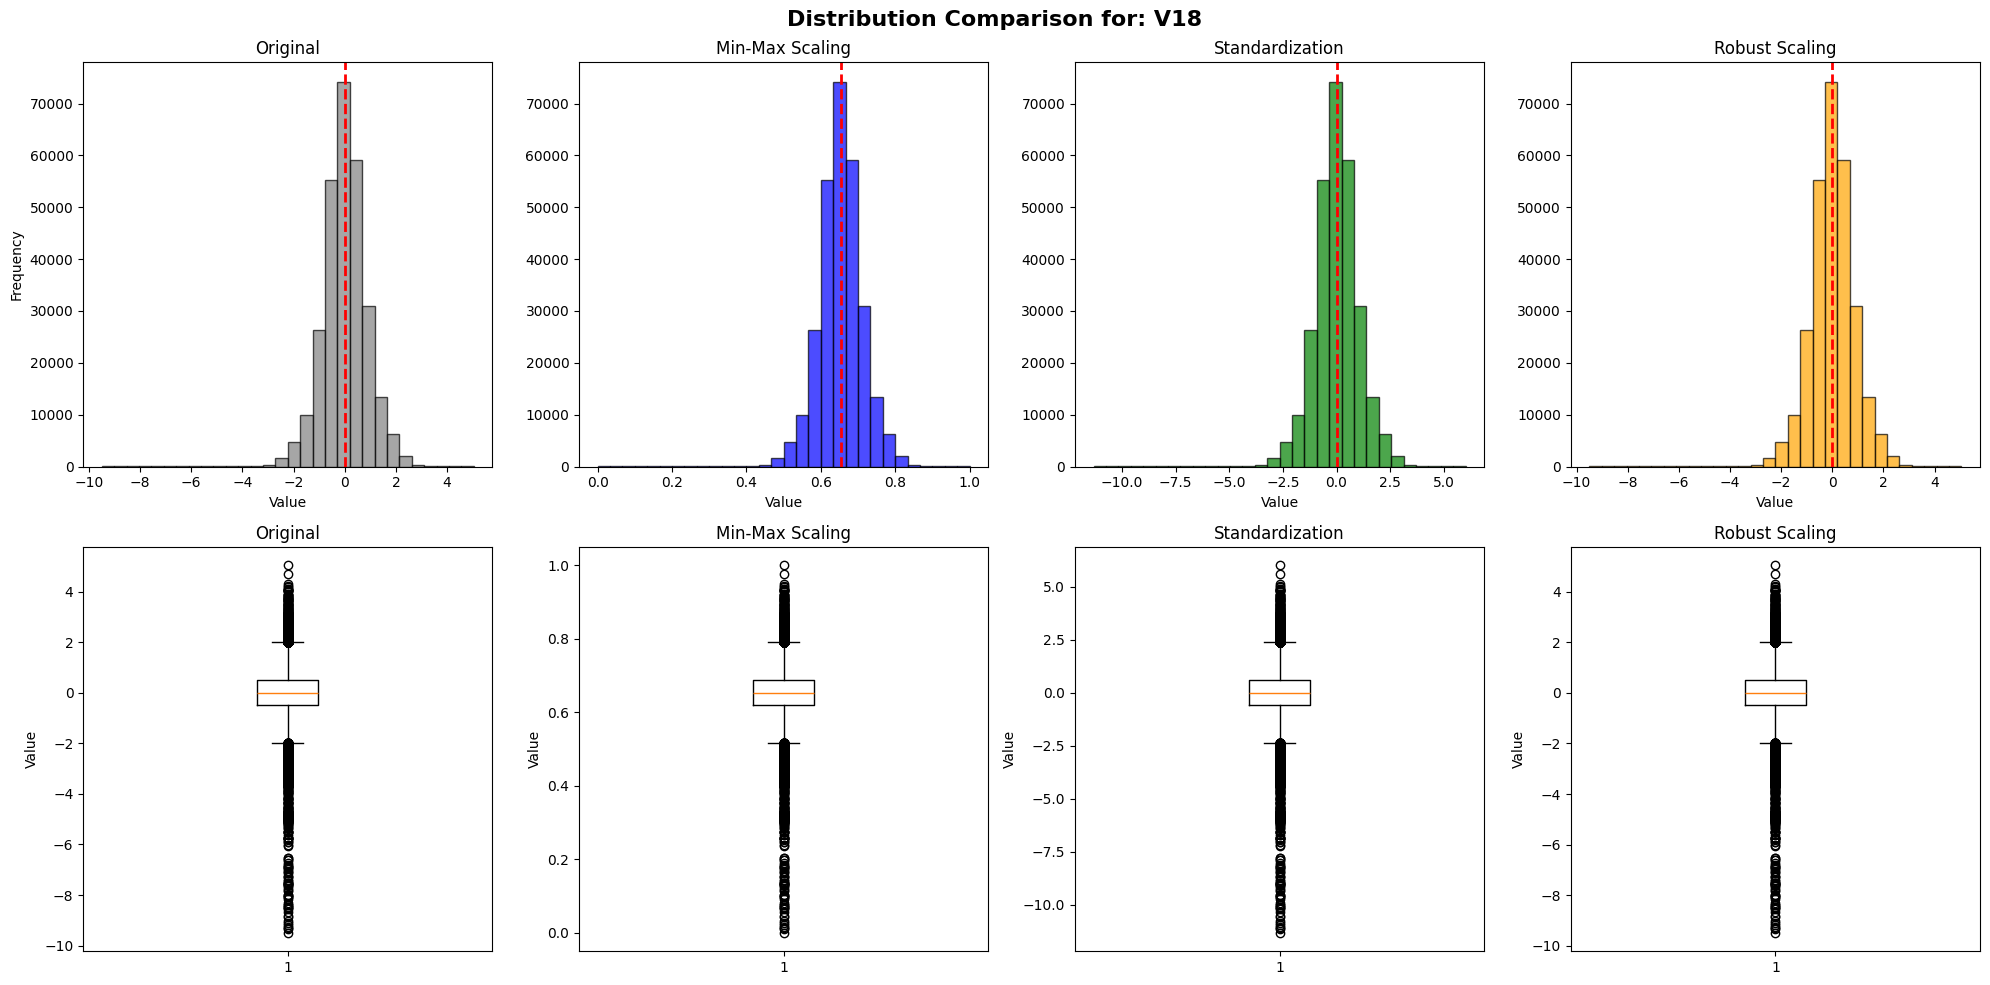

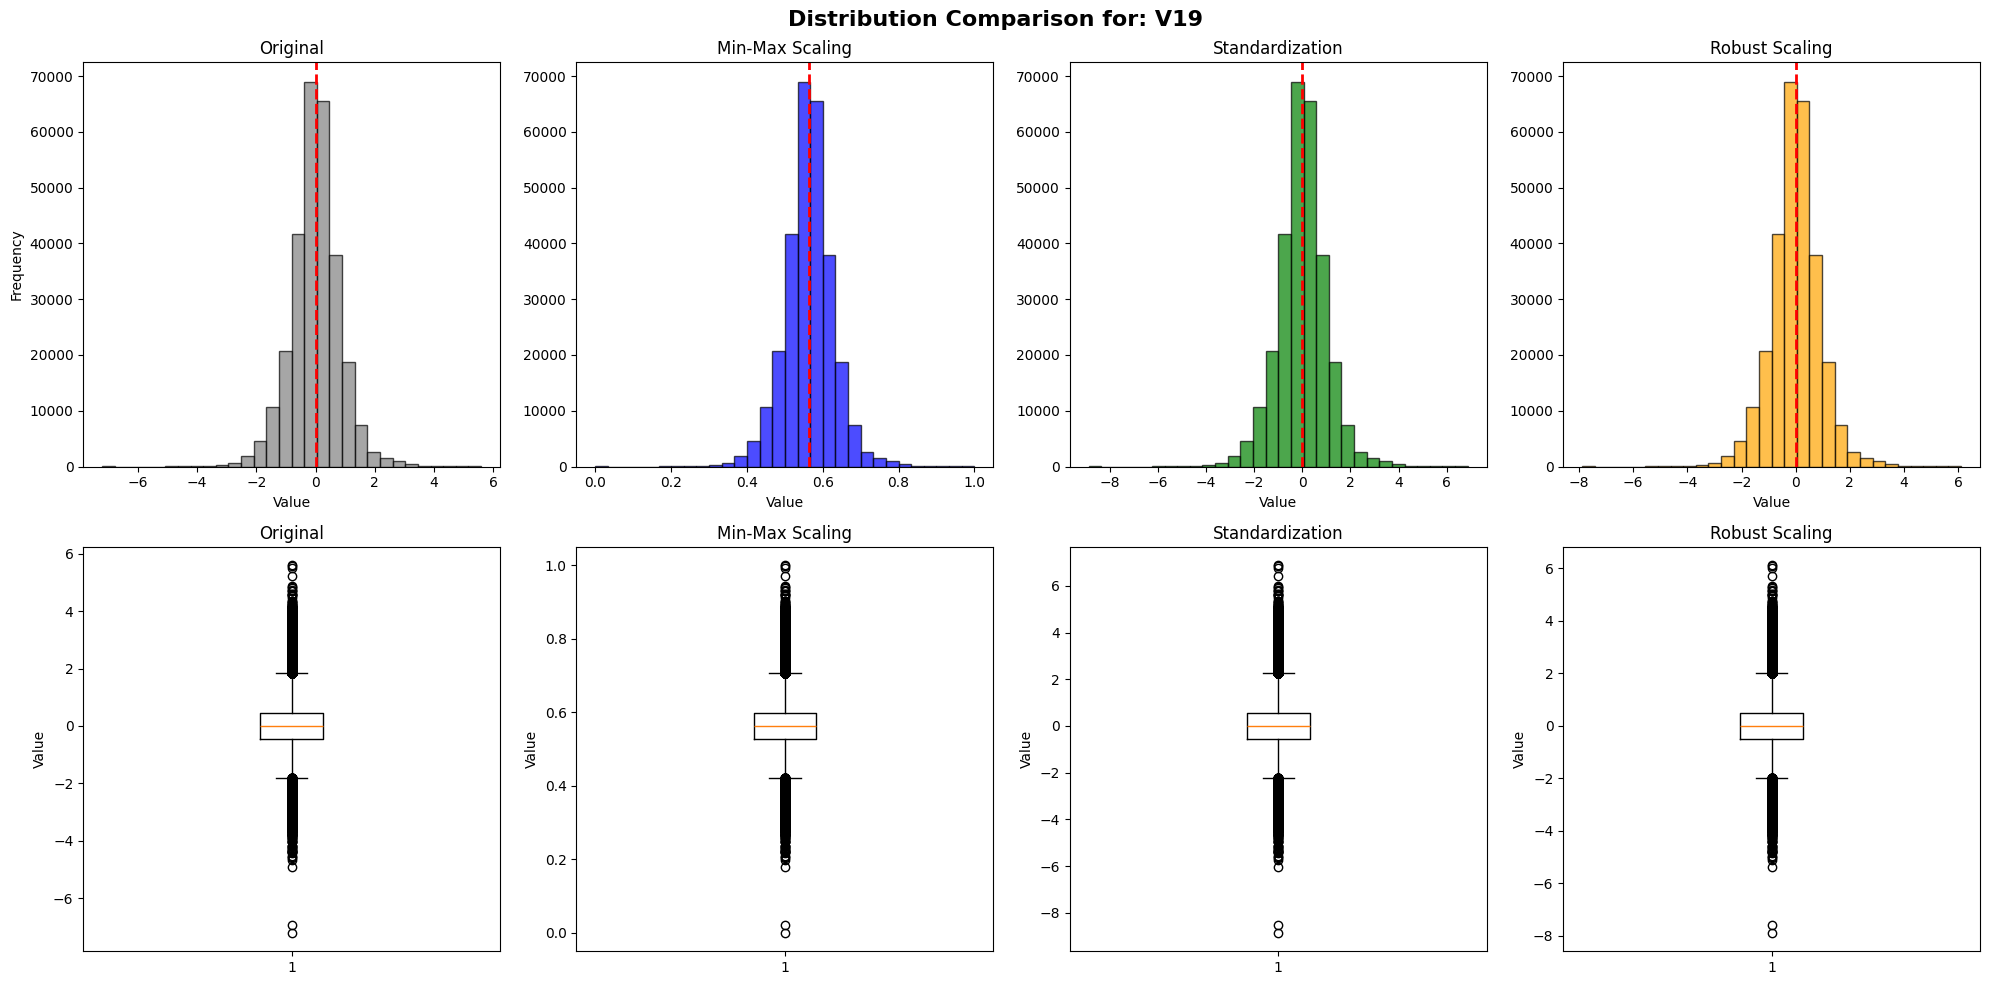

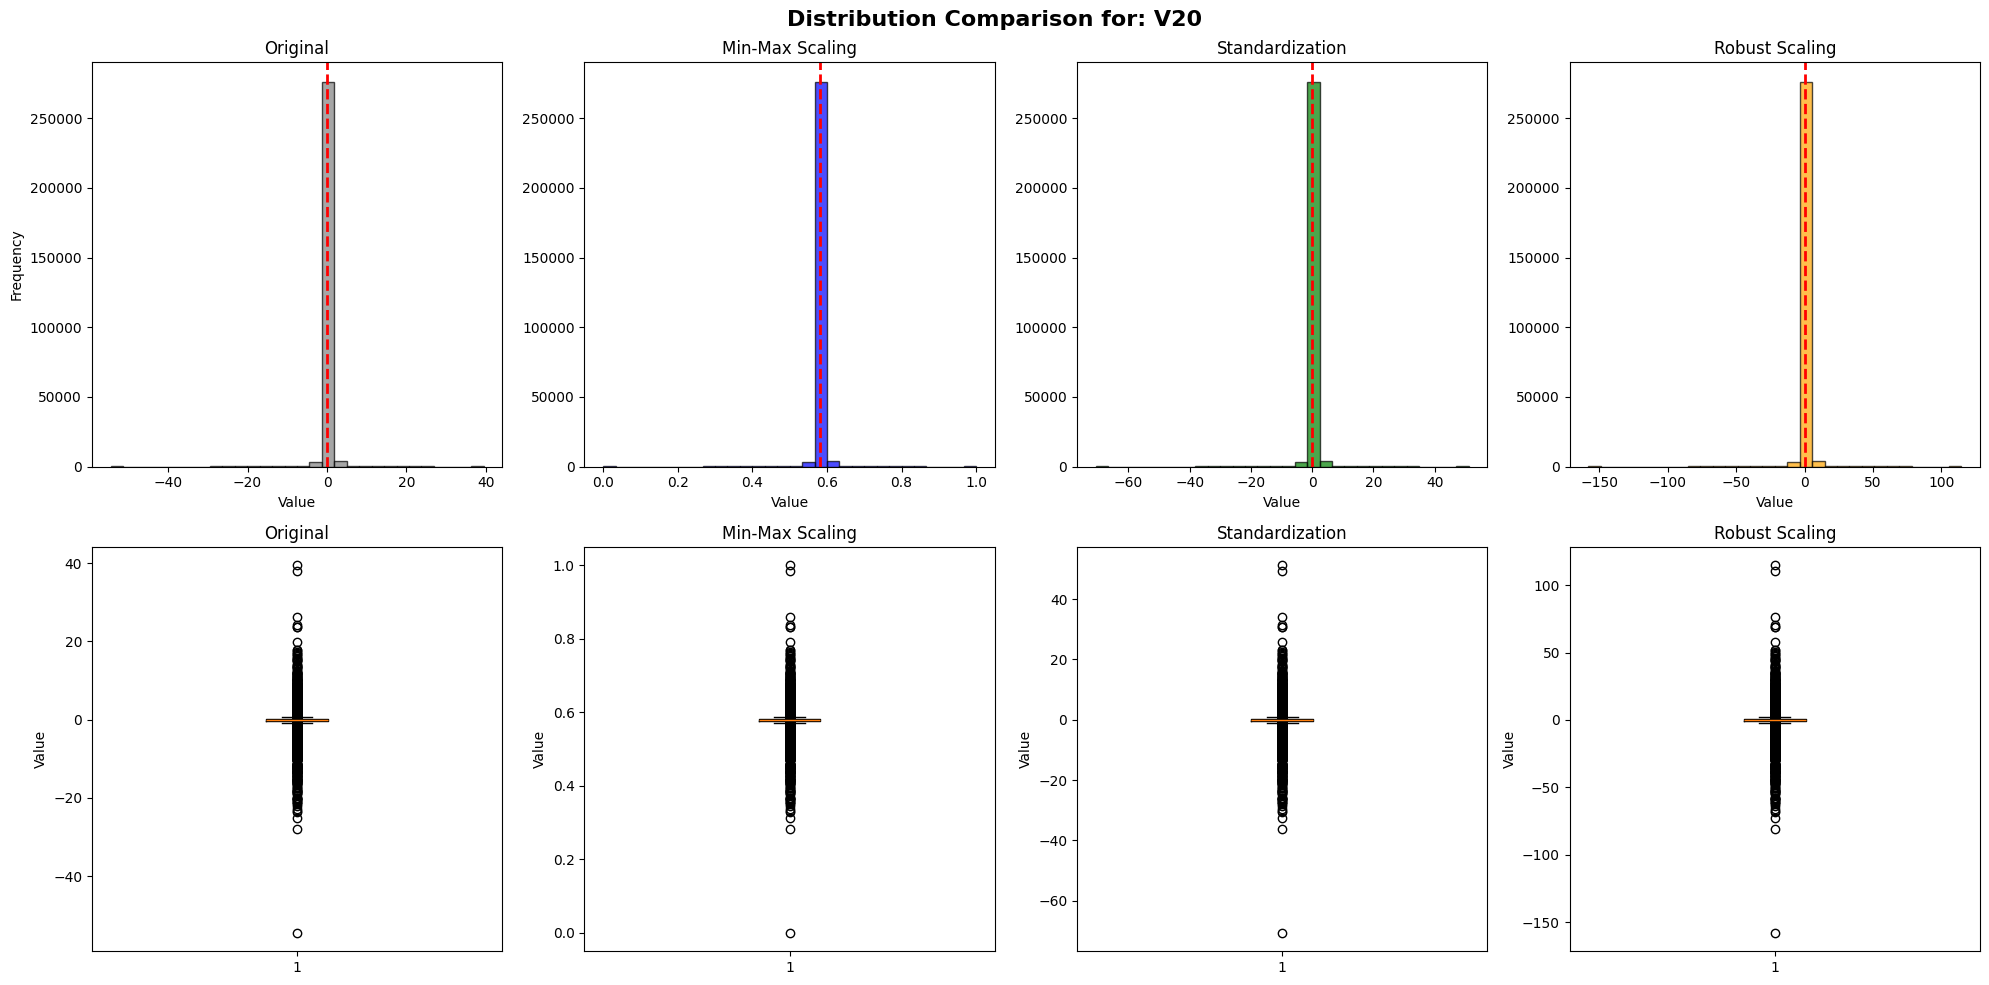

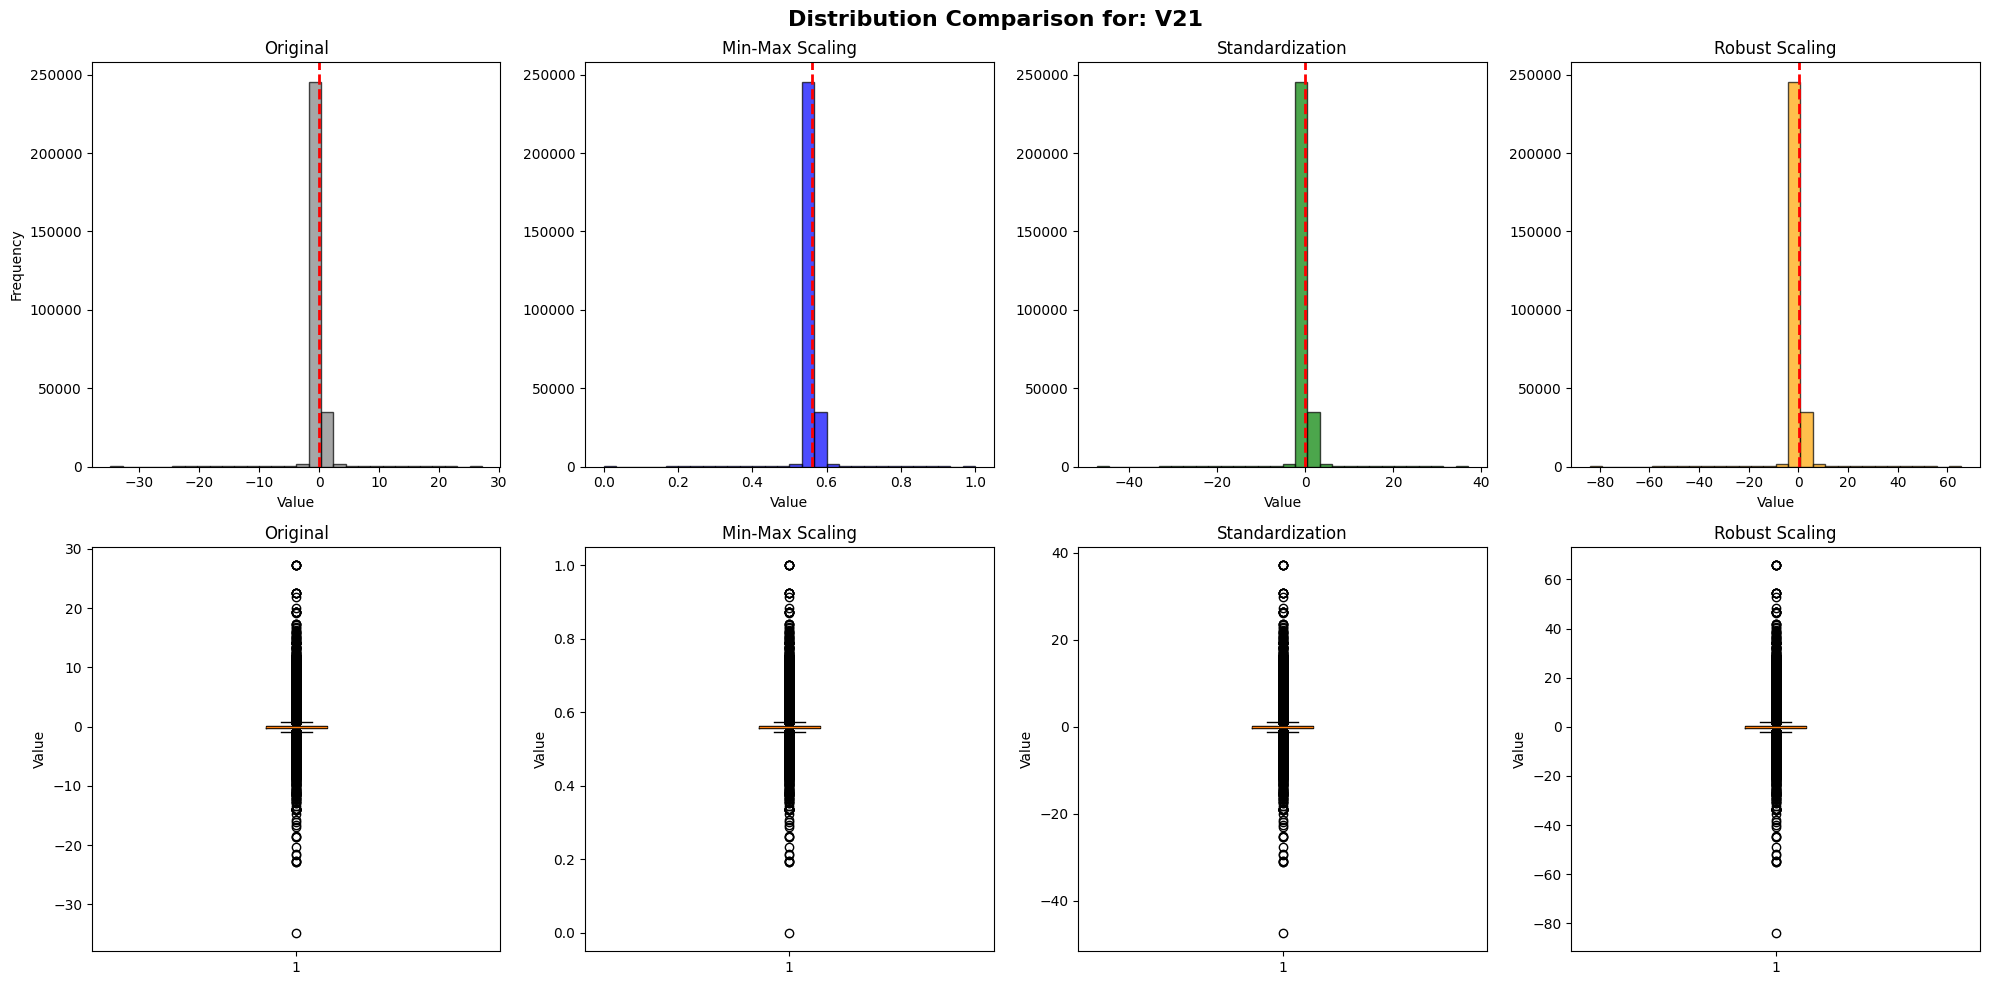

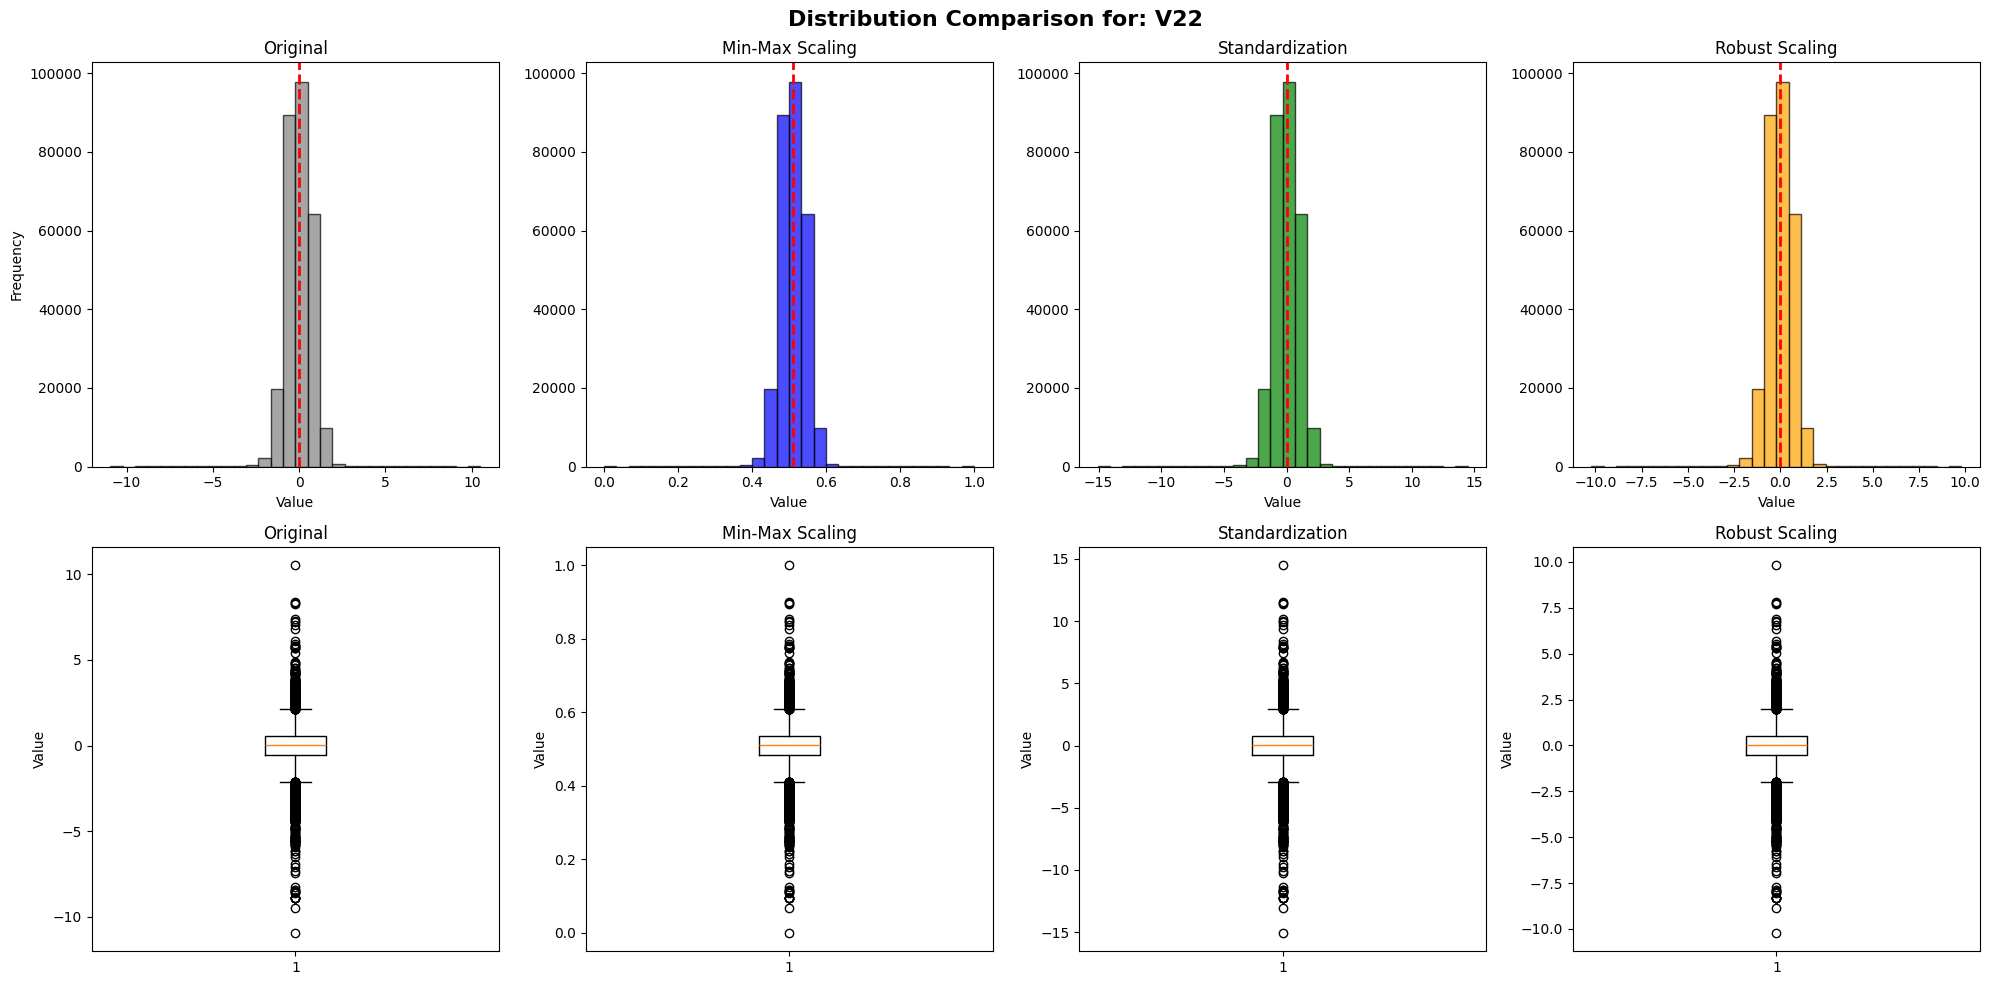

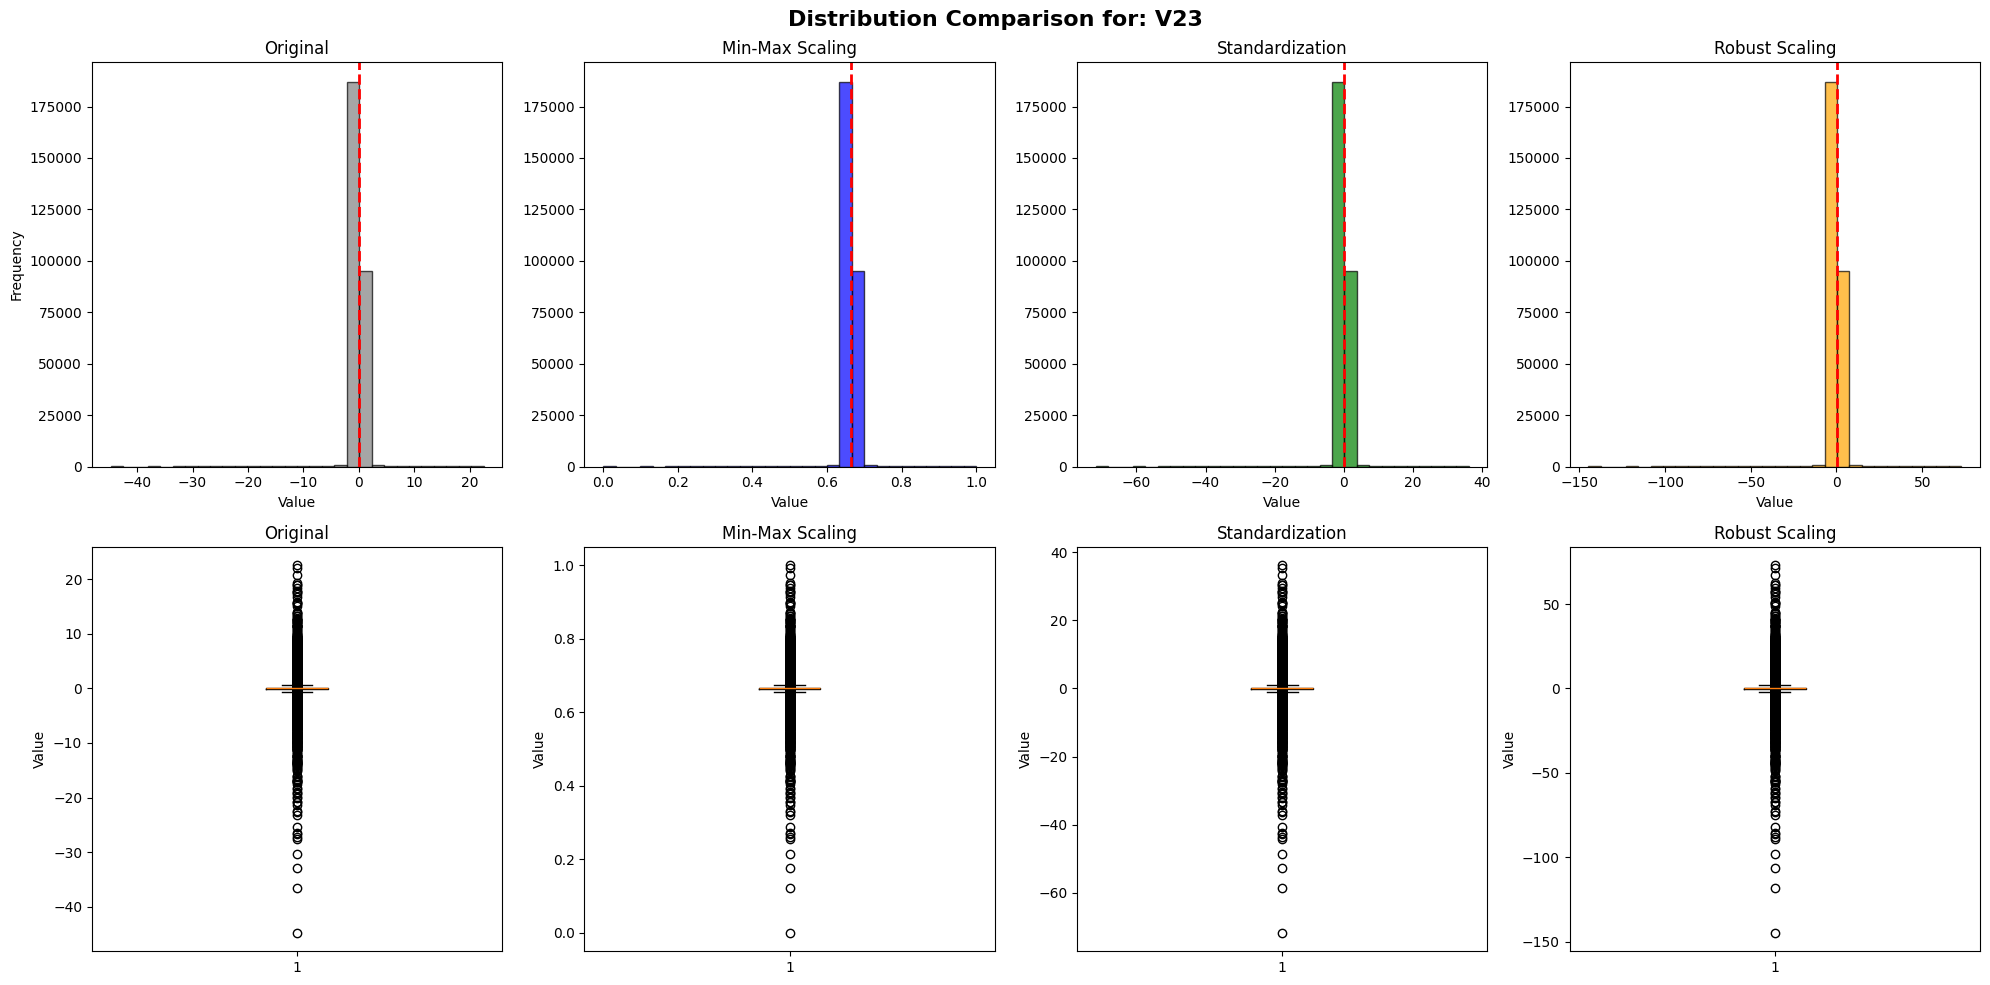

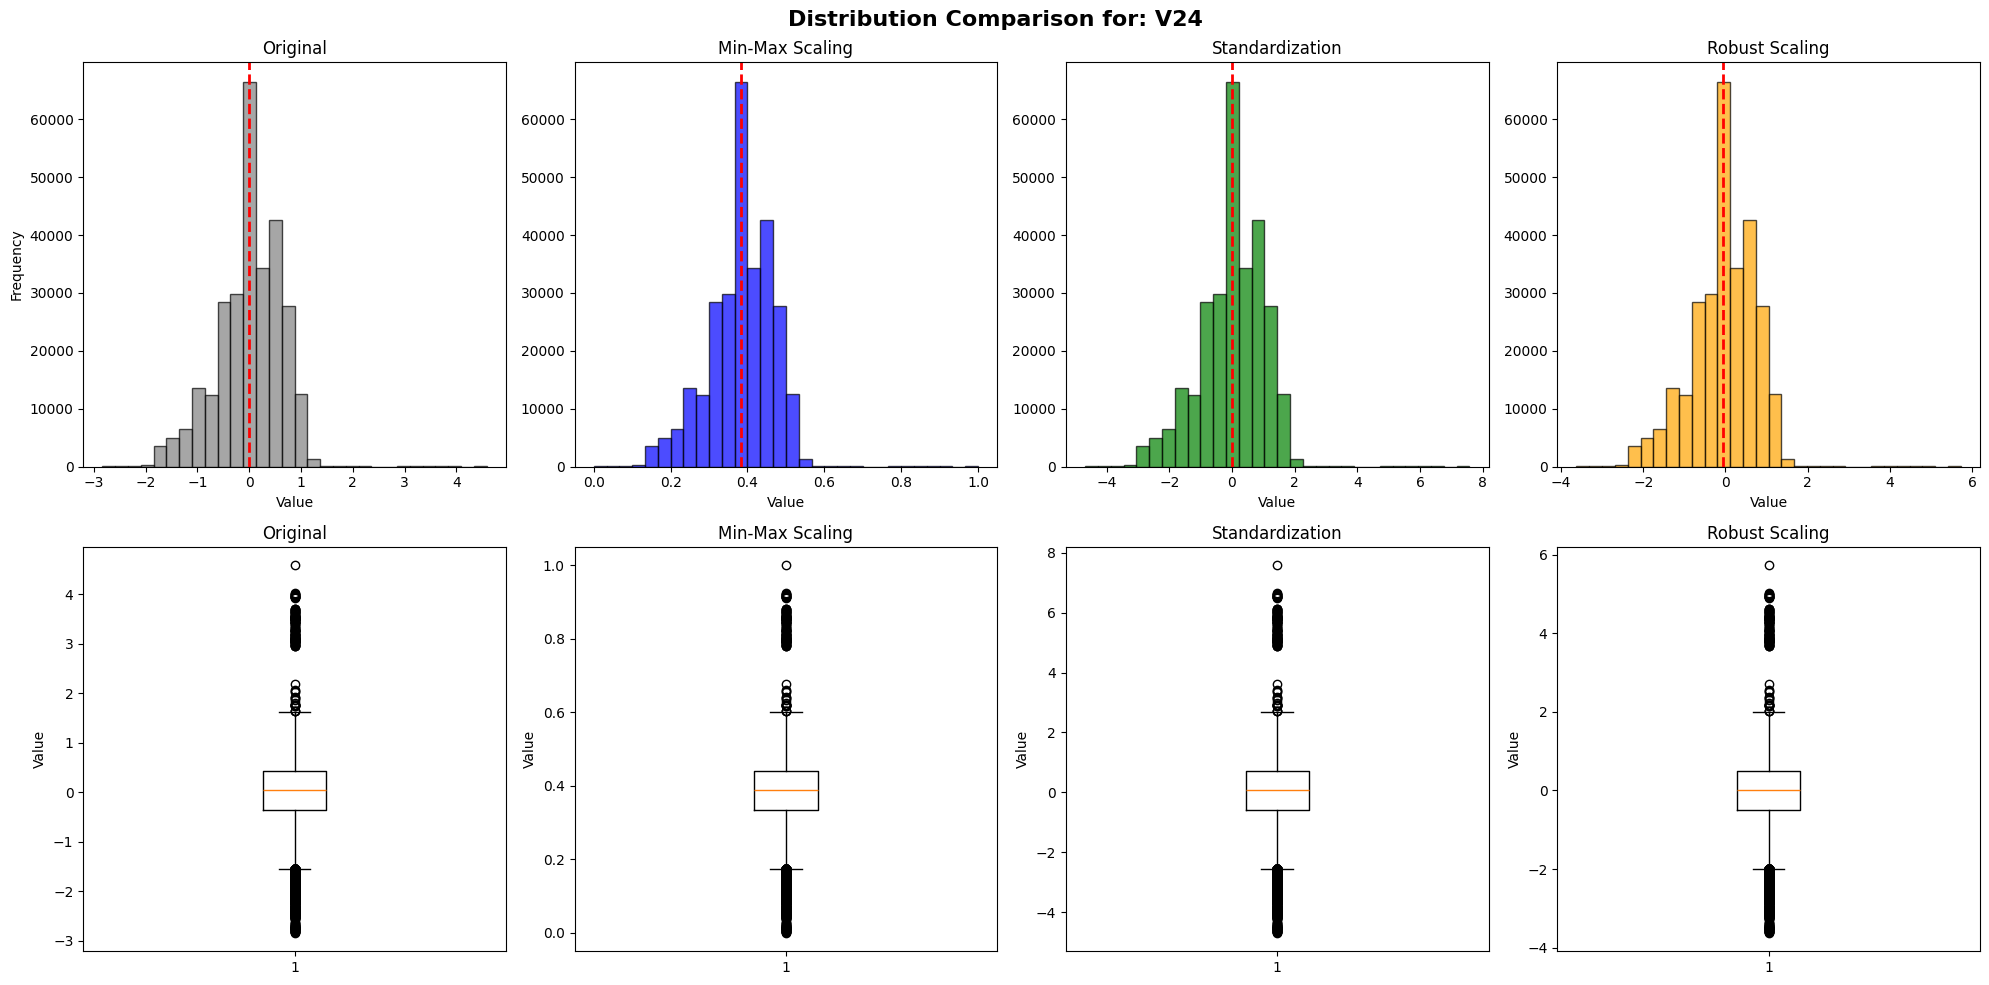

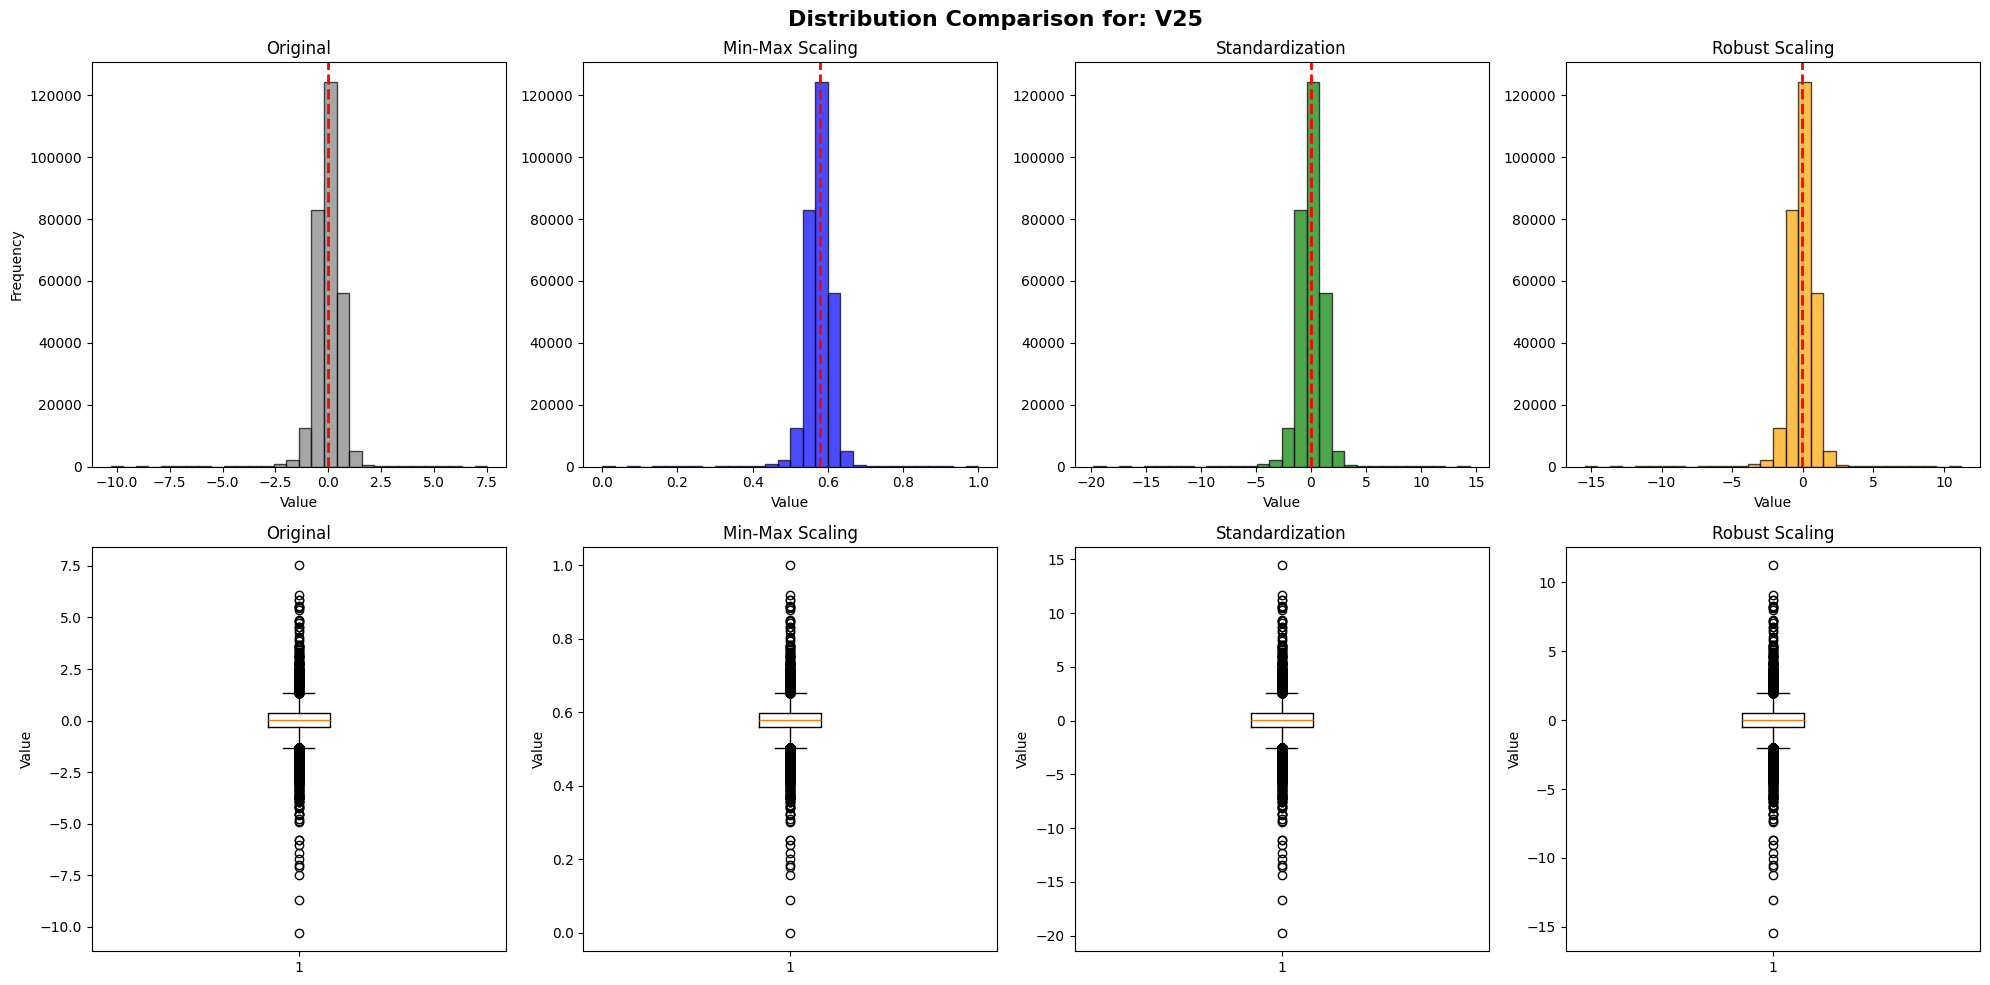

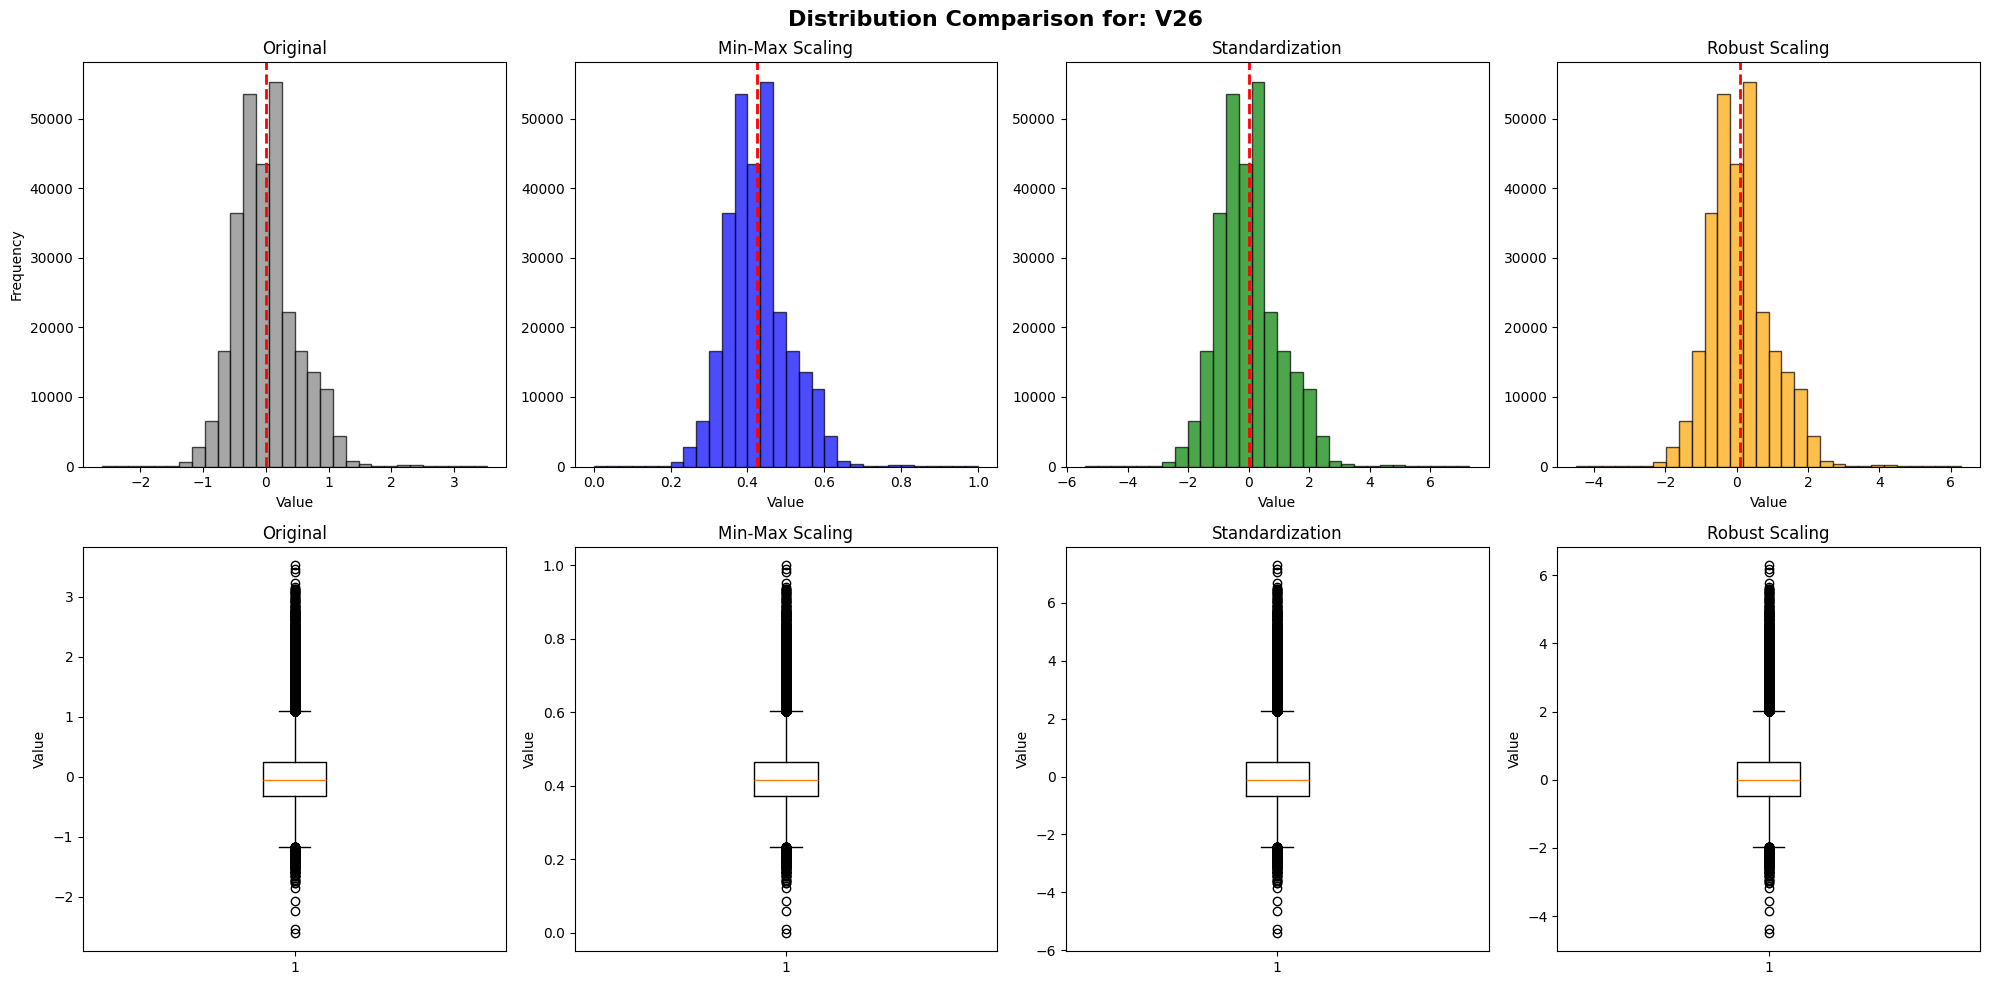

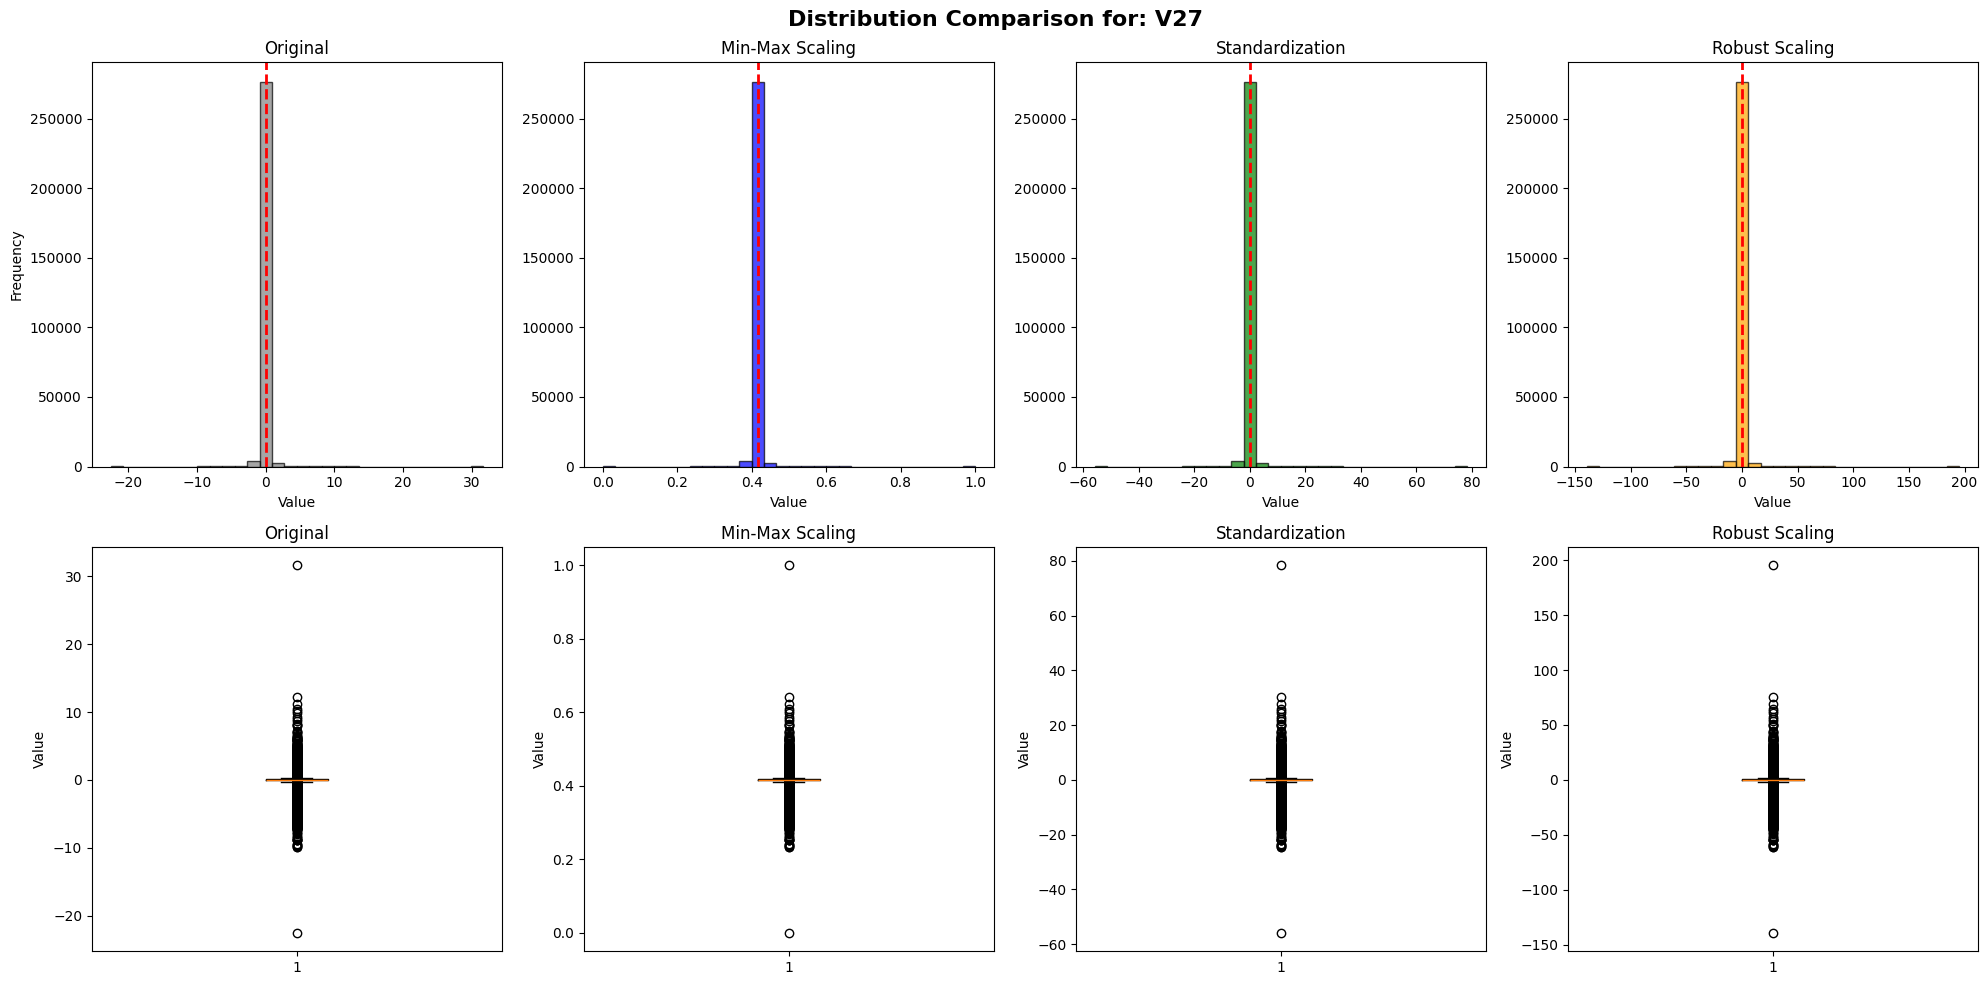

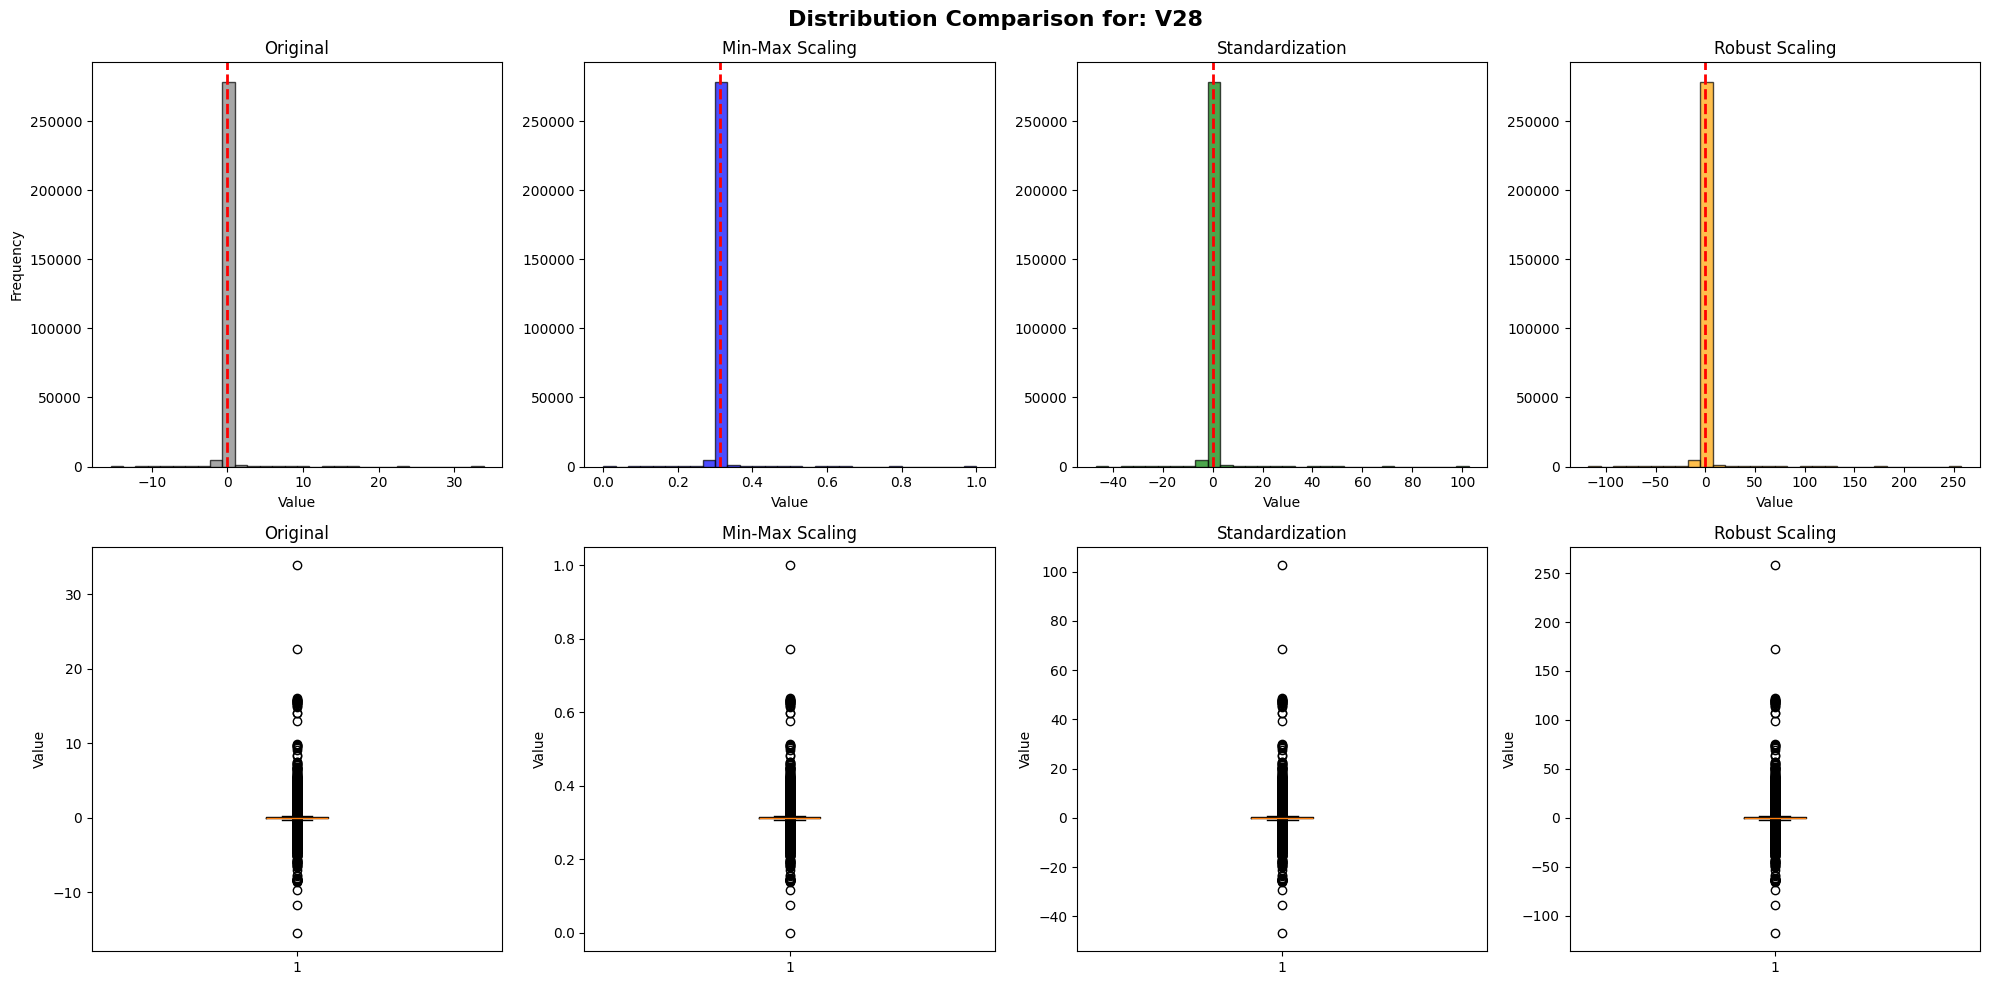

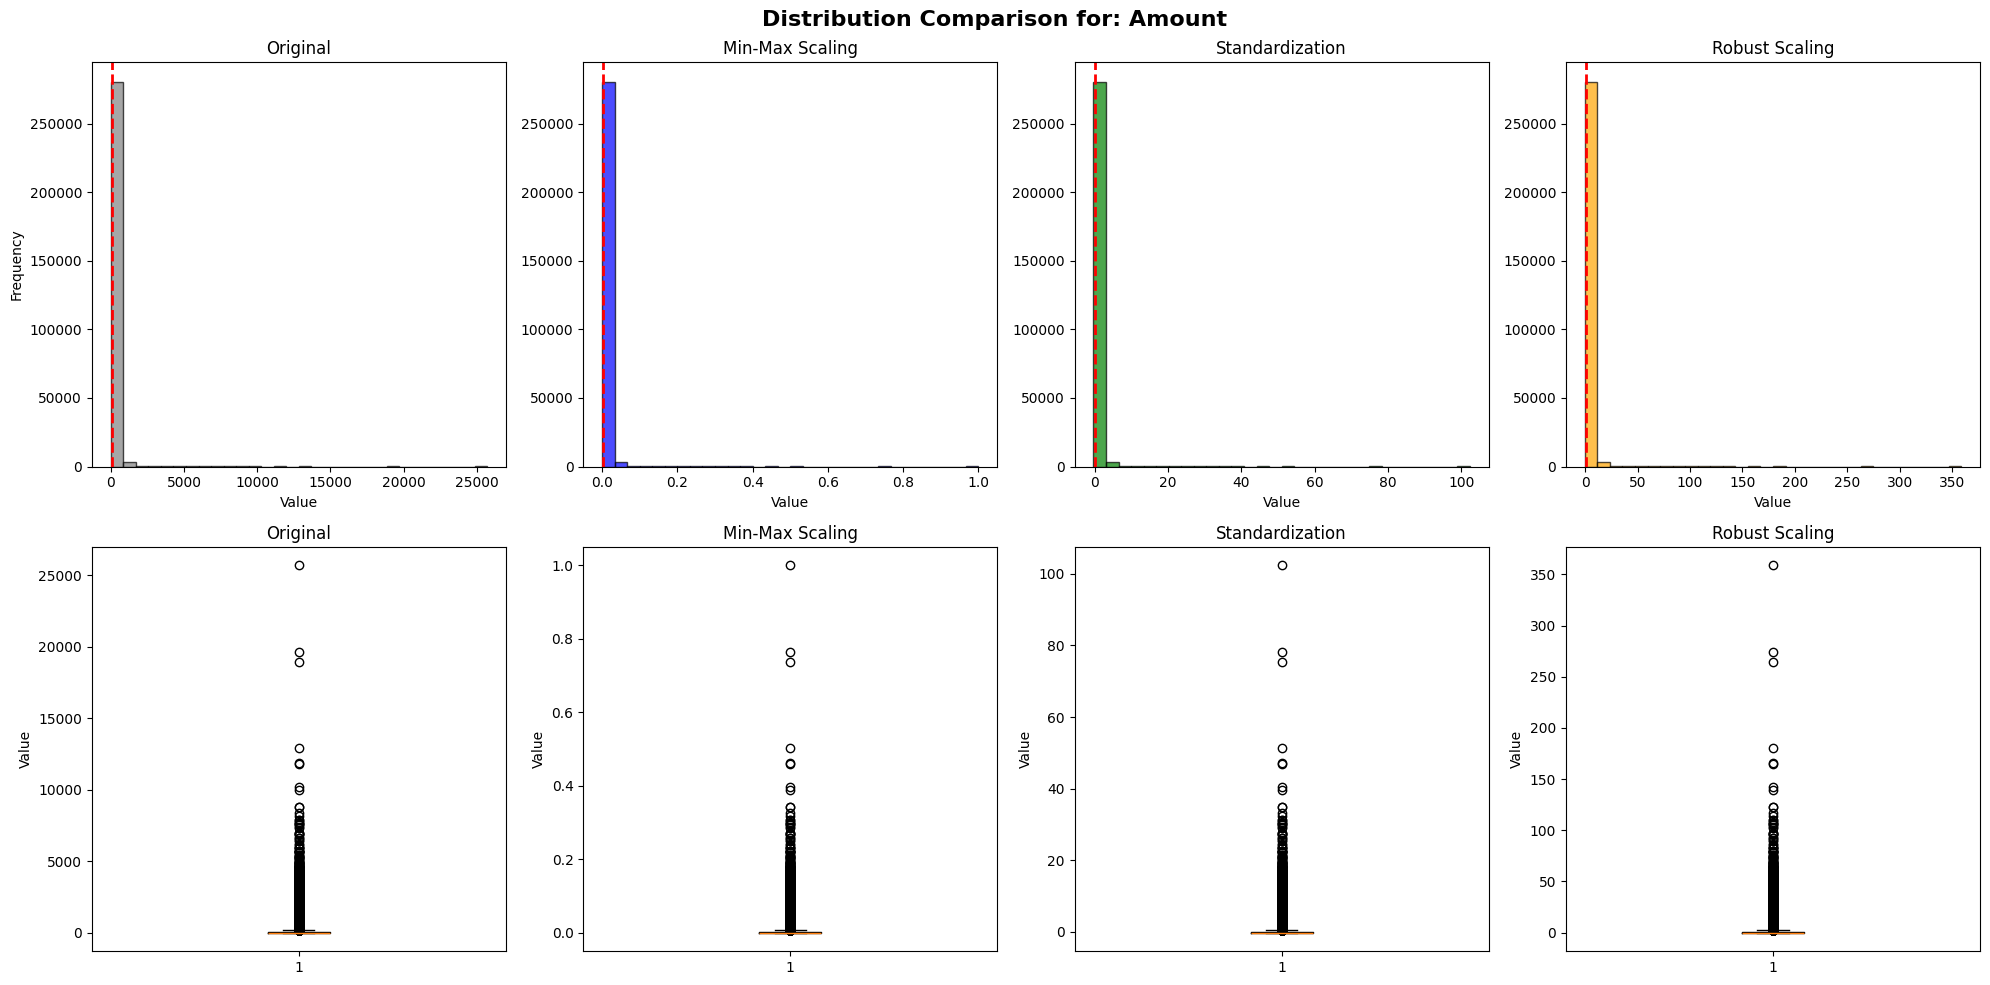

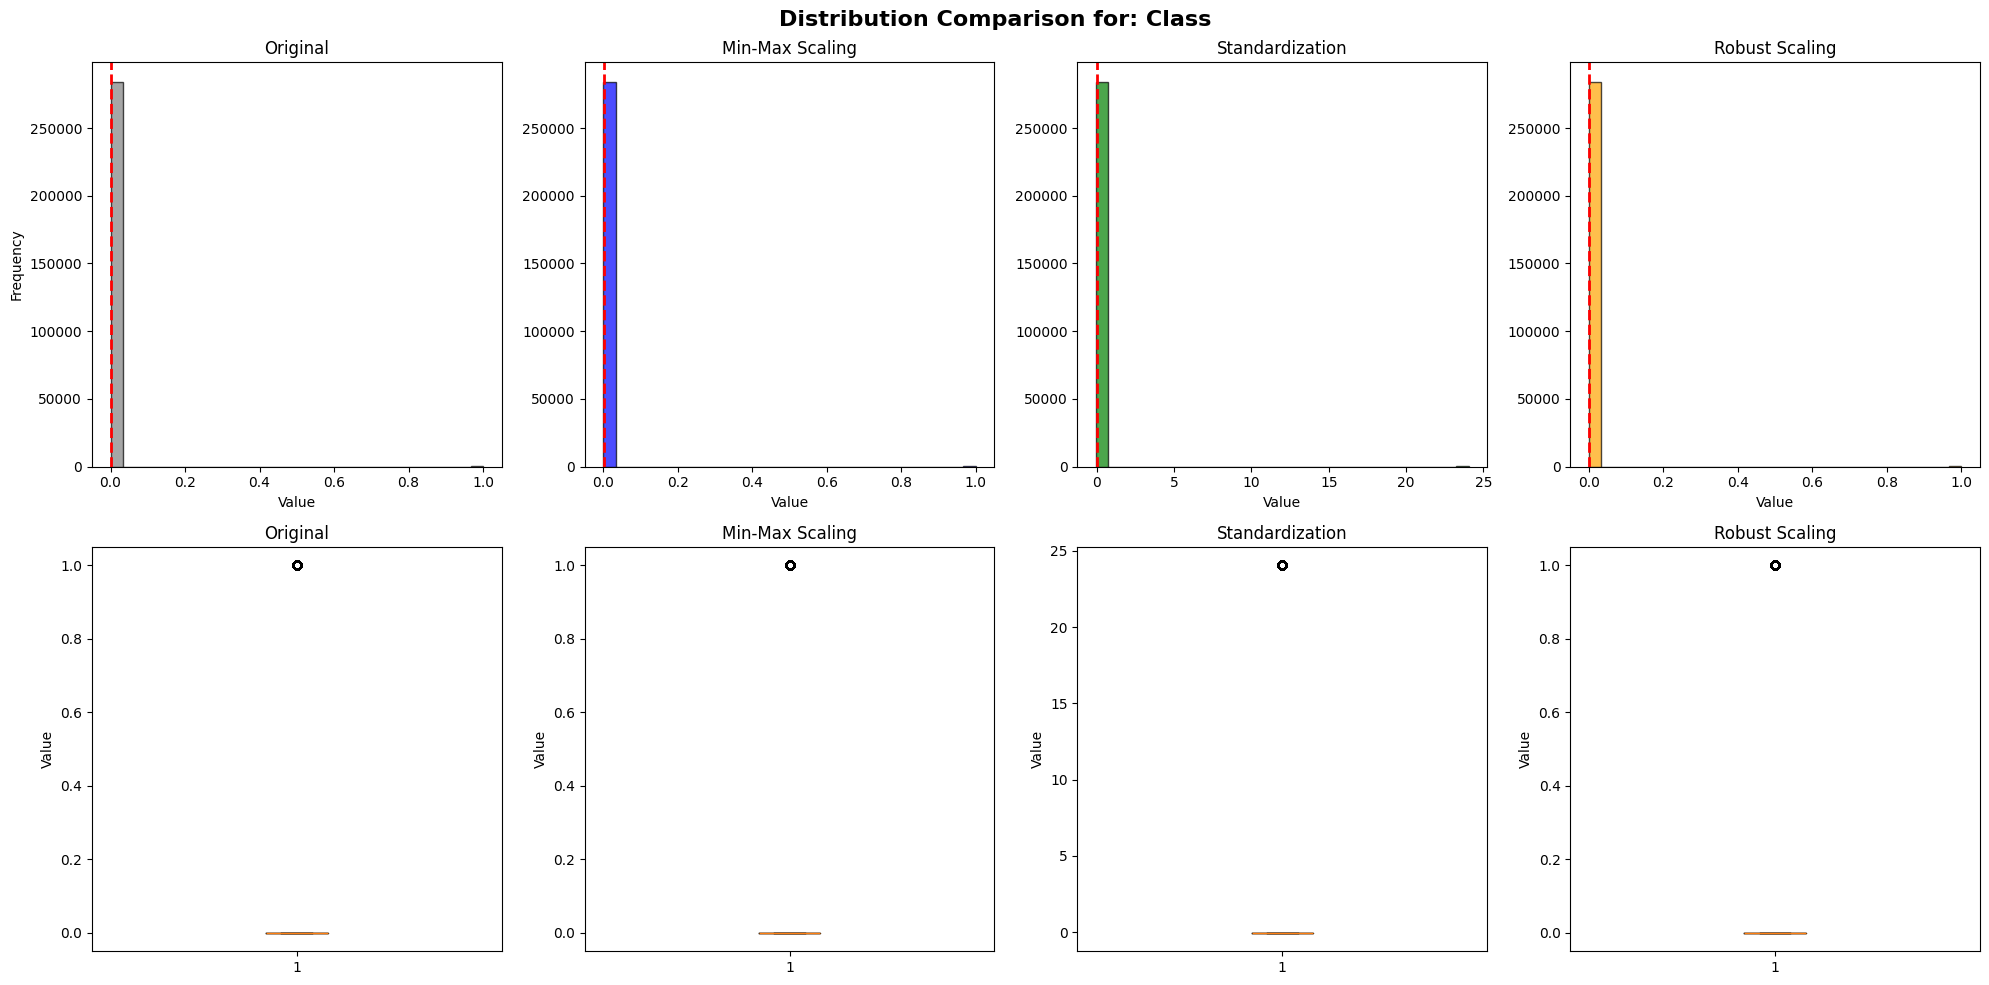

In [ ]:

# Visualize distributions before and after normalization
for col in numerical_cols:  # Limit to first 3 columns
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'Distribution Comparison for: {col}', fontsize=16, fontweight='bold')
    
    # Row 1: Histograms
    # Original
    axes[0, 0].hist(data[col], bins=30, color='gray', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Original')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(data[col].mean(), color='red', linestyle='--', linewidth=2)
    
    # Min-Max
    axes[0, 1].hist(data_minmax[col], bins=30, color='blue', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Min-Max Scaling')
    axes[0, 1].set_xlabel('Value')
    axes[0, 1].axvline(data_minmax[col].mean(), color='red', linestyle='--', linewidth=2)
    
    # Standardization
    axes[0, 2].hist(data_standard[col], bins=30, color='green', edgecolor='black', alpha=0.7)
    axes[0, 2].set_title('Standardization')
    axes[0, 2].set_xlabel('Value')
    axes[0, 2].axvline(data_standard[col].mean(), color='red', linestyle='--', linewidth=2)
    
    # Robust
    axes[0, 3].hist(data_robust[col], bins=30, color='orange', edgecolor='black', alpha=0.7)
    axes[0, 3].set_title('Robust Scaling')
    axes[0, 3].set_xlabel('Value')
    axes[0, 3].axvline(data_robust[col].mean(), color='red', linestyle='--', linewidth=2)
    
    # Row 2: Box plots
    axes[1, 0].boxplot(data[col].dropna(), vert=True)
    axes[1, 0].set_title('Original')
    axes[1, 0].set_ylabel('Value')
    
    axes[1, 1].boxplot(data_minmax[col].dropna(), vert=True)
    axes[1, 1].set_title('Min-Max Scaling')
    axes[1, 1].set_ylabel('Value')
    
    axes[1, 2].boxplot(data_standard[col].dropna(), vert=True)
    axes[1, 2].set_title('Standardization')
    axes[1, 2].set_ylabel('Value')
    
    axes[1, 3].boxplot(data_robust[col].dropna(), vert=True)
    axes[1, 3].set_title('Robust Scaling')
    axes[1, 3].set_ylabel('Value')
    
    plt.tight_layout()
    plt.show()


In [15]:
# Analyze which is best based on outlier count
total_outliers = sum(outlier_summary.values())
outlier_percentage = (total_outliers / (len(data) * len(numerical_cols))) * 100

if outlier_percentage > 10:
    print(f"  → ROBUST SCALING recommended ({outlier_percentage:.1f}% outliers detected)")
    print("    Your data has significant outliers that would distort Min-Max and Standard scaling")
    data_normalized = data_robust.copy()
    scaler_used = "Robust Scaling"
elif outlier_percentage > 5:
    print(f"  → STANDARDIZATION recommended ({outlier_percentage:.1f}% outliers detected)")
    print("    Moderate outliers present; standardization balances robustness and performance")
    data_normalized = data_standard.copy()
    scaler_used = "Standardization"
else:
    print(f"  → MIN-MAX SCALING recommended ({outlier_percentage:.1f}% outliers detected)")
    print("    Few outliers; Min-Max scaling provides bounded [0,1] range for algorithms")
    data_normalized = data_minmax.copy()
    scaler_used = "Min-Max Scaling"

print(f"\n✓ Final normalized dataset uses: {scaler_used}")
print(f"  Total rows: {len(data_normalized)}")
print(f"  Normalized columns: {len(numerical_cols)}")

  → MIN-MAX SCALING recommended (4.2% outliers detected)
    Few outliers; Min-Max scaling provides bounded [0,1] range for algorithms

✓ Final normalized dataset uses: Min-Max Scaling
  Total rows: 284807
  Normalized columns: 31


### V. Categorical Encoding: 
Identify categorical variables requiring encoding. Apply suitable encoding for each type of categorical variable, such as one-hot encoding for nominal variables and ordinal encoding for ordinal variables. Discuss strategies for handling high-cardinality categorical features.

In [16]:
# Get categorical columns from the normalized dataset
categorical_cols = data_normalized.select_dtypes(include=['object']).columns.tolist()

print(f"\nCategorical columns to encode: {len(categorical_cols)}")
print(f"Columns: {categorical_cols}")

# Analyze cardinality of categorical variables
print("\n" + "-"*60)
print("Cardinality analysis")
print("-"*60)

cardinality_info = {}
for col in categorical_cols:
    unique_count = data_normalized[col].nunique()
    cardinality_info[col] = unique_count
    cardinality_pct = (unique_count / len(data_normalized)) * 100
    
    if cardinality_pct > 50:
        category = "Very High"
    elif cardinality_pct > 10:
        category = "High"
    elif unique_count > 10:
        category = "Medium"
    else:
        category = "Low"
    
    print(f"{col}: {unique_count} unique values ({cardinality_pct:.2f}%) - {category} Cardinality")



Categorical columns to encode: 0
Columns: []

------------------------------------------------------------
Cardinality analysis
------------------------------------------------------------


- There is no categorical columns so we don't need to do the encoding

### VI. Feature Selection: 

In [18]:
# Get all numerical features from encoded dataset
all_features = data_normalized.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

print(f"\nTotal features available: {len(all_features)}")
print(f"Dataset shape: {data_normalized.shape}")


Total features available: 31
Dataset shape: (284807, 31)



Method 1: Correlation matrix


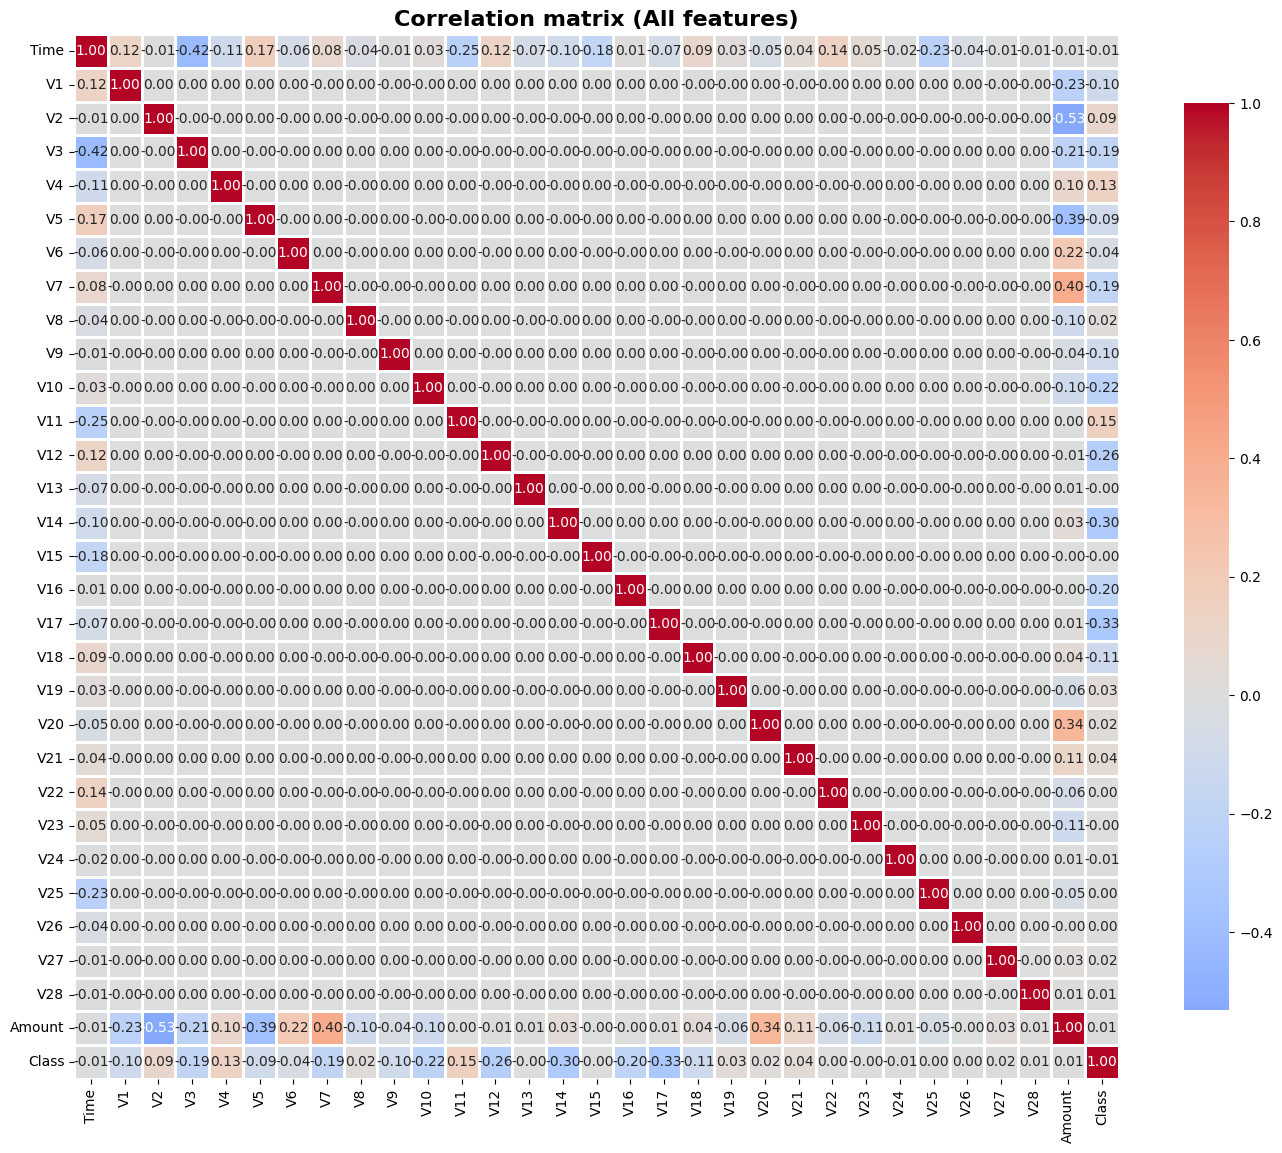


✓ Features remaining after correlation filter: 31
  Removed 0 highly correlated features


In [20]:
# Method 1: CORRELATION MATRIX
print("\n" + "="*60)
print("Method 1: Correlation matrix")
print("="*60)
# Calculate correlation matrix
correlation_matrix = data_normalized[all_features].corr()

# Find highly correlated features (> 0.9)
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

# Visualize correlation matrix 
top_features = all_features

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix.loc[top_features, top_features], 
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation matrix (All features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Remove one feature from each highly correlated pair
features_to_remove_corr = set()
for pair in high_corr_pairs:
    features_to_remove_corr.add(pair['Feature2'])  # Remove second feature

features_after_corr = [f for f in all_features if f not in features_to_remove_corr]
print(f"\n✓ Features remaining after correlation filter: {len(features_after_corr)}")
print(f"  Removed {len(features_to_remove_corr)} highly correlated features")

In [21]:
# Method 2: VARIANCE THRESHOLD
print("\n" + "="*60)
print("Method 2: Variance threshold")
print("="*60)

variance_threshold = 0.01  # Remove features with variance < 0.01
var_selector = VarianceThreshold(threshold=variance_threshold)

# Fit variance selector
var_selector.fit(data_normalized[all_features])

# Get selected features
var_mask = var_selector.get_support()
features_after_variance = [f for f, selected in zip(all_features, var_mask) if selected]

print(f"\nVariance threshold: {variance_threshold}")
print(f"Features with sufficient variance: {len(features_after_variance)}")
print(f"Low variance features removed: {len(all_features) - len(features_after_variance)}")

# Show variance of all features
feature_variances = data_normalized[all_features].var().sort_values()
print(f"\nLowest variance features:")
for feat, var in feature_variances.head(10).items():
    print(f"  {feat}: {var:.6f}")



Method 2: Variance threshold

Variance threshold: 0.01
Features with sufficient variance: 1
Low variance features removed: 30

Lowest variance features:
  V28: 0.000045
  V27: 0.000056
  V7: 0.000057
  V20: 0.000067
  V23: 0.000086
  V5: 0.000086
  Amount: 0.000095
  V21: 0.000140
  V8: 0.000164
  V6: 0.000179

Lowest variance features:
  V28: 0.000045
  V27: 0.000056
  V7: 0.000057
  V20: 0.000067
  V23: 0.000086
  V5: 0.000086
  Amount: 0.000095
  V21: 0.000140
  V8: 0.000164
  V6: 0.000179



Method 3: Feature Importance (Random Forest)

Using 'Class' as target variable

Top 15 most important features:
  V17: 0.531183
  V14: 0.096948
  V10: 0.058859
  V12: 0.034750
  V26: 0.033849
  V4: 0.020065
  V27: 0.019913
  V16: 0.015157
  V7: 0.014369
  V15: 0.014234
  Amount: 0.013094
  V21: 0.012548
  V13: 0.012224
  V19: 0.012084
  V1: 0.010992

Top 15 most important features:
  V17: 0.531183
  V14: 0.096948
  V10: 0.058859
  V12: 0.034750
  V26: 0.033849
  V4: 0.020065
  V27: 0.019913
  V16: 0.015157
  V7: 0.014369
  V15: 0.014234
  Amount: 0.013094
  V21: 0.012548
  V13: 0.012224
  V19: 0.012084
  V1: 0.010992


<Figure size 1200x800 with 0 Axes>

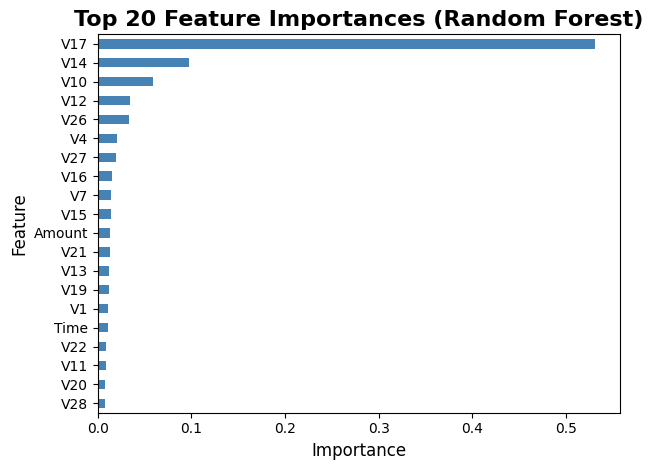


✓ Top 30 features selected by importance


In [23]:
# Method 3: FEATURE IMPORTANCE (Random Forest)
print("\n" + "="*60)
print("Method 3: Feature Importance (Random Forest)")
print("="*60)

# For demonstration, we'll create a synthetic target or use an existing numerical column
# In practice, you would use your actual target variable

# Check if we have a suitable target
potential_targets = data_normalized.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(potential_targets) > 0:
    # Use first numerical column as demo target (or specify your actual target)
    target_col = potential_targets[30]
    print(f"\nUsing '{target_col}' as target variable")
    
    # Prepare features (exclude target)
    feature_cols = [f for f in all_features if f != target_col]
    
    if len(feature_cols) > 0:
        X = data_normalized[feature_cols].fillna(0)  # Fill any remaining NaN
        y = data_normalized[target_col].fillna(0)
        
        # Train Random Forest
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_model.fit(X, y)
        
        # Get feature importances
        importances = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': rf_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print(f"\nTop 15 most important features:")
        for idx, row in importances.head(15).iterrows():
            print(f"  {row['Feature']}: {row['Importance']:.6f}")
        
        # Visualize top 20 feature importances
        plt.figure(figsize=(12, 8))
        importances.head(20).plot(x='Feature', y='Importance', kind='barh', 
                                   color='steelblue', legend=False)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.title('Top 20 Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        # Select top K features based on importance
        k_important = 30  # Select top 30 features
        features_after_importance = importances.head(min(k_important, len(importances)))['Feature'].tolist()
        
        print(f"\n✓ Top {len(features_after_importance)} features selected by importance")
    else:
        print("\nNo features available after excluding target")
        features_after_importance = feature_cols
else:
    print("\nNo suitable target variable found for feature importance")
    features_after_importance = all_features

In [24]:

# Method 4: RECURSIVE FEATURE ELIMINATION (RFE)
print("\n" + "="*60)
print("Methoh 4: Recursive feature elimination (RFE)")
print("="*60)

if len(potential_targets) > 0 and len(feature_cols) > 0:
    # Use subset of features for faster computation
    n_features_to_select = min(20, len(feature_cols))
    
    print(f"\nSelecting top {n_features_to_select} features using RFE...")
    
    # Use a smaller subset for RFE (it's computationally expensive)
    rfe_feature_subset = feature_cols[:min(50, len(feature_cols))]
    
    X_rfe = data_normalized[rfe_feature_subset].fillna(0)
    y_rfe = data_normalized[target_col].fillna(0)
    
    # Create RFE selector
    estimator = LinearRegression()
    rfe_selector = RFE(estimator=estimator, n_features_to_select=n_features_to_select, step=1)
    
    # Fit RFE
    rfe_selector.fit(X_rfe, y_rfe)
    
    # Get selected features
    rfe_mask = rfe_selector.get_support()
    features_after_rfe = [f for f, selected in zip(rfe_feature_subset, rfe_mask) if selected]
    
    print(f"\n✓ Features selected by RFE: {len(features_after_rfe)}")
    print(f"Selected features: {features_after_rfe}")
    
    # Show feature ranking
    rfe_ranking = pd.DataFrame({
        'Feature': rfe_feature_subset,
        'Rank': rfe_selector.ranking_,
        'Selected': rfe_mask
    }).sort_values('Rank')
    
    print(f"\nTop 10 ranked features:")
    for idx, row in rfe_ranking.head(10).iterrows():
        status = "✓" if row['Selected'] else "✗"
        print(f"  {status} Rank {int(row['Rank'])}: {row['Feature']}")
else:
    print("\nSkipping RFE - no suitable target variable")
    features_after_rfe = all_features[:20]



Methoh 4: Recursive feature elimination (RFE)

Selecting top 20 features using RFE...

✓ Features selected by RFE: 20
Selected features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V20', 'V21', 'V27', 'Amount']

Top 10 ranked features:
  ✓ Rank 1: V1
  ✓ Rank 1: V2
  ✓ Rank 1: V3
  ✓ Rank 1: V4
  ✓ Rank 1: V6
  ✓ Rank 1: V5
  ✓ Rank 1: V7
  ✓ Rank 1: V8
  ✓ Rank 1: V12
  ✓ Rank 1: V9

✓ Features selected by RFE: 20
Selected features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V20', 'V21', 'V27', 'Amount']

Top 10 ranked features:
  ✓ Rank 1: V1
  ✓ Rank 1: V2
  ✓ Rank 1: V3
  ✓ Rank 1: V4
  ✓ Rank 1: V6
  ✓ Rank 1: V5
  ✓ Rank 1: V7
  ✓ Rank 1: V8
  ✓ Rank 1: V12
  ✓ Rank 1: V9



                 Method  Features Selected  Reduction %
               Original                 31     0.000000
     Correlation Filter                 31     0.000000
     Variance Threshold                  1    96.774194
Feature Importance (RF)                 30     3.225806
                    RFE                 20    35.483871


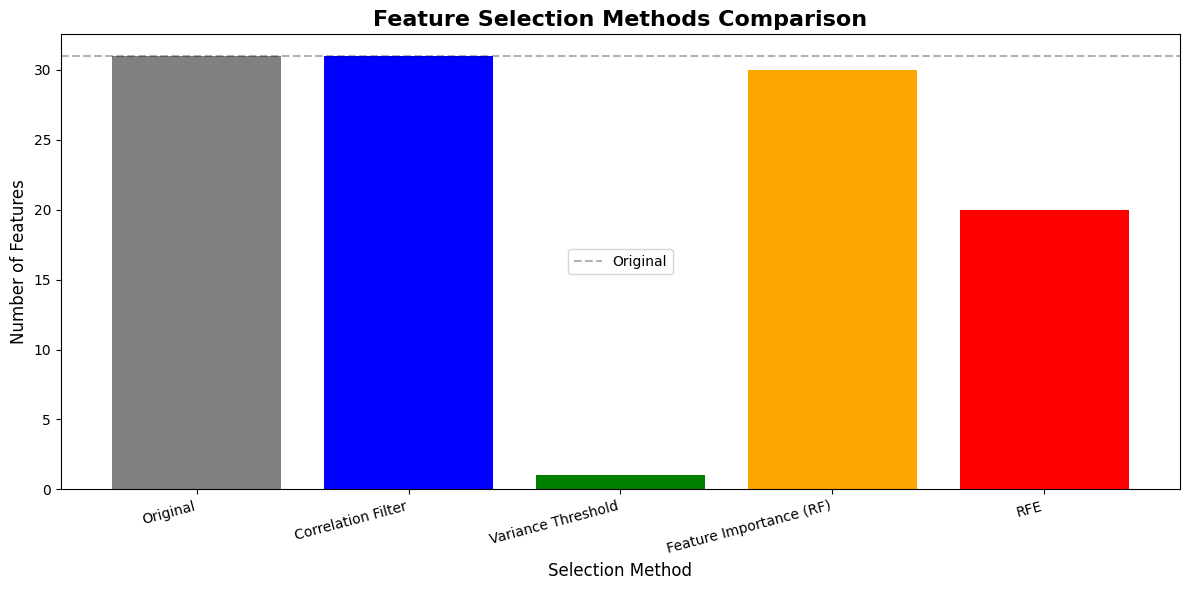


FEATURE OVERLAP ANALYSIS

Features selected by ALL methods: 0
Features selected by at least 3 methods: 21

FINAL FEATURE SELECTION RECOMMENDATION

✓ Final dataset with selected features:
  Shape: (284807, 30)
  Features: 30

Final selected features (showing first 30):
  1. Amount
  2. Time
  3. V1
  4. V10
  5. V11
  6. V12
  7. V13
  8. V14
  9. V15
  10. V16
  11. V17
  12. V18
  13. V19
  14. V2
  15. V20
  16. V21
  17. V22
  18. V23
  19. V24
  20. V25
  21. V26
  22. V27
  23. V28
  24. V3
  25. V4
  26. V5
  27. V6
  28. V7
  29. V8
  30. V9

FEATURE SELECTION SUMMARY

           Metric Value
   Total Features    31
Selected Features    30
 Removed Features     1
   Retention Rate 96.8%

✓ Feature selection complete!
✓ Data is now ready for machine learning modeling


In [25]:
comparison = pd.DataFrame({
    'Method': [
        'Original',
        'Correlation Filter',
        'Variance Threshold',
        'Feature Importance (RF)',
        'RFE'
    ],
    'Features Selected': [
        len(all_features),
        len(features_after_corr),
        len(features_after_variance),
        len(features_after_importance),
        len(features_after_rfe)
    ],
    'Reduction %': [
        0,
        (1 - len(features_after_corr)/len(all_features)) * 100,
        (1 - len(features_after_variance)/len(all_features)) * 100,
        (1 - len(features_after_importance)/len(all_features)) * 100,
        (1 - len(features_after_rfe)/len(all_features)) * 100
    ]
})

print("\n" + comparison.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(12, 6))
plt.bar(comparison['Method'], comparison['Features Selected'], color=['gray', 'blue', 'green', 'orange', 'red'])
plt.xlabel('Selection Method', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title('Feature Selection Methods Comparison', fontsize=16, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.axhline(y=len(all_features), color='black', linestyle='--', alpha=0.3, label='Original')
plt.legend()
plt.tight_layout()
plt.show()

# Find common features across methods
print("\n" + "="*60)
print("FEATURE OVERLAP ANALYSIS")
print("="*60)

# Create sets for comparison
set_corr = set(features_after_corr)
set_var = set(features_after_variance)
set_imp = set(features_after_importance)
set_rfe = set(features_after_rfe)

# Find intersection
common_all = set_corr & set_var & set_imp & set_rfe
common_three = (set_corr & set_var & set_imp) | (set_corr & set_var & set_rfe) | \
               (set_corr & set_imp & set_rfe) | (set_var & set_imp & set_rfe)

print(f"\nFeatures selected by ALL methods: {len(common_all)}")
print(f"Features selected by at least 3 methods: {len(common_three)}")

if len(common_all) > 0:
    print(f"\nFeatures in ALL methods:")
    for feat in sorted(common_all)[:20]:
        print(f"  • {feat}")

# FINAL FEATURE SELECTION
print("\n" + "="*60)
print("FINAL FEATURE SELECTION RECOMMENDATION")
print("="*60)

# Strategy: Combine correlation filter + importance-based selection
final_features = list(set(features_after_corr) & set(features_after_importance))

# If too few features, add top variance features
if len(final_features) < 15:
    additional = [f for f in features_after_variance if f not in final_features]
    final_features.extend(additional[:15 - len(final_features)])

# Create final dataset
data_final_selected = data_normalized[final_features].copy()

print(f"\n✓ Final dataset with selected features:")
print(f"  Shape: {data_final_selected.shape}")
print(f"  Features: {len(final_features)}")

# Show final selected features
print(f"\nFinal selected features (showing first 30):")
for i, feat in enumerate(sorted(final_features)[:30], 1):
    print(f"  {i}. {feat}")

# Save comparison visualization
print("\n" + "="*60)
print("FEATURE SELECTION SUMMARY")
print("="*60)

summary_data = {
    'Metric': ['Total Features', 'Selected Features', 'Removed Features', 'Retention Rate'],
    'Value': [
        len(all_features),
        len(final_features),
        len(all_features) - len(final_features),
        f"{(len(final_features)/len(all_features)*100):.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print(f"\n{'='*60}")
print("✓ Feature selection complete!")
print("✓ Data is now ready for machine learning modeling")
print(f"{'='*60}")